# Предобработка данных

In [ ]:
# Названия таблиц и пояснения к ним

# Таблицы с данными (сначала с пропусками, потом заполненные)
#data_healthy
#data_1_stage
#data_2_stage
#data_3_stage

# Объединённая таблица
#data_glaucoma
#data_glaucoma_after_input

# Описательная статистика
#describe_data_healthy
#describe_data_1_stage
#describe_data_2_stage
#describe_data_3_stage

# Агрегированная таблица со средними значениями
#table_agg

# Вспомогательная таблица для заполнения медианой
#median_imputer


## Импорт библиотек и данных

In [ ]:
#импортируем необходимые библиотеки для обработки данных
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer


import scipy

In [ ]:
#загружаем имеющиеся данные
excel_reader=pd.ExcelFile('/content/drive/MyDrive/data_glaucoma.xlsx')

В таблице с данными 4 листа. Выделим их для удобства работы в отдельные таблицы.

In [ ]:
print(excel_reader.sheet_names)

['Здоровые', ' I стадия ПОУГ', ' II стадия ПОУГ', ' III стадия ПОУГ']


In [ ]:
data_healthy=excel_reader.parse('Здоровые')

In [ ]:
#data_healthy.head(11)

In [ ]:
data_1_stage=excel_reader.parse(' I стадия ПОУГ')

In [ ]:
#data_1_stage

In [ ]:
data_2_stage=excel_reader.parse(' II стадия ПОУГ')

In [ ]:
#data_2_stage

In [ ]:
data_3_stage=excel_reader.parse(' III стадия ПОУГ')

In [ ]:
#data_3_stage

## Задача 0: Техническая предобработка данных


Добавим название первого столбца

In [ ]:
data_healthy=data_healthy.rename(columns={'Unnamed: 0':'Фамилия'})
data_1_stage=data_1_stage.rename(columns={'Unnamed: 0':'Фамилия'})
data_2_stage=data_2_stage.rename(columns={'Unnamed: 0':'Фамилия'})
data_3_stage=data_3_stage.rename(columns={'Unnamed: 0':'Фамилия'})

Уберем перенос на новую строку в названиях столбцов

In [ ]:
data_healthy=data_healthy.rename(columns={'Z\nбаз.\n(отн.))':'Z баз.(отн.))'})
data_1_stage=data_1_stage.rename(columns={'Z\nбаз.\n(отн.))':'Z баз.(отн.))'})
data_2_stage=data_2_stage.rename(columns={'Z\nбаз.\n(отн.))':'Z баз.(отн.))'})
data_3_stage=data_3_stage.rename(columns={'Z\nбаз.\n(отн.))':'Z баз.(отн.))'})

In [ ]:
data_healthy=data_healthy.rename(columns={'Z\nбаз.\n(мОм)':'Z баз.(мОм)'})
data_1_stage=data_1_stage.rename(columns={'Z\nбаз.\n(мОм)':'Z баз.(мОм)'})
data_2_stage=data_2_stage.rename(columns={'Z\nбаз.\n(мОм)':'Z баз.(мОм)'})
data_3_stage=data_3_stage.rename(columns={'Z\nбаз.\n(мОм)':'Z баз.(мОм)'})

In [ ]:
data_healthy=data_healthy.rename(columns={'УОК\n(уд.объем)\nмкл':'УОК (уд.объем) мкл'})
data_1_stage=data_1_stage.rename(columns={'УОК\n(уд.объем)\nмкл':'УОК (уд.объем) мкл'})
data_2_stage=data_2_stage.rename(columns={'УОК\n(уд.объем)\nмкл':'УОК (уд.объем) мкл'})
data_3_stage=data_3_stage.rename(columns={'УОК\n(уд.объем)\nмкл':'УОК (уд.объем) мкл'})

Заполним признак стадии в листе таблицы для 1й стадии

In [ ]:
data_1_stage['стадия']=1

In [ ]:
data_healthy

,Фамилия,возраст,стадия,величина внутриглазного давления,"ВГД, корригированного на коэффициент ригидности",Коэфф ригидности склеральн капсулы глаза,Роговично-компенсированное ВГД,ВГД по Гольдману,Фактор резистентности роговицы,КГ,...,gamma Ш,Efrid,SVL,DVL,РИ (рео.индекс) мОм,ПМН (макс.нап),ПМУ (мод.упр.),Z баз.(отн.)),Z баз.(мОм),УОК (уд.объем) мкл
0,уланкина,25,0,10,12,0.0162,9.7,9.4,9.3,11.3,...,1.75,0.0162,56.300000,46.03000,49.65,0.27,0.25,979.0,39.16,1.157570
1,степанова,26,0,12,15,0.0162,18.5,19.9,12.8,11.6,...,1.85,0.0162,50.960000,44.21000,NaN,NaN,NaN,NaN,NaN,NaN
2,кудасов,32,0,10,12,0.0162,14.3,12.0,8.3,9.2,...,NaN,NaN,53.580000,47.40000,102.33,0.13,0.14,1060.0,42.40,2.203474
3,NaN,32,0,10,12,0.0162,17.6,13.9,7.6,7.6,...,NaN,NaN,56.297266,45.46207,58.43,0.20,0.21,1063.0,42.52,1.254623
4,гладих,68,0,10,14,0.0138,20.1,17.2,8.8,7.9,...,1.75,0.0138,48.680000,45.88000,20.97,0.13,0.14,725.0,29.00,0.660193
5,мыздриков,59,0,12,14,0.0161,8.5,8.1,9.1,11.4,...,1.85,0.0161,53.560000,48.42000,35.50,0.52,0.42,917.0,36.68,0.883629
6,Савинова,66,0,15,23,0.0076,NaN,NaN,NaN,NaN,...,1.30,0.0076,48.710000,NaN,49.88,0.29,0.30,910.0,36.40,1.251111
7,NaN,66,0,12,16,0.0140,NaN,NaN,NaN,NaN,...,1.70,0.0140,NaN,NaN,53.23,0.32,0.33,822.0,32.88,1.478071
8,Мациева,68,0,18,28,0.0052,20.4,20.0,11.3,9.9,...,1.10,0.0052,51.320000,43.70000,NaN,NaN,NaN,NaN,NaN,NaN
9,Булат,51,0,12,19,0.0031,17.8,16.5,10.0,9.6,...,0.60,0.0031,NaN,NaN,183.50,0.33,0.40,1210.0,48.40,3.461477


## Задача 0.1: Создаём объединённую таблицу

In [ ]:
#объединим все таблицы
data_glaucoma=pd.concat([data_healthy, data_1_stage, data_2_stage, data_3_stage], axis=0)


In [ ]:
data_glaucoma

,Фамилия,возраст,стадия,величина внутриглазного давления,"ВГД, корригированного на коэффициент ригидности",Коэфф ригидности склеральн капсулы глаза,Роговично-компенсированное ВГД,ВГД по Гольдману,Фактор резистентности роговицы,КГ,...,gamma Ш,Efrid,SVL,DVL,РИ (рео.индекс) мОм,ПМН (макс.нап),ПМУ (мод.упр.),Z баз.(отн.)),Z баз.(мОм),УОК (уд.объем) мкл
0,уланкина,25,0,10,12,0.0162,9.7,9.4,9.3,11.3,...,1.75,0.0162,56.300000,46.030000,49.65,0.27,0.25,979.0,39.16,1.157570
1,степанова,26,0,12,15,0.0162,18.5,19.9,12.8,11.6,...,1.85,0.0162,50.960000,44.210000,NaN,NaN,NaN,NaN,NaN,NaN
2,кудасов,32,0,10,12,0.0162,14.3,12.0,8.3,9.2,...,NaN,NaN,53.580000,47.400000,102.33,0.13,0.14,1060.0,42.40,2.203474
3,NaN,32,0,10,12,0.0162,17.6,13.9,7.6,7.6,...,NaN,NaN,56.297266,45.462070,58.43,0.20,0.21,1063.0,42.52,1.254623
4,гладих,68,0,10,14,0.0138,20.1,17.2,8.8,7.9,...,1.75,0.0138,48.680000,45.880000,20.97,0.13,0.14,725.0,29.00,0.660193
5,мыздриков,59,0,12,14,0.0161,8.5,8.1,9.1,11.4,...,1.85,0.0161,53.560000,48.420000,35.50,0.52,0.42,917.0,36.68,0.883629
6,Савинова,66,0,15,23,0.0076,NaN,NaN,NaN,NaN,...,1.30,0.0076,48.710000,NaN,49.88,0.29,0.30,910.0,36.40,1.251111
7,NaN,66,0,12,16,0.0140,NaN,NaN,NaN,NaN,...,1.70,0.0140,NaN,NaN,53.23,0.32,0.33,822.0,32.88,1.478071
8,Мациева,68,0,18,28,0.0052,20.4,20.0,11.3,9.9,...,1.10,0.0052,51.320000,43.700000,NaN,NaN,NaN,NaN,NaN,NaN
9,Булат,51,0,12,19,0.0031,17.8,16.5,10.0,9.6,...,0.60,0.0031,NaN,NaN,183.50,0.33,0.40,1210.0,48.40,3.461477


In [ ]:
data_glaucoma.columns.tolist()

['Фамилия',
 'возраст',
 'стадия',
 'величина внутриглазного давления',
 'ВГД, корригированного на коэффициент ригидности',
 'Коэфф ригидности склеральн капсулы глаза',
 'Роговично-компенсированное ВГД',
 'ВГД по Гольдману',
 'Фактор резистентности роговицы',
 'КГ',
 'ЦТР',
 'РП',
 'ГлРП',
 'gamma Ш',
 'Efrid',
 'SVL',
 'DVL',
 'РИ (рео.индекс) мОм',
 'ПМН (макс.нап)',
 'ПМУ (мод.упр.)',
 'Z баз.(отн.))',
 'Z баз.(мОм)',
 'УОК (уд.объем) мкл']

In [ ]:
data_glaucoma.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51 entries, 0 to 9
Data columns (total 23 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Фамилия                                          39 non-null     object 
 1   возраст                                          51 non-null     int64  
 2   стадия                                           51 non-null     int64  
 3   величина внутриглазного давления                 51 non-null     int64  
 4   ВГД, корригированного на коэффициент ригидности  51 non-null     int64  
 5   Коэфф ригидности склеральн капсулы глаза         51 non-null     float64
 6   Роговично-компенсированное ВГД                   48 non-null     float64
 7   ВГД по Гольдману                                 48 non-null     float64
 8   Фактор резистентности роговицы                   48 non-null     float64
 9   КГ                                      

# Задача 1. Работа с пропущенными значениями

1. Проанализировать данные.

  Пропущенные значения дополнить тем или иным способом.

  Проанализировать, меняется ли взаимосвязь дополненных показателей с другими показателями.



---

Рассмотрим описательную статистику с пропущенными значениями

In [ ]:
describe_data_healthy=data_healthy.describe()

In [ ]:
#describe_data_healthy

In [ ]:
describe_data_1_stage=data_1_stage.describe()

In [ ]:
#describe_data_1_stage

In [ ]:
describe_data_2_stage=data_2_stage.describe()

In [ ]:
#describe_data_2_stage

In [ ]:
describe_data_3_stage=data_3_stage.describe()

In [ ]:
#describe_data_3_stage

## Анализ полученных описаний

---



Можно построить графики со **средним значением** всех признаков

График по возрасту

In [ ]:
table_agg=data_glaucoma.drop(['Фамилия'], axis=1).groupby(['стадия']).agg('mean')

In [ ]:
table_agg

,возраст,величина внутриглазного давления,"ВГД, корригированного на коэффициент ригидности",Коэфф ригидности склеральн капсулы глаза,Роговично-компенсированное ВГД,ВГД по Гольдману,Фактор резистентности роговицы,КГ,ЦТР,РП,...,gamma Ш,Efrid,SVL,DVL,РИ (рео.индекс) мОм,ПМН (макс.нап),ПМУ (мод.упр.),Z баз.(отн.)),Z баз.(мОм),УОК (уд.объем) мкл
стадия,,,,,,,,,,,,,,,,,,,,,
0,49.454545,12.090909,16.727273,0.011409,16.100000,14.733333,9.566667,9.677778,542.181818,229.909091,...,1.366667,0.010344,52.425908,45.871724,69.186250,0.273750,0.273750,960.750000,38.430000,1.543769
1,67.000000,13.466667,18.400000,0.011880,18.971429,17.692857,10.214286,9.364286,550.818182,205.454545,...,1.515385,0.012308,50.219262,41.645661,53.100000,0.226923,0.256923,922.333333,36.893333,1.523104
2,75.400000,14.466667,16.200000,0.018273,19.640000,17.620000,9.553333,8.653333,540.666667,201.888889,...,1.733333,0.018910,45.355714,37.330000,42.420833,0.289167,0.332500,820.416667,32.816667,1.369332
3,70.400000,16.600000,14.200000,0.027450,21.450000,18.900000,8.930000,7.580000,532.444444,176.714286,...,2.460000,0.026600,43.061667,38.695000,30.057778,0.203333,0.207778,765.666667,30.626667,1.046969


<Axes: xlabel='стадия'>

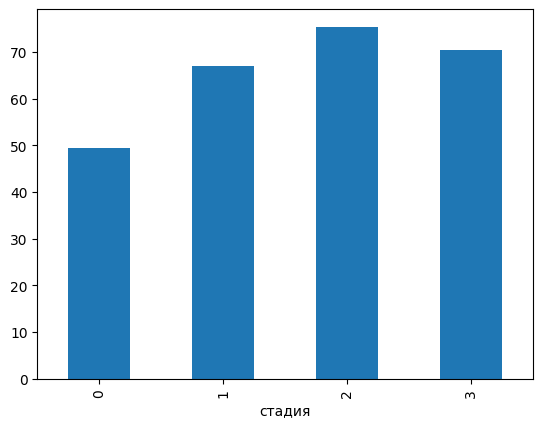

In [ ]:
table_agg['возраст'].plot.bar()

<Axes: xlabel='стадия'>

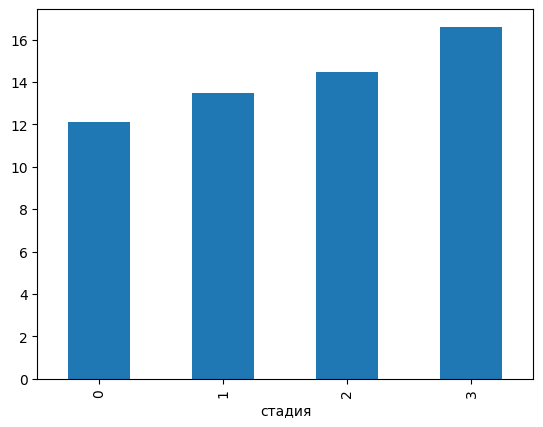

In [ ]:
table_agg['величина внутриглазного давления'].plot.bar()

<Axes: xlabel='стадия'>

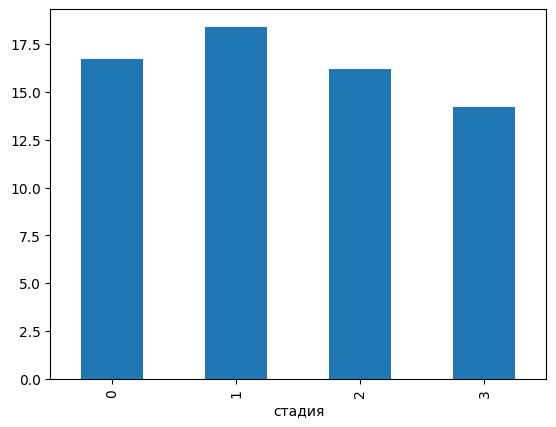

In [ ]:
table_agg['ВГД, корригированного на коэффициент ригидности'].plot.bar()

<Axes: xlabel='стадия'>

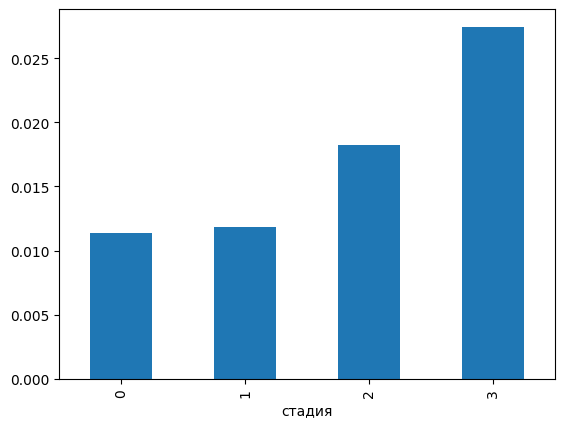

In [ ]:
table_agg['Коэфф ригидности склеральн капсулы глаза'].plot.bar()

<Axes: xlabel='стадия'>

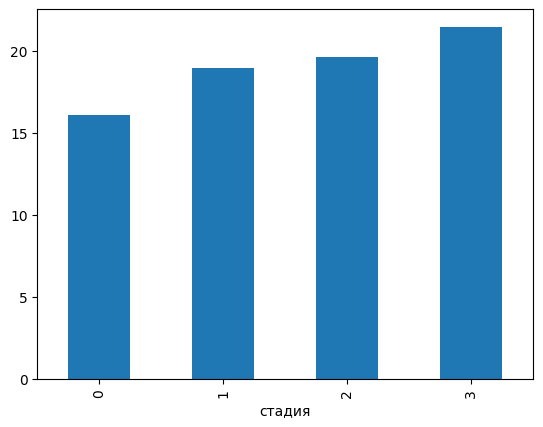

In [ ]:
table_agg['Роговично-компенсированное ВГД'].plot.bar()

<Axes: xlabel='стадия'>

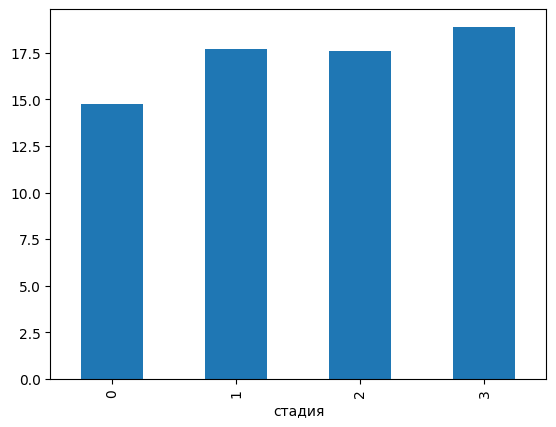

In [ ]:
table_agg['ВГД по Гольдману'].plot.bar()

<Axes: xlabel='стадия'>

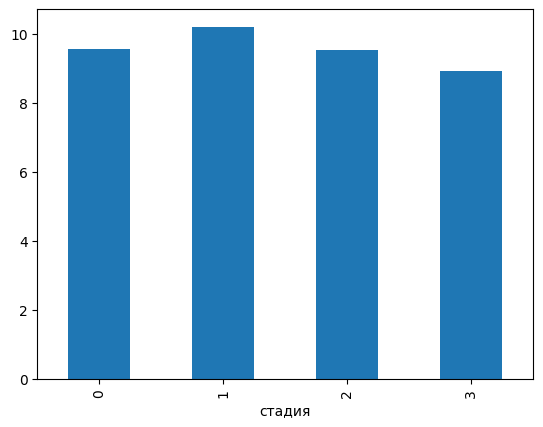

In [ ]:
table_agg['Фактор резистентности роговицы'].plot.bar()

<Axes: xlabel='стадия'>

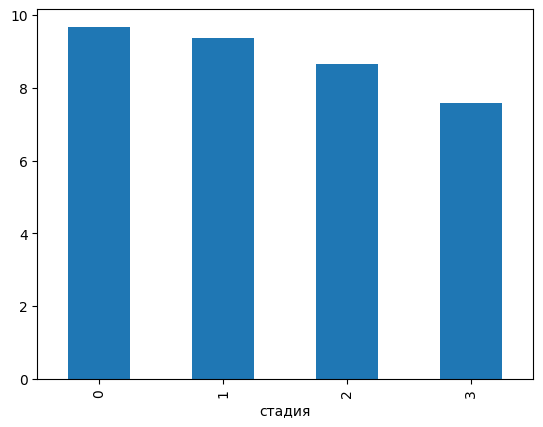

In [ ]:
table_agg['КГ'].plot.bar()

<Axes: xlabel='стадия'>

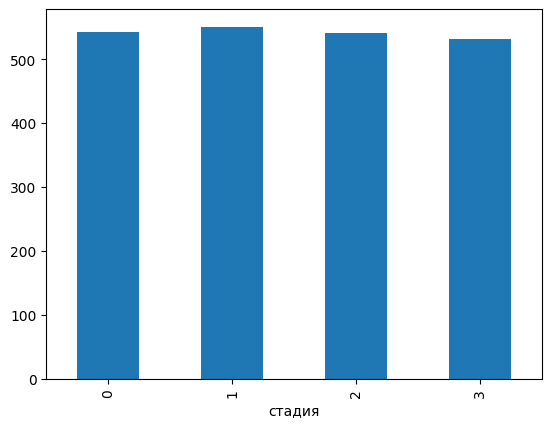

In [ ]:
table_agg['ЦТР'].plot.bar()

<Axes: xlabel='стадия'>

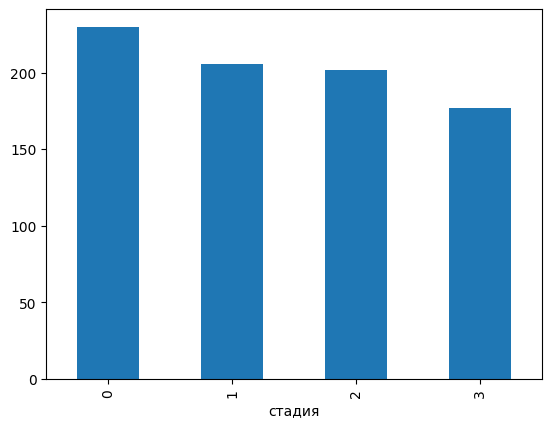

In [ ]:
table_agg['РП'].plot.bar()

<Axes: xlabel='стадия'>

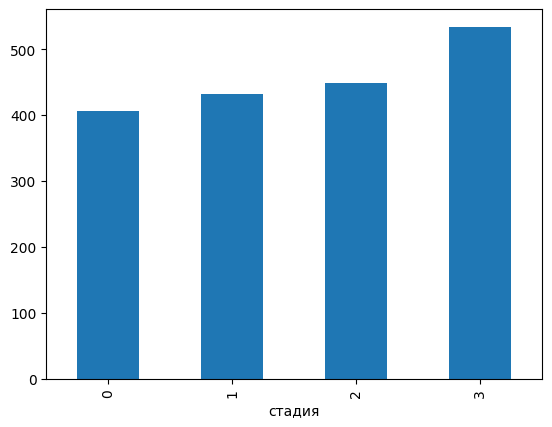

In [ ]:
table_agg['ГлРП'].plot.bar()

<Axes: xlabel='стадия'>

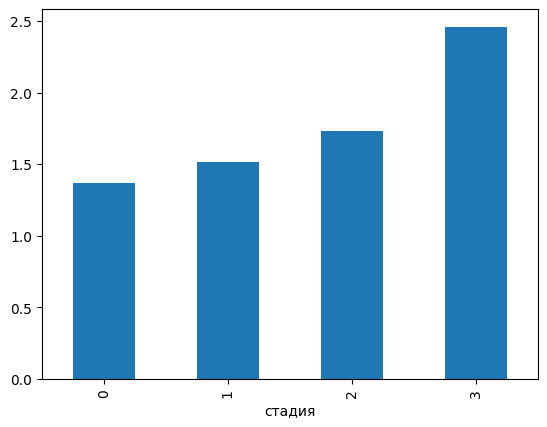

In [ ]:
table_agg['gamma Ш'].plot.bar()

<Axes: xlabel='стадия'>

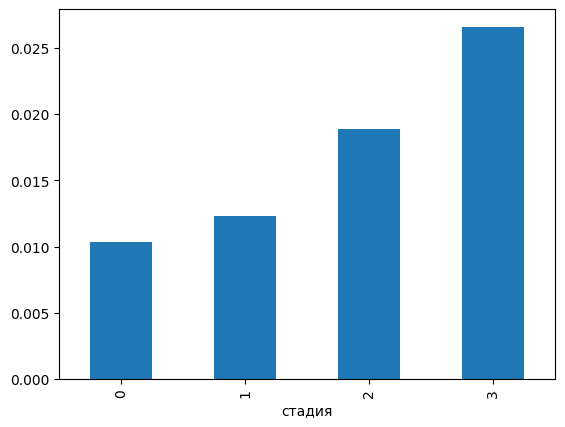

In [ ]:
table_agg['Efrid'].plot.bar()

<Axes: xlabel='стадия'>

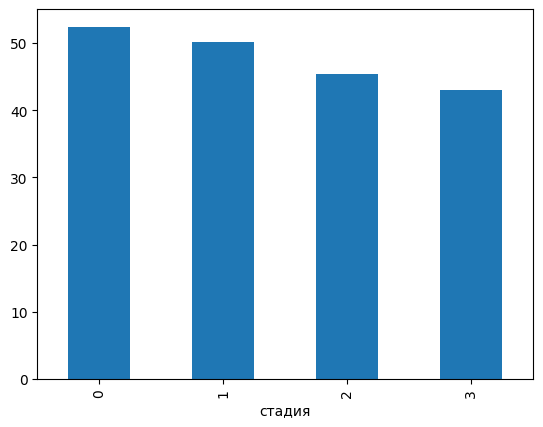

In [ ]:
table_agg['SVL'].plot.bar()

<Axes: xlabel='стадия'>

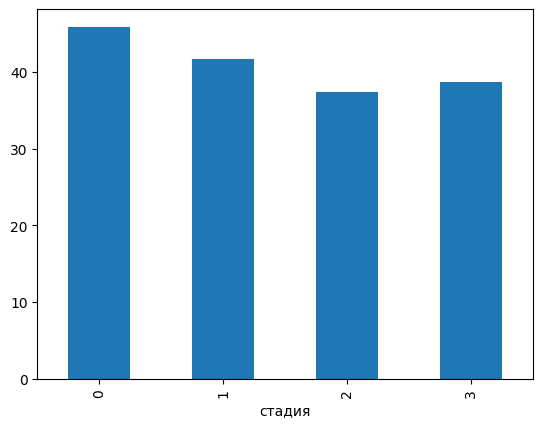

In [ ]:
table_agg['DVL'].plot.bar()

<Axes: xlabel='стадия'>

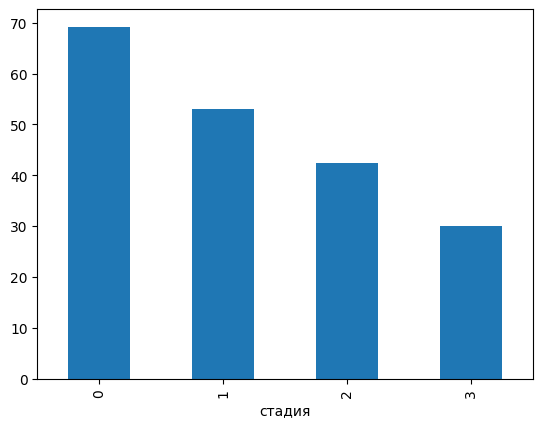

In [ ]:
table_agg['РИ (рео.индекс) мОм'].plot.bar()

<Axes: xlabel='стадия'>

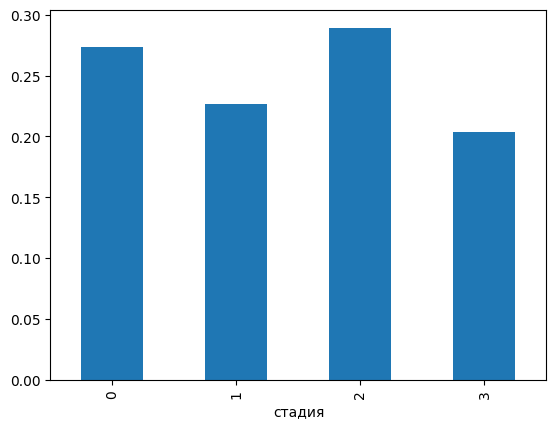

In [ ]:
table_agg['ПМН (макс.нап)'].plot.bar()

<Axes: xlabel='стадия'>

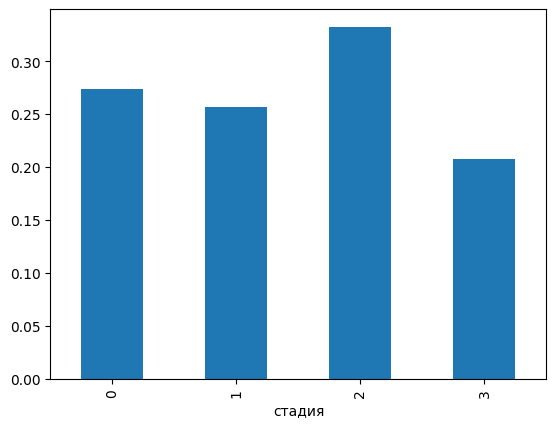

In [ ]:
table_agg['ПМУ (мод.упр.)'].plot.bar()

<Axes: xlabel='стадия'>

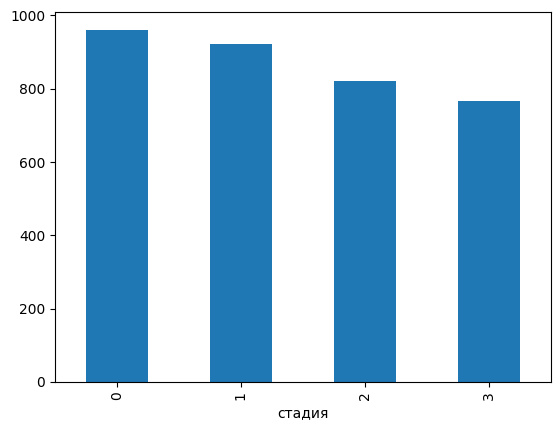

In [ ]:
table_agg['Z баз.(отн.))'].plot.bar()

<Axes: xlabel='стадия'>

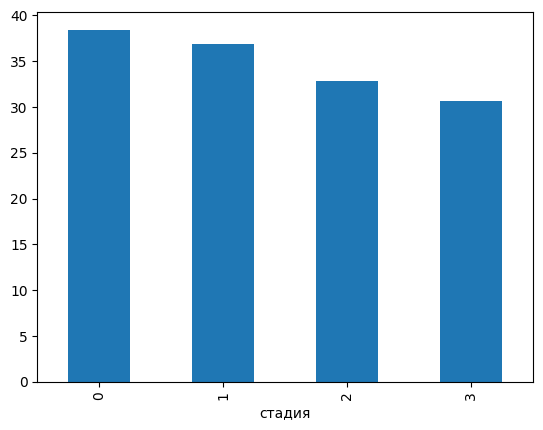

In [ ]:
table_agg['Z баз.(мОм)'].plot.bar()

<Axes: xlabel='стадия'>

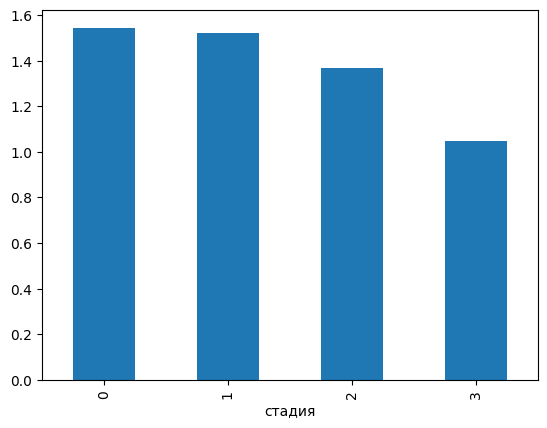

In [ ]:
table_agg['УОК (уд.объем) мкл'].plot.bar()

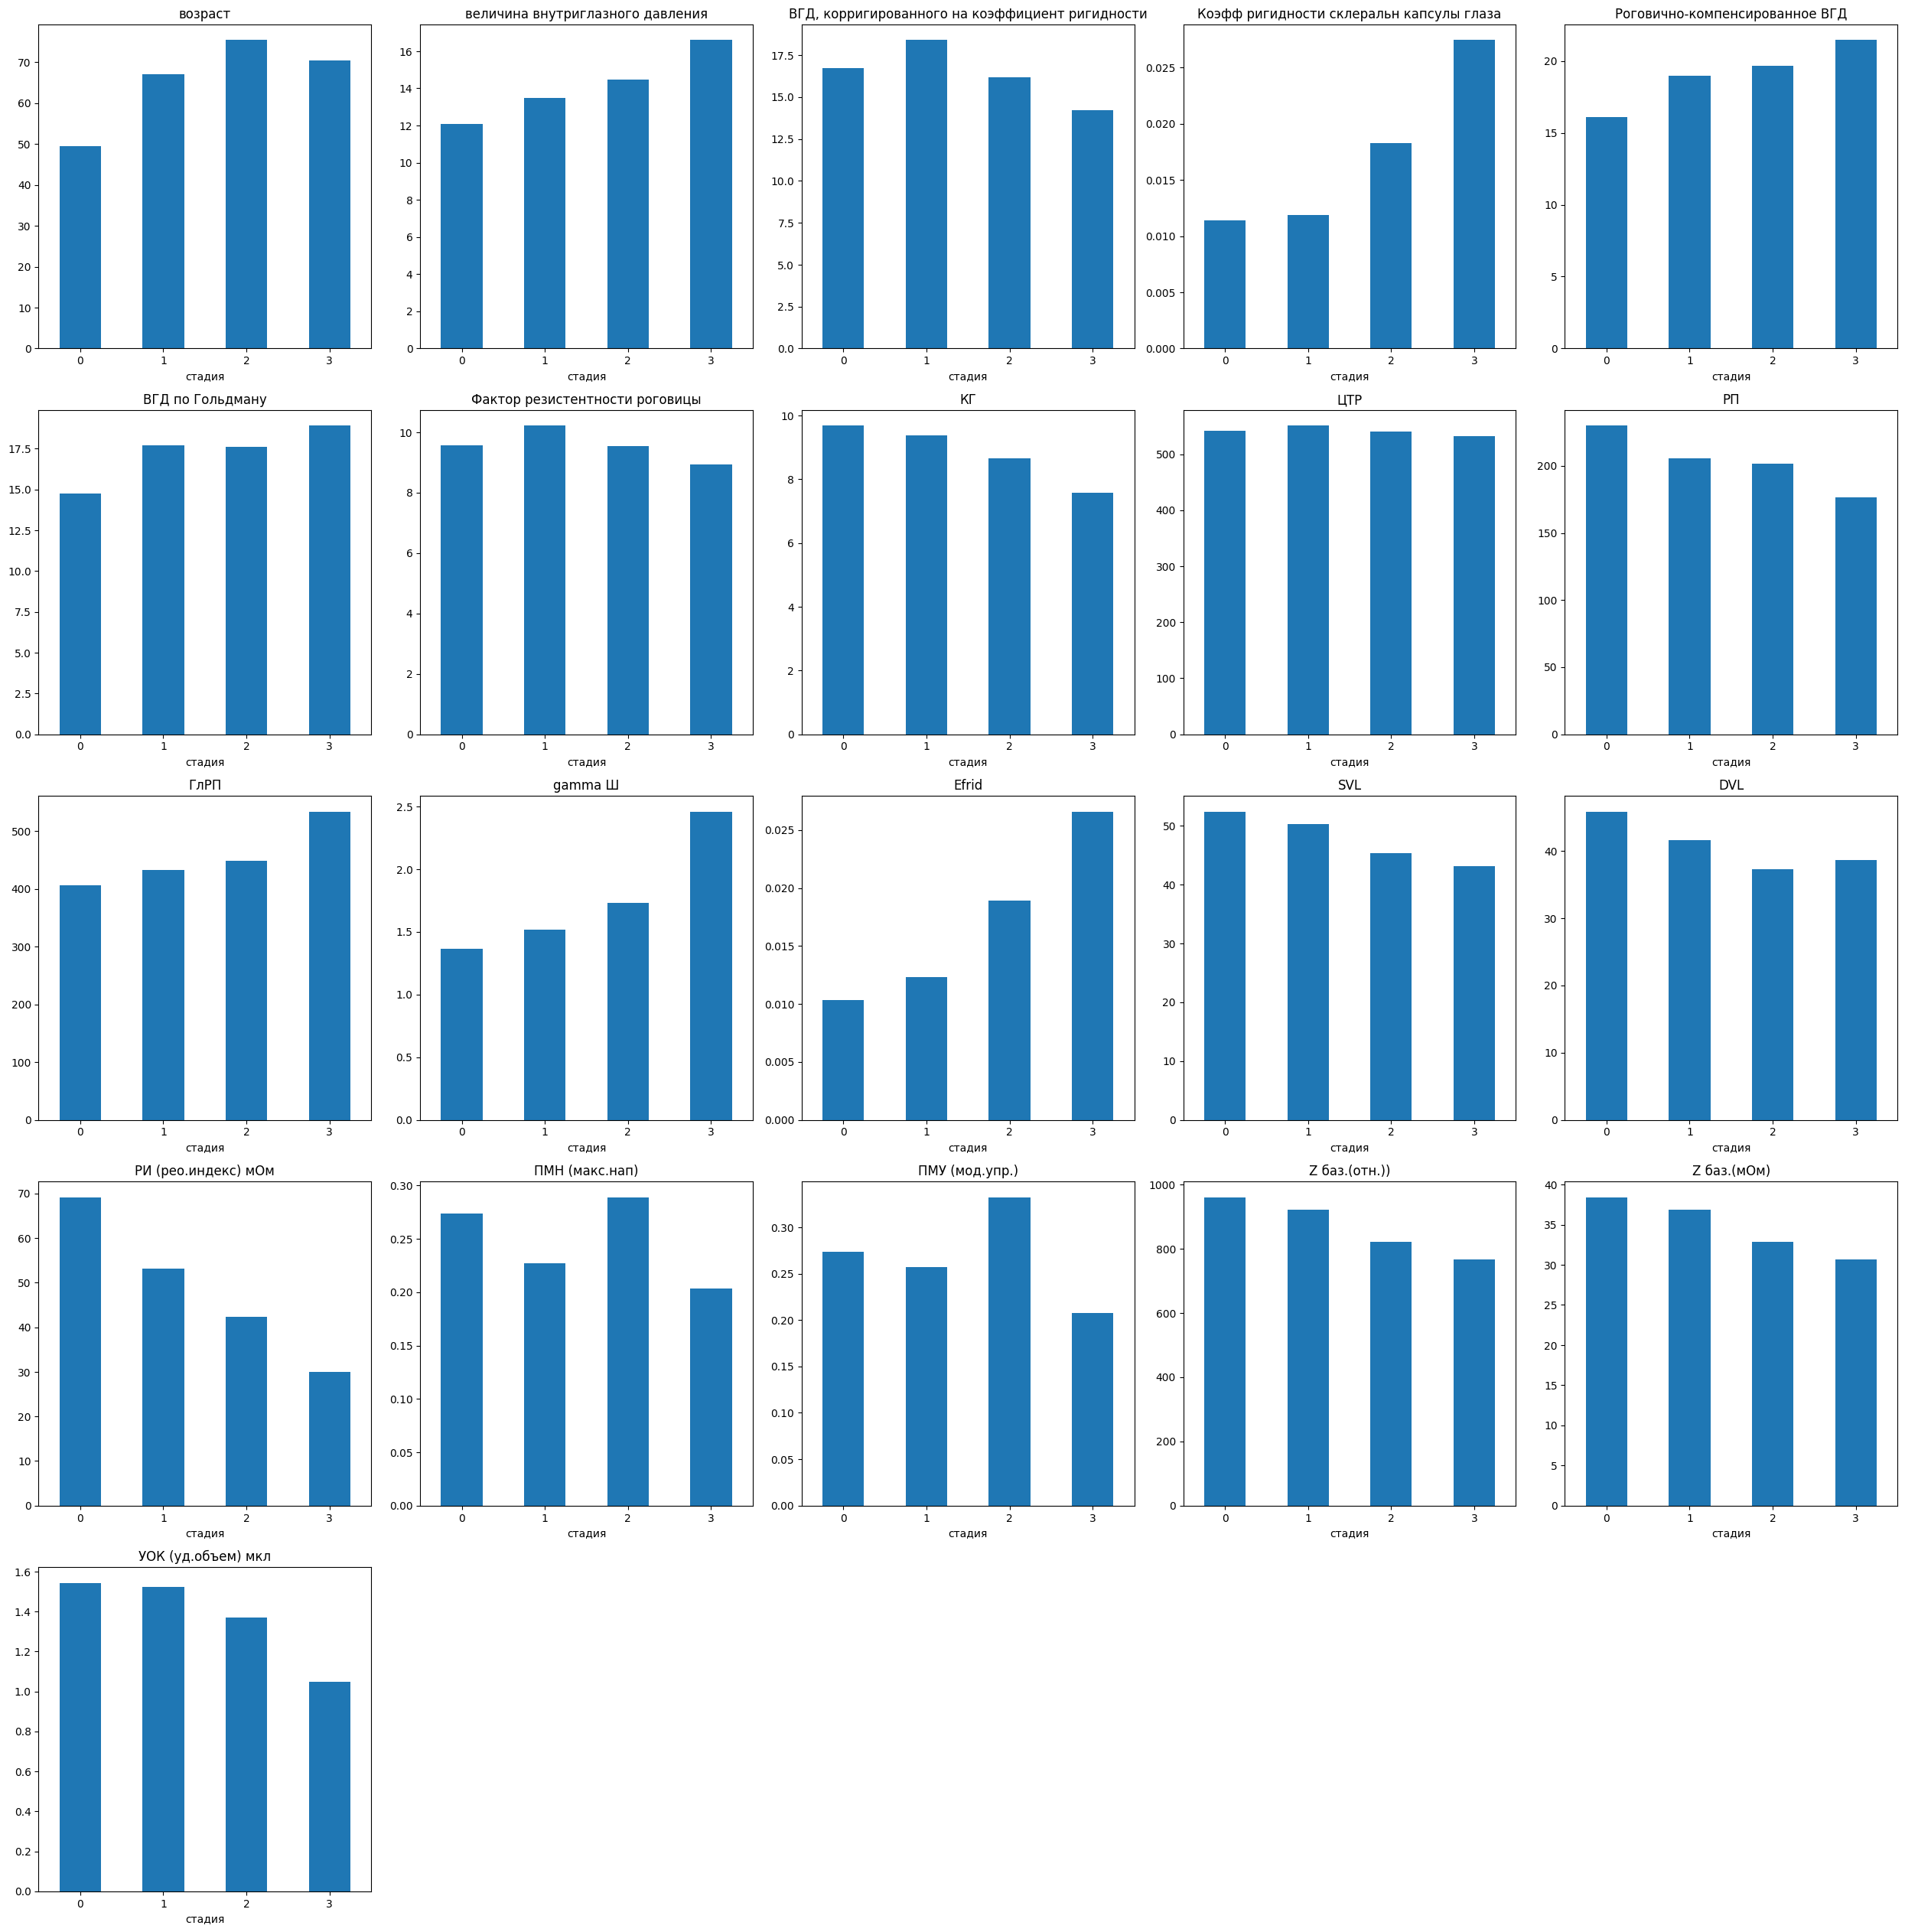

In [ ]:
columns = table_agg.columns.tolist()

n=len(columns)
rows=(n//3)+int(n%3!=0)
# Настроим сетку графиков, например 7 строк и 3 столбца
fig, axes = plt.subplots(nrows=rows, ncols=5, figsize=(25, 5*rows))  # размер можно настроить под себя
axes = axes.flatten()  # Преобразуем в 1D для удобства обращения

for i, col in enumerate(columns):
    table_agg[col].plot.bar(ax=axes[i], title=col)
    axes[i].tick_params(axis='x', rotation=0)  # при необходимости повернуть подписи по оси X

# Удалим лишние оси, если графиков меньше, чем ячеек
for j in range(len(columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Работа с пропущенными значениями в таблице со **здоровыми** пациентами

In [ ]:
#посмотрим сколько пропущенных значений в данных
data_healthy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 23 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Фамилия                                          8 non-null      object 
 1   возраст                                          11 non-null     int64  
 2   стадия                                           11 non-null     int64  
 3   величина внутриглазного давления                 11 non-null     int64  
 4   ВГД, корригированного на коэффициент ригидности  11 non-null     int64  
 5   Коэфф ригидности склеральн капсулы глаза         11 non-null     float64
 6   Роговично-компенсированное ВГД                   9 non-null      float64
 7   ВГД по Гольдману                                 9 non-null      float64
 8   Фактор резистентности роговицы                   9 non-null      float64
 9   КГ                                

Всего в исходных данных 11 строк.
Посмотрим сколько пропущенных значений в каждой колонке

In [ ]:
data_healthy.isnull().sum()

,0
Фамилия,3
возраст,0
стадия,0
величина внутриглазного давления,0
"ВГД, корригированного на коэффициент ригидности",0
Коэфф ригидности склеральн капсулы глаза,0
Роговично-компенсированное ВГД,2
ВГД по Гольдману,2
Фактор резистентности роговицы,2
КГ,2


Можем также оценить процент пропущенных значений

In [ ]:
(data_healthy.isna().sum() / len(data_healthy)).round(4) * 100

,0
Фамилия,27.27
возраст,0.00
стадия,0.00
величина внутриглазного давления,0.00
"ВГД, корригированного на коэффициент ригидности",0.00
Коэфф ригидности склеральн капсулы глаза,0.00
Роговично-компенсированное ВГД,18.18
ВГД по Гольдману,18.18
Фактор резистентности роговицы,18.18
КГ,18.18


**Вывод**: пропуски есть по 15 признакам из 23, что составляет более половины, процент пропущенных данных в основном не превышает 30%, кроме признака DVL(36.36%). На основе этого становится понятно, что удалять данные с пропущенными значениями - неподходящий способ в данной ситуации.

---



### Рассмотрим характер пропусков в данных

In [ ]:
# импортируем библиотеку missingno с псевдонимом msno для визуализации пропусков данных
import missingno as msno

In [ ]:
#настраиваем стиль графиков
sns.set()

<Axes: >

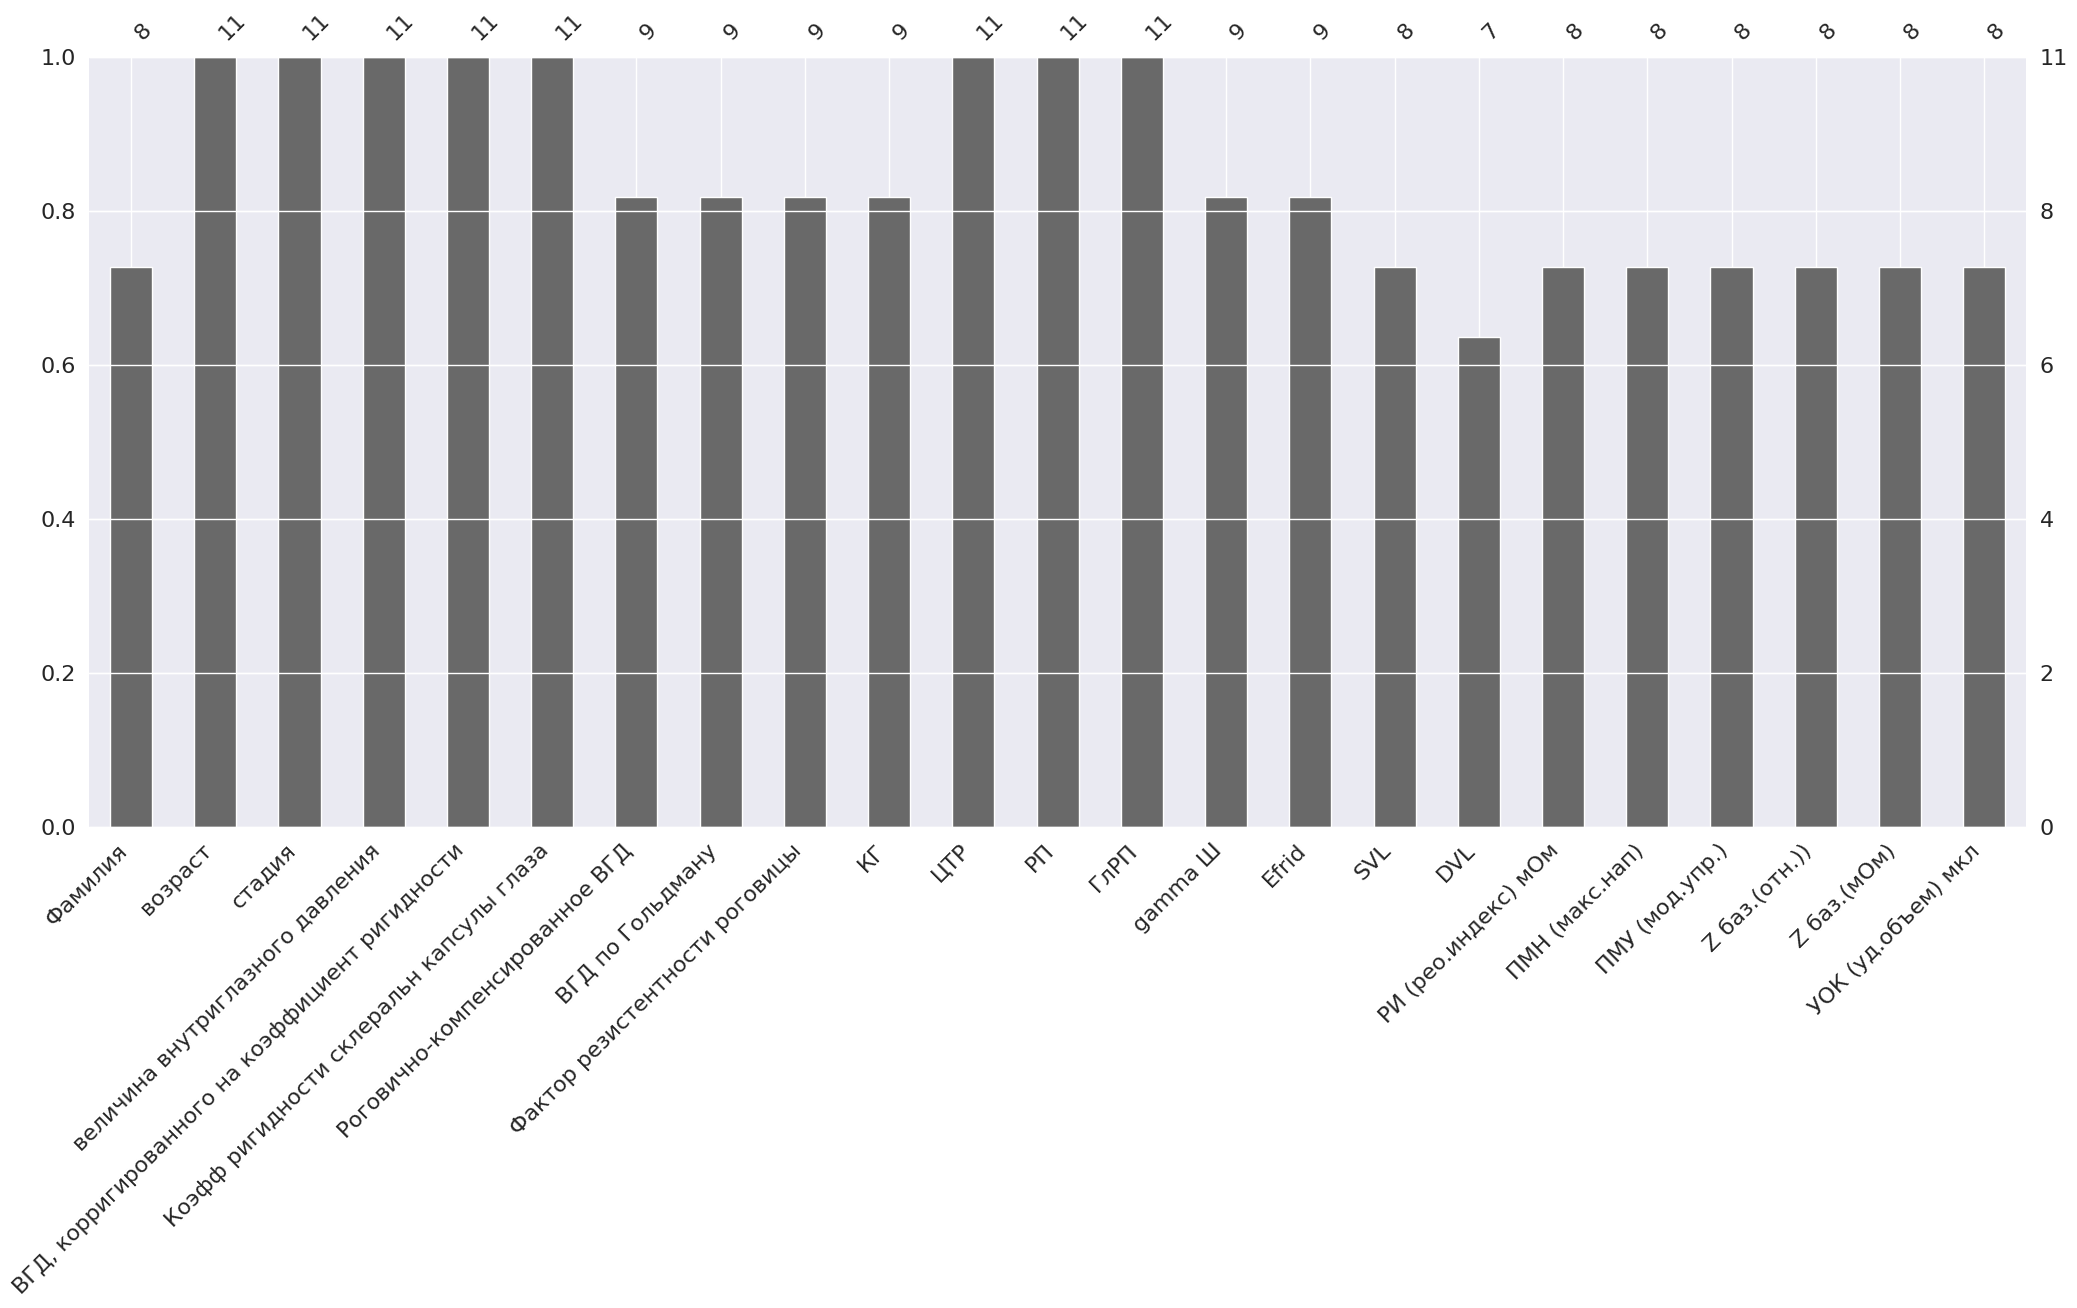

In [ ]:
msno.bar(data_healthy)

На этом графике мы видим процент (слева) и абсолютное количество (справа и сверху) заполненных значений.

При этом столбчатая диаграмма не дает информации о том, где именно больше всего пропущенных значений(есть ли в пропусках какая-то закономерность или нет).

Для наглядности расположения пропусков построим **матрицу пропущенных значений.**

<Axes: >

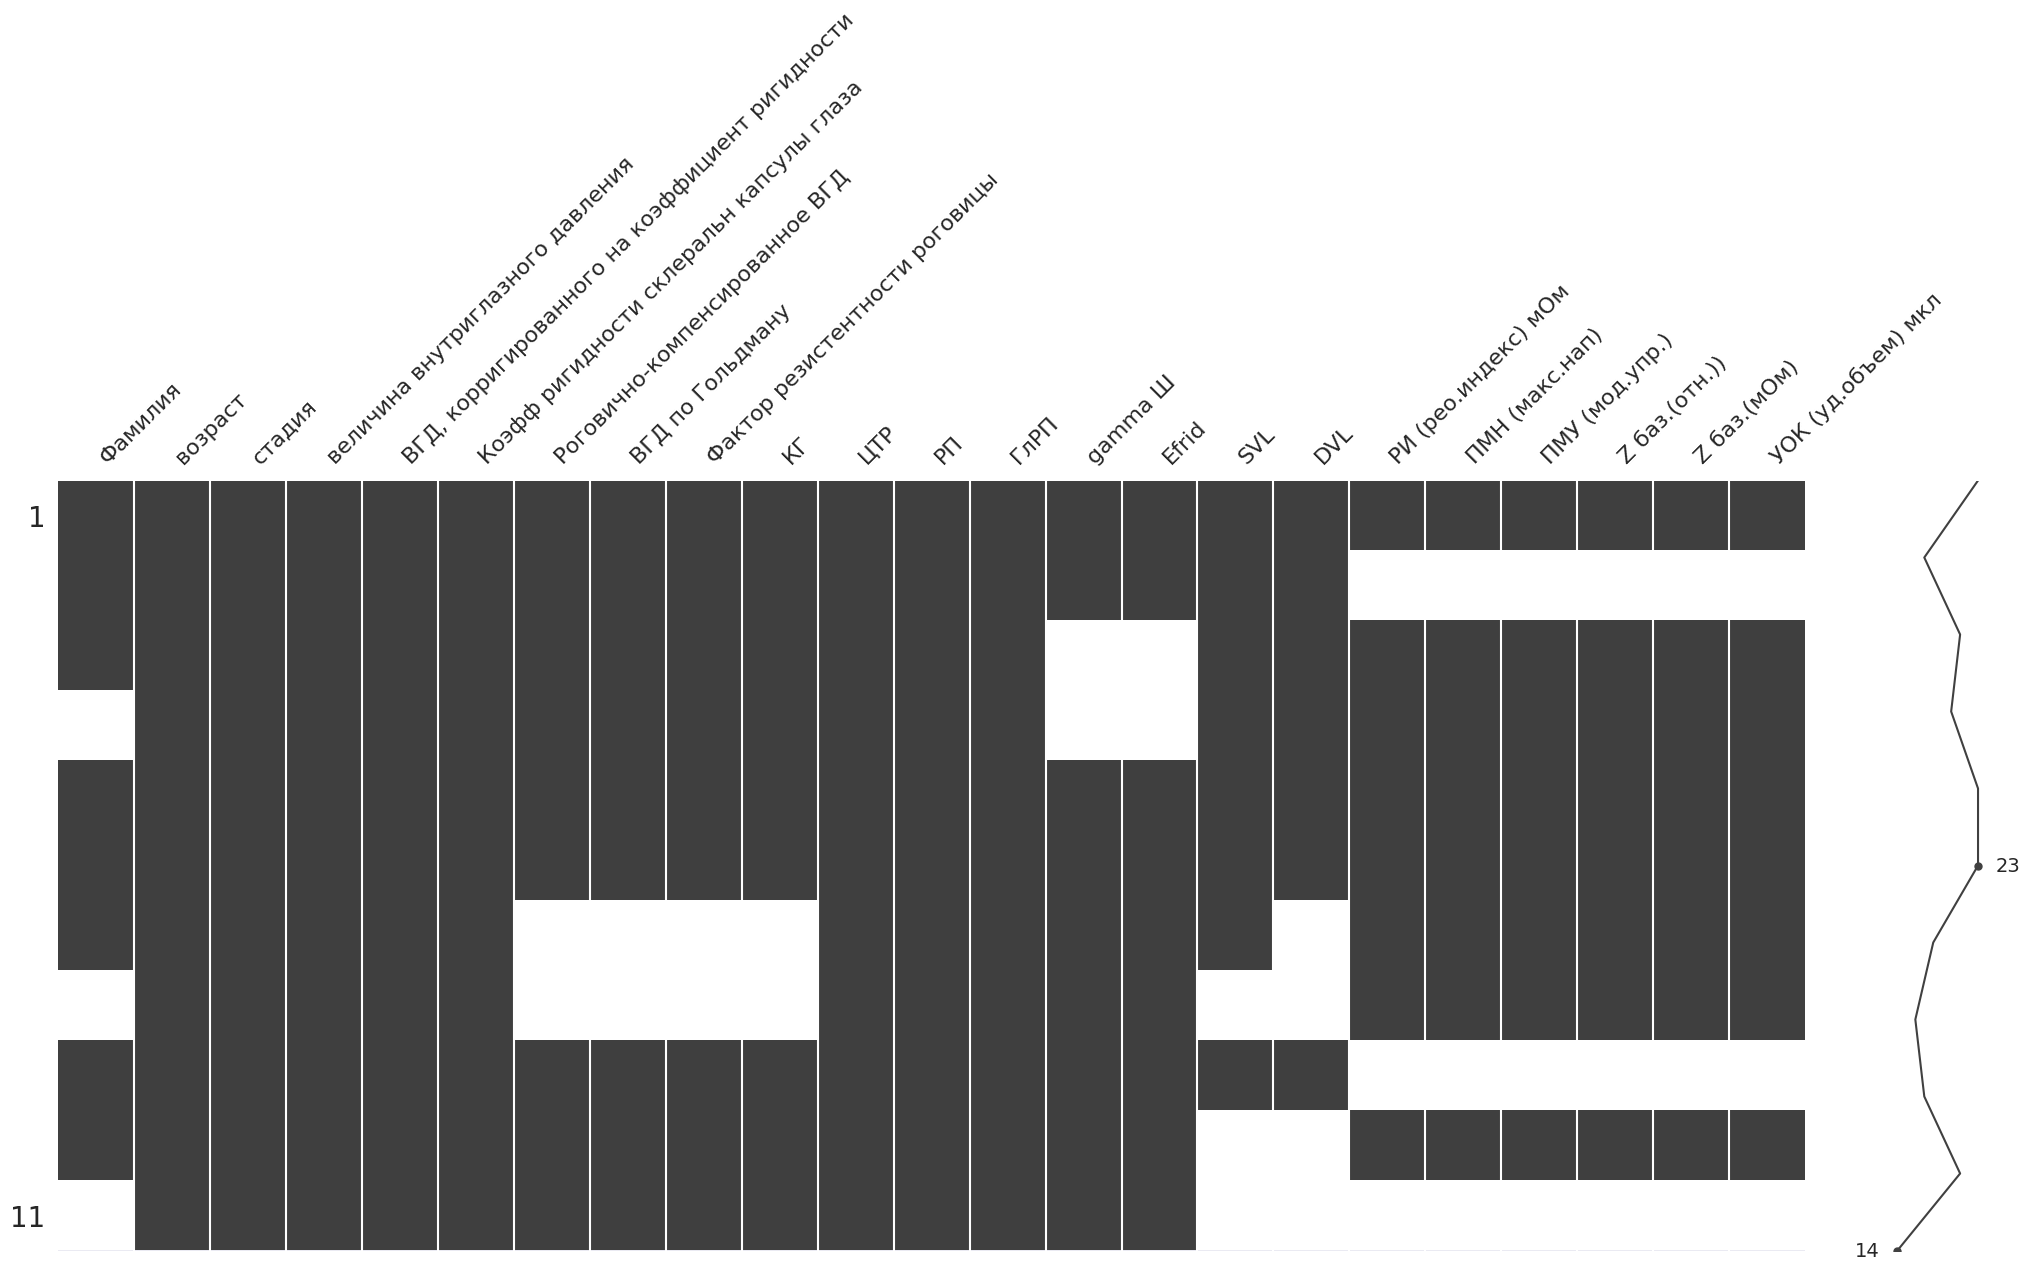

In [ ]:
#матрица пропущенных значений
msno.matrix(data_healthy)

Распределение пропущенных значений выглядит случайным внутри столбцов (закономерностью были бы пропуски, например, только в первой половине наблюдений).

Для того чтобы узнать насколько сильно присутствие или отсутствие значений одного признака влияет на присутствие значений другого, построим **матрицу корреляции пропущенных значений (nullity correlation matrix).**

In [ ]:
tmp_df = data_healthy.iloc[:, [i for i, n in enumerate(np.var(data_healthy.isnull(), axis = 'rows')) if n > 0]]
tmp_df.isnull().corr()

,Фамилия,Роговично-компенсированное ВГД,ВГД по Гольдману,Фактор резистентности роговицы,КГ,gamma Ш,Efrid,SVL,DVL,РИ (рео.индекс) мОм,ПМН (макс.нап),ПМУ (мод.упр.),Z баз.(отн.)),Z баз.(мОм),УОК (уд.объем) мкл
Фамилия,1.000000,0.240563,0.240563,0.240563,0.240563,0.240563,0.240563,0.541667,0.385758,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333
Роговично-компенсированное ВГД,0.240563,1.000000,1.000000,1.000000,1.000000,-0.222222,-0.222222,0.240563,0.623610,-0.288675,-0.288675,-0.288675,-0.288675,-0.288675,-0.288675
ВГД по Гольдману,0.240563,1.000000,1.000000,1.000000,1.000000,-0.222222,-0.222222,0.240563,0.623610,-0.288675,-0.288675,-0.288675,-0.288675,-0.288675,-0.288675
Фактор резистентности роговицы,0.240563,1.000000,1.000000,1.000000,1.000000,-0.222222,-0.222222,0.240563,0.623610,-0.288675,-0.288675,-0.288675,-0.288675,-0.288675,-0.288675
КГ,0.240563,1.000000,1.000000,1.000000,1.000000,-0.222222,-0.222222,0.240563,0.623610,-0.288675,-0.288675,-0.288675,-0.288675,-0.288675,-0.288675
gamma Ш,0.240563,-0.222222,-0.222222,-0.222222,-0.222222,1.000000,1.000000,-0.288675,-0.356348,-0.288675,-0.288675,-0.288675,-0.288675,-0.288675,-0.288675
Efrid,0.240563,-0.222222,-0.222222,-0.222222,-0.222222,1.000000,1.000000,-0.288675,-0.356348,-0.288675,-0.288675,-0.288675,-0.288675,-0.288675,-0.288675
SVL,0.541667,0.240563,0.240563,0.240563,0.240563,-0.288675,-0.288675,1.000000,0.810093,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333
DVL,0.385758,0.623610,0.623610,0.623610,0.623610,-0.356348,-0.356348,0.810093,1.000000,-0.038576,-0.038576,-0.038576,-0.038576,-0.038576,-0.038576
РИ (рео.индекс) мОм,0.083333,-0.288675,-0.288675,-0.288675,-0.288675,-0.288675,-0.288675,0.083333,-0.038576,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Значения корреляции могут быть от −1 (если значения одного признака присутствуют, значения другого — отсутствуют) до 1 (если присутствуют значения одного признака, то присутствуют значения и другого).

Визуально, корреляцию пропущенных значений можно представить с помощью тепловой карты (heatmap). Для этого есть функция msno.heatmap().

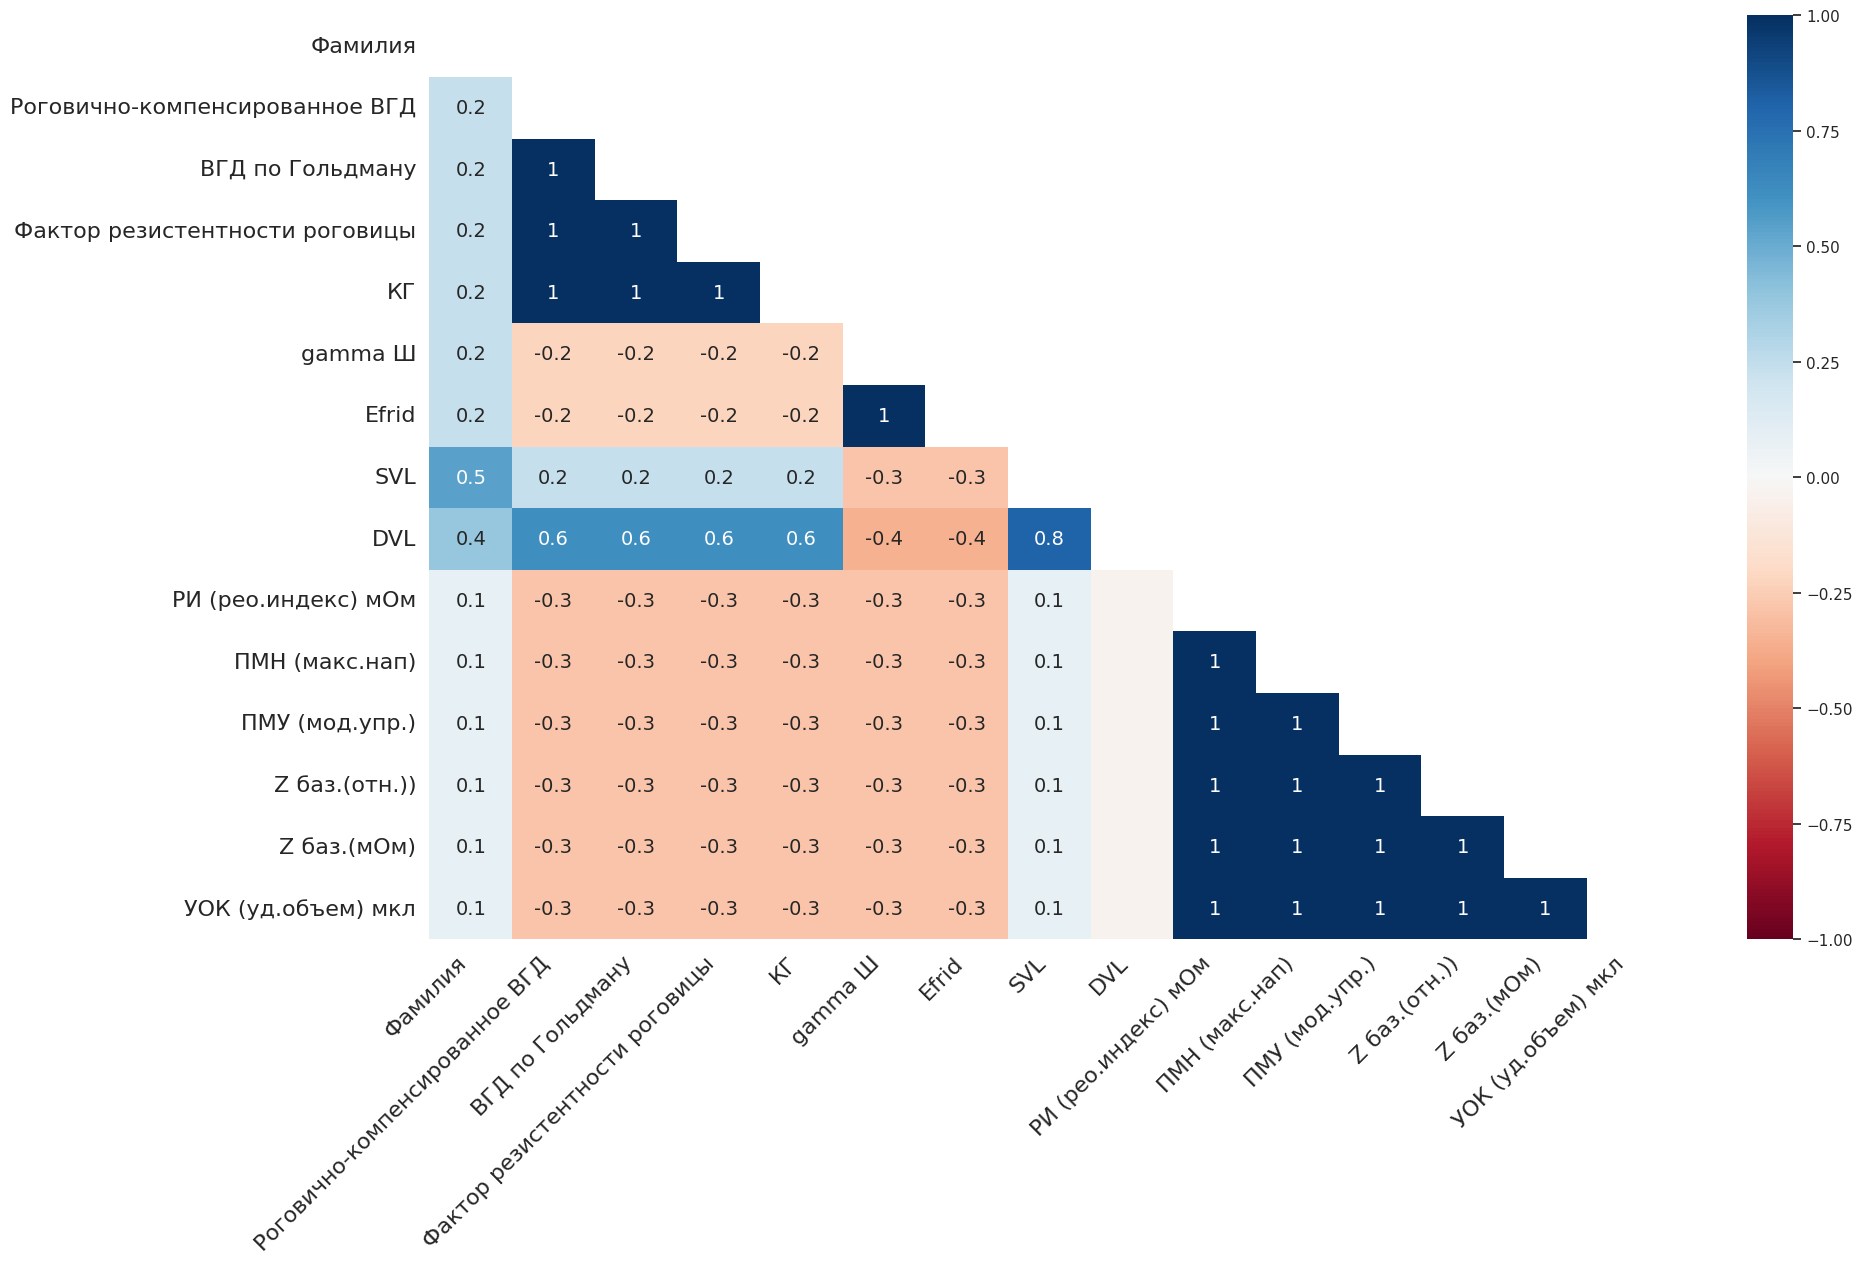

In [ ]:
msno.heatmap(data_healthy);

Заметим, что несколько пропущенных признаков имеют **коэффициент корреляции 1.** Получается, что пропуски одного признака влияют на пропуски другого.

Между собой связаны пропуски по следующим признакам:


*   ВГД по Гольдману и Роговично-компенсированное ВГД
*   Фактор резистентности роговицы и Роговично-компенсированное ВГД
*   Фактор резистентности роговицы и ВГД по Гольдману
*   КГ и Роговично-компенсированное ВГД
*   КГ и ВГД по Гольдману
*   КГ и Фактор резистентности роговицы
*   Efrid и gamma Ш
*   ПМН (макс.нап) и РИ (рео.индекс) мОм
*   ПМУ (мод.упр.) и РИ (рео.индекс) мОм
*   ПМУ (мод.упр.) и ПМН (макс.нап)
*   Z баз.(отн.) и РИ (рео.индекс) мОм  
*   Z баз.(отн.) и ПМН (макс.нап)
*   Z баз.(отн.) и ПМУ (мод.упр.)
*   Z баз.(мОм) и РИ (рео.индекс) мОм
*   Z баз.(мОм) и ПМН (макс.нап)
*   Z баз.(мОм) и ПМУ (мод.упр.)
*   Z баз.(мОм) и Z баз.(отн.)
*   УОК (уд.объем) мкл и РИ (рео.индекс) мОм
*   УОК (уд.объем) мкл и ПМН (макс.нап)
*   УОК (уд.объем) мкл и ПМУ (мод.упр.)
*   УОК (уд.объем) мкл и Z баз.(отн.)
*   УОК (уд.объем) мкл и Z баз.(мОм)

### Заполняем пропуски в категориальных признаках



---
Фамилия - категориальный признак. Заполним значением по умолчанию, например,
"Иванов"

In [ ]:
data_healthy['Фамилия']=data_healthy['Фамилия'].fillna('Иванов')
data_healthy.isnull().sum()

,0
Фамилия,0
возраст,0
стадия,0
величина внутриглазного давления,0
"ВГД, корригированного на коэффициент ригидности",0
Коэфф ригидности склеральн капсулы глаза,0
Роговично-компенсированное ВГД,2
ВГД по Гольдману,2
Фактор резистентности роговицы,2
КГ,2


### Заполняем пропуски в количественных признаках

---

Остальные пропущенные значения принадлежат количественным признакам.

Можно заменить средним значением, модой или медианой.

У такого подхода есть ряд недостатков.

Во-первых, когда в данных появляется большое количество одинаковых близких к среднему значений, мы снижаем ценную вариативность в данных.

Во-вторых, такое заполнение пропусков может быть некорректно.


### Роговично-компенсированное ВГД

In [ ]:
# сделаем копию данных
fillna_median = data_healthy.copy()

# заполним пропуски в столбце 'Роговично-компенсированное ВГД' медианным значением признака,
# можно заполнить и средним арифметическим через метод .mean()
fillna_median['Роговично-компенсированное ВГД'].fillna(fillna_median['Роговично-компенсированное ВГД'].median(), inplace = True)

# убедимся, что пропусков не осталось
fillna_median['Роговично-компенсированное ВГД'].isna().sum()

<ipython-input-134-34e4d44380ba>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  fillna_median['Роговично-компенсированное ВГД'].fillna(fillna_median['Роговично-компенсированное ВГД'].median(), inplace = True)


np.int64(0)

In [ ]:
# изменим размер последующих графиков
sns.set(rc = {'figure.figsize' : (10, 6)})

In [ ]:
# скопируем датафрейм
median_imputer = data_healthy.copy()

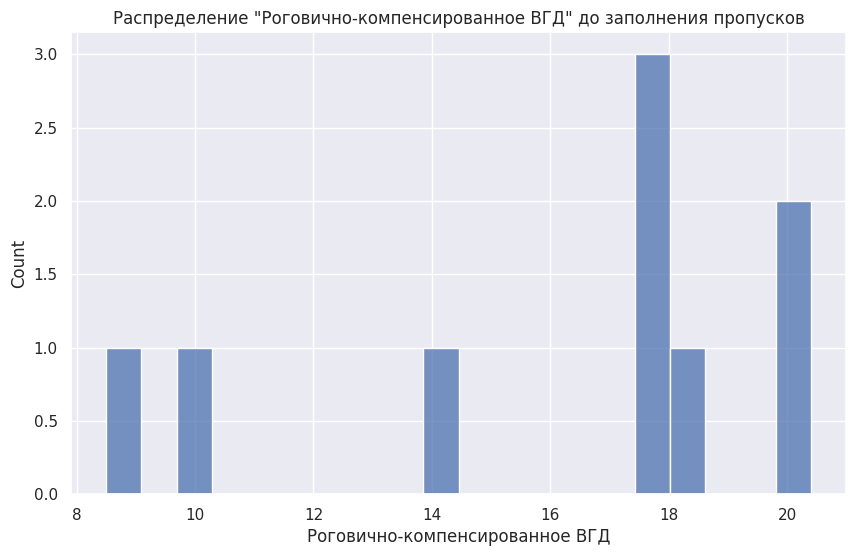

In [ ]:
# посмотрим на распределение 'Роговично-компенсированное ВГД' до заполнения пропусков
sns.histplot(median_imputer['Роговично-компенсированное ВГД'], bins = 20)
plt.title('Распределение "Роговично-компенсированное ВГД" до заполнения пропусков');

In [ ]:
#Посмотрим на среднее арифметическое и медиану.
median_imputer['Роговично-компенсированное ВГД'].mean().round(1), median_imputer['Роговично-компенсированное ВГД'].median()


(np.float64(16.1), 17.8)

In [ ]:
# создадим объект класса SimpleImputer с параметром strategy = 'median'
imp_median = SimpleImputer(strategy = 'median')

# применим метод .fit_transform() для одновременного обучения модели и заполнения пропусков
median_imputer['Роговично-компенсированное ВГД'] = imp_median.fit_transform(median_imputer[['Роговично-компенсированное ВГД']])

In [ ]:
# убедимся, что пропущенных значений не осталось
median_imputer['Роговично-компенсированное ВГД'].isna().sum()

np.int64(0)

Посмотрим на распределение признака и его медианное значение после заполнения пропусков.

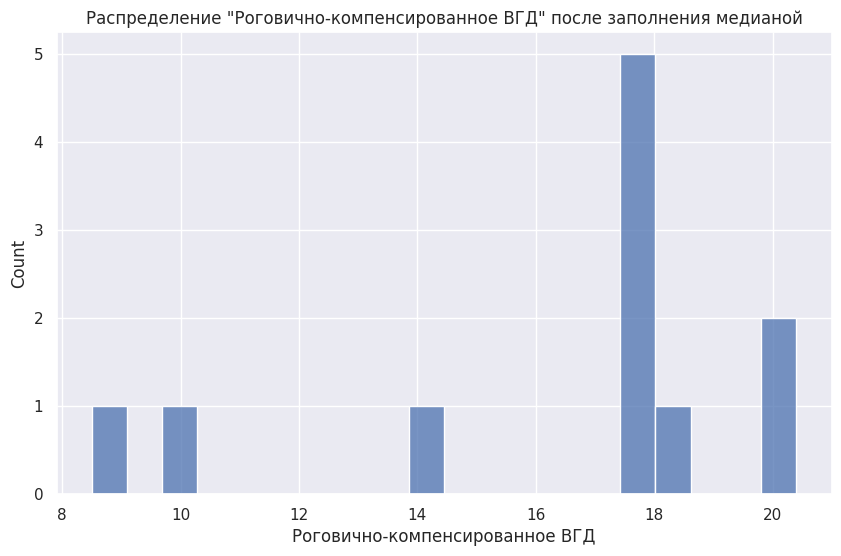

In [ ]:
# посмотрим на распределение после заполнения пропусков
sns.histplot(median_imputer['Роговично-компенсированное ВГД'], bins = 20)
plt.title('Распределение "Роговично-компенсированное ВГД" после заполнения медианой');

In [ ]:
# посмотрим на метрики после заполнения медианой
median_imputer['Роговично-компенсированное ВГД'].mean().round(1), median_imputer['Роговично-компенсированное ВГД'].median()


(np.float64(16.4), 17.8)

Среднее значение изменилось(увеличилось на 0.3), медиана осталось прежней.

По графикам заметим, что распределение не претерпело существенных изменений. Значит можем заполнить пропуски по этой стратегии.

---



Аналогично попробуем заполнить и другие пропуски медианным значением.

### ВГД по Гольдману

In [ ]:
# заполним пропуски в столбце 'ВГД по Гольдману' медианным значением признака
fillna_median['ВГД по Гольдману'].fillna(fillna_median['ВГД по Гольдману'].median(), inplace = True)

# убедимся, что пропусков не осталось
fillna_median['ВГД по Гольдману'].isna().sum()

<ipython-input-143-787d20d99c93>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  fillna_median['ВГД по Гольдману'].fillna(fillna_median['ВГД по Гольдману'].median(), inplace = True)


np.int64(0)

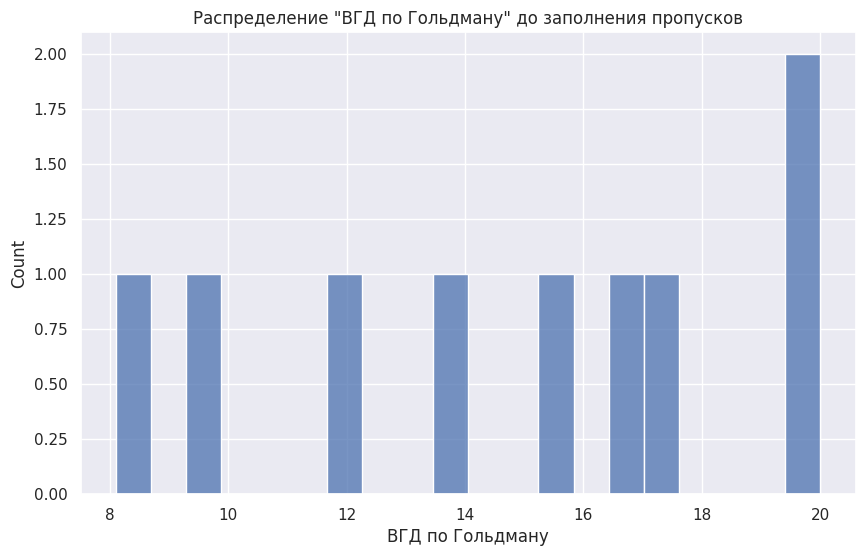

In [ ]:
# посмотрим на распределение 'ВГД по Гольдману' до заполнения пропусков
sns.histplot(data_healthy['ВГД по Гольдману'], bins = 20)
plt.title('Распределение "ВГД по Гольдману" до заполнения пропусков');

In [ ]:
#Посмотрим на среднее арифметическое и медиану.
median_imputer['ВГД по Гольдману'].mean().round(1), median_imputer['ВГД по Гольдману'].median()


(np.float64(14.7), 15.6)

In [ ]:
# создадим объект класса SimpleImputer с параметром strategy = 'median'
imp_median = SimpleImputer(strategy = 'median')

# применим метод .fit_transform() для одновременного обучения модели и заполнения пропусков
median_imputer['ВГД по Гольдману'] = imp_median.fit_transform(median_imputer[['ВГД по Гольдману']])

# убедимся, что пропущенных значений не осталось
median_imputer['ВГД по Гольдману'].isna().sum()

np.int64(0)

Посмотрим на распределение возраста и его медианное значение после заполнения пропусков.

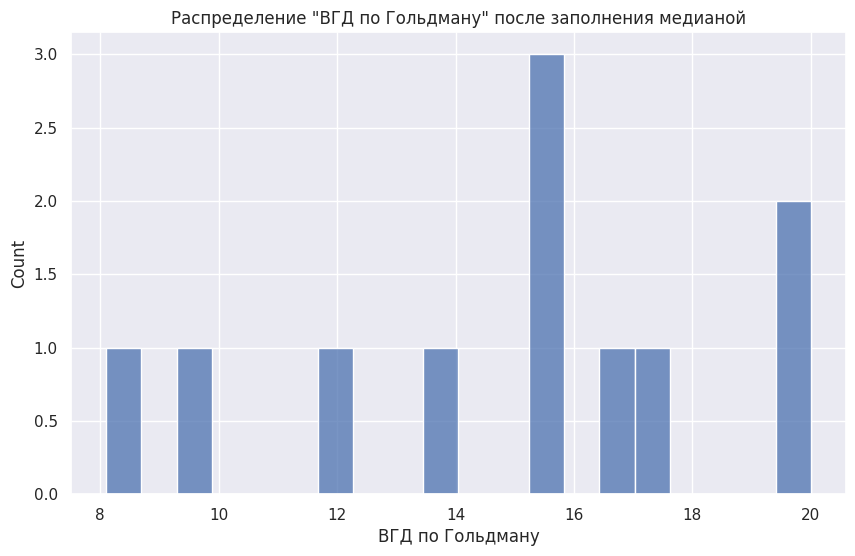

In [ ]:
# посмотрим на распределение после заполнения пропусков
sns.histplot(median_imputer['ВГД по Гольдману'], bins = 20)
plt.title('Распределение "ВГД по Гольдману" после заполнения медианой');

In [ ]:
# посмотрим на метрики после заполнения медианой
median_imputer['ВГД по Гольдману'].mean().round(1), median_imputer['ВГД по Гольдману'].median()


(np.float64(14.9), 15.6)

Среднее значение изменилось(увеличилось на 0.2), медиана осталось прежней.

График распределения визуально **изменился**.

### Фактор резистентности роговицы

In [ ]:
# заполним пропуски в столбце 'Фактор резистентности роговицы' медианным значением признака
fillna_median['Фактор резистентности роговицы'].fillna(fillna_median['Фактор резистентности роговицы'].median(), inplace = True)

# убедимся, что пропусков не осталось
fillna_median['Фактор резистентности роговицы'].isna().sum()

<ipython-input-149-42e70bed7aaa>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  fillna_median['Фактор резистентности роговицы'].fillna(fillna_median['Фактор резистентности роговицы'].median(), inplace = True)


np.int64(0)

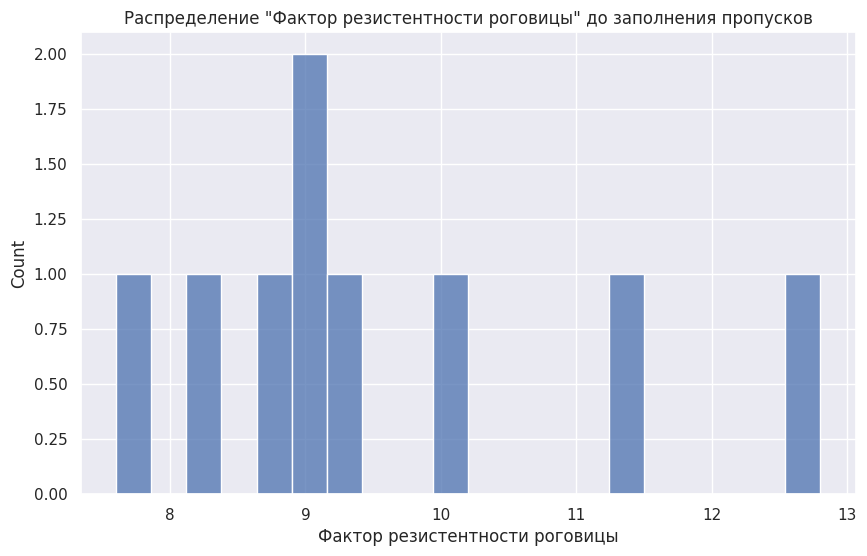

In [ ]:
# посмотрим на распределение 'Фактор резистентности роговицы' до заполнения пропусков
sns.histplot(data_healthy['Фактор резистентности роговицы'], bins = 20)
plt.title('Распределение "Фактор резистентности роговицы" до заполнения пропусков');

In [ ]:
#Посмотрим на среднее арифметическое и медиану.
median_imputer['Фактор резистентности роговицы'].mean().round(1), median_imputer['Фактор резистентности роговицы'].median()


(np.float64(9.6), 9.1)

In [ ]:
# создадим объект класса SimpleImputer с параметром strategy = 'median'
imp_median = SimpleImputer(strategy = 'median')

# применим метод .fit_transform() для одновременного обучения модели и заполнения пропусков
median_imputer['Фактор резистентности роговицы'] = imp_median.fit_transform(median_imputer[['Фактор резистентности роговицы']])

# убедимся, что пропущенных значений не осталось
median_imputer['Фактор резистентности роговицы'].isna().sum()

np.int64(0)

Посмотрим на распределение возраста и его медианное значение после заполнения пропусков.

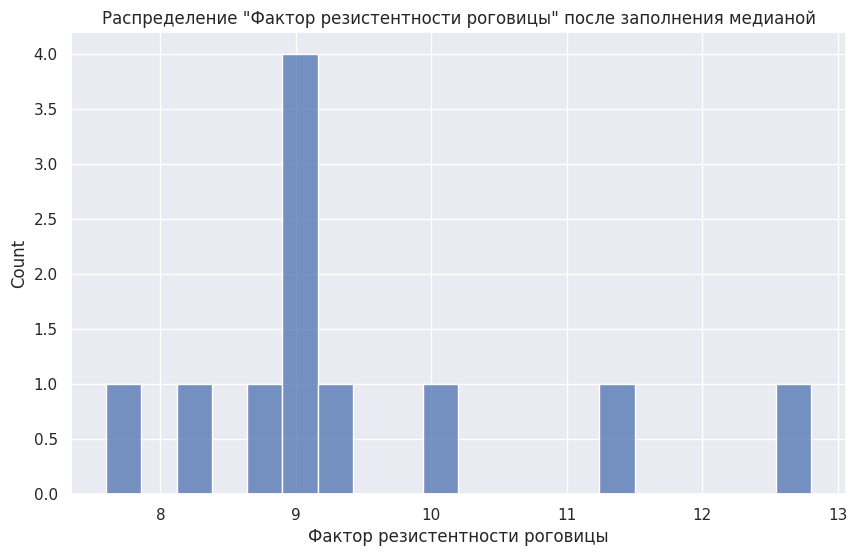

In [ ]:
# посмотрим на распределение после заполнения пропусков
sns.histplot(median_imputer['Фактор резистентности роговицы'], bins = 20)
plt.title('Распределение "Фактор резистентности роговицы" после заполнения медианой');

In [ ]:
# посмотрим на метрики после заполнения медианой
median_imputer['Фактор резистентности роговицы'].mean().round(1), median_imputer['Фактор резистентности роговицы'].median()


(np.float64(9.5), 9.1)

Среднее значение изменилось(увеличилось на 0.1), медиана осталось прежней.

График распределения визуально **незначительно изменился**, форма осталась прежней.



### КГ

In [ ]:
# заполним пропуски в столбце 'КГ' медианным значением признака
fillna_median['КГ'].fillna(fillna_median['КГ'].median(), inplace = True)

# убедимся, что пропусков не осталось
fillna_median['КГ'].isna().sum()

<ipython-input-155-11e3c6bd54cf>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  fillna_median['КГ'].fillna(fillna_median['КГ'].median(), inplace = True)


np.int64(0)

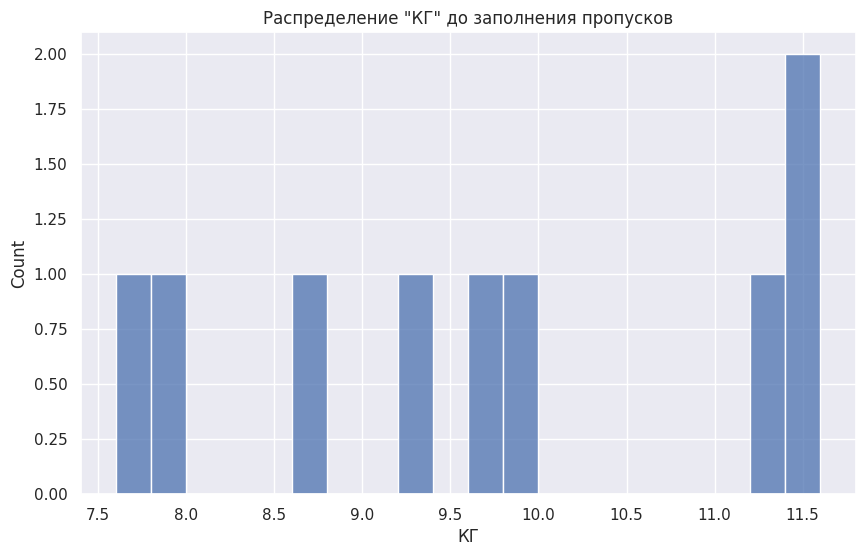

In [ ]:
# посмотрим на распределение 'КГ' до заполнения пропусков
sns.histplot(data_healthy['КГ'], bins = 20)
plt.title('Распределение "КГ" до заполнения пропусков');

In [ ]:
#Посмотрим на среднее арифметическое и медиану.
median_imputer['КГ'].mean().round(1), median_imputer['КГ'].median()


(np.float64(9.7), 9.6)

In [ ]:
# создадим объект класса SimpleImputer с параметром strategy = 'median'
imp_median = SimpleImputer(strategy = 'median')

# применим метод .fit_transform() для одновременного обучения модели и заполнения пропусков
median_imputer['КГ'] = imp_median.fit_transform(median_imputer[['КГ']])

# убедимся, что пропущенных значений не осталось
median_imputer['КГ'].isna().sum()

np.int64(0)

Посмотрим на распределение возраста и его медианное значение после заполнения пропусков.

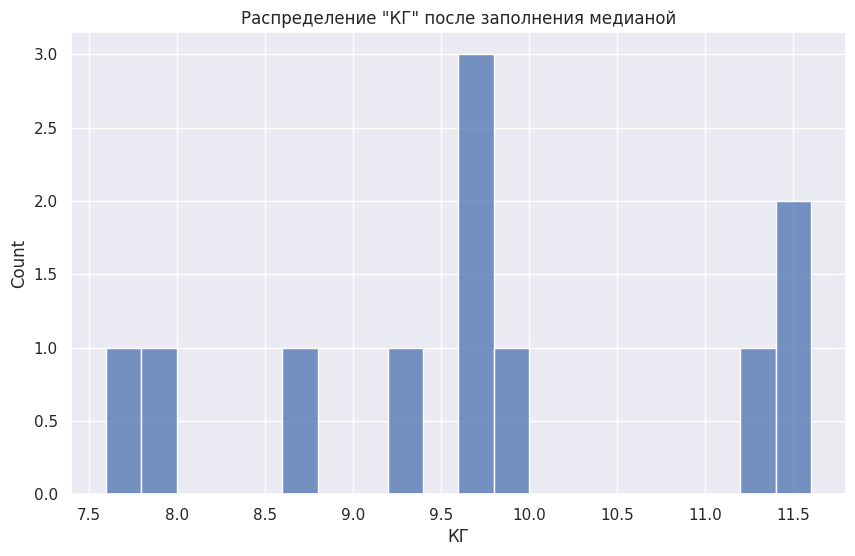

In [ ]:
# посмотрим на распределение после заполнения пропусков
sns.histplot(median_imputer['КГ'], bins = 20)
plt.title('Распределение "КГ" после заполнения медианой');

In [ ]:
# посмотрим на метрики после заполнения медианой
median_imputer['КГ'].mean().round(1), median_imputer['КГ'].median()


(np.float64(9.7), 9.6)

Среднее значение и медиана не изменились.

График распределения визуально **изменился**.

### gamma Ш

In [ ]:
# заполним пропуски в столбце 'gamma Ш' медианным значением признака
fillna_median['gamma Ш'].fillna(fillna_median['gamma Ш'].median(), inplace = True)

# убедимся, что пропусков не осталось
fillna_median['gamma Ш'].isna().sum()

<ipython-input-161-5bec7635ab5b>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  fillna_median['gamma Ш'].fillna(fillna_median['gamma Ш'].median(), inplace = True)


np.int64(0)

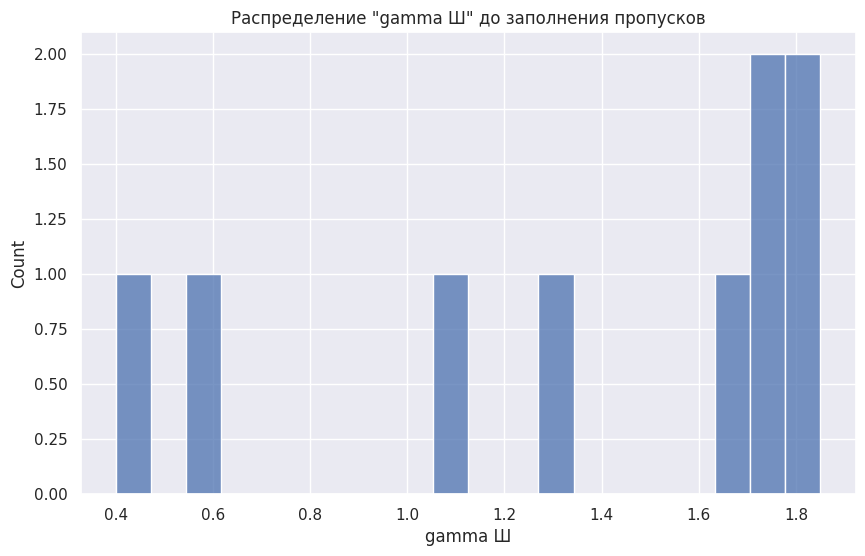

In [ ]:
# посмотрим на распределение 'gamma Ш' до заполнения пропусков
sns.histplot(data_healthy['gamma Ш'], bins = 20)
plt.title('Распределение "gamma Ш" до заполнения пропусков');

In [ ]:
#Посмотрим на среднее арифметическое и медиану.
median_imputer['gamma Ш'].mean().round(1), median_imputer['gamma Ш'].median()


(np.float64(1.4), 1.7)

In [ ]:
# создадим объект класса SimpleImputer с параметром strategy = 'median'
imp_median = SimpleImputer(strategy = 'median')

# применим метод .fit_transform() для одновременного обучения модели и заполнения пропусков
median_imputer['gamma Ш'] = imp_median.fit_transform(median_imputer[['gamma Ш']])

# убедимся, что пропущенных значений не осталось
median_imputer['gamma Ш'].isna().sum()

np.int64(0)

Посмотрим на распределение возраста и его медианное значение после заполнения пропусков.

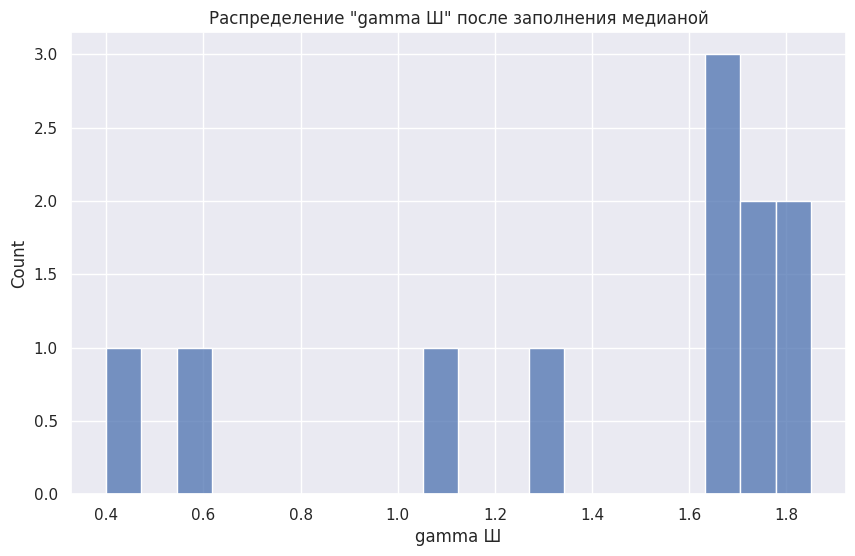

In [ ]:
# посмотрим на распределение после заполнения пропусков
sns.histplot(median_imputer['gamma Ш'], bins = 20)
plt.title('Распределение "gamma Ш" после заполнения медианой');

In [ ]:
# посмотрим на метрики после заполнения медианой
median_imputer['gamma Ш'].mean().round(1), median_imputer['gamma Ш'].median()


(np.float64(1.4), 1.7)

Среднее значение и медиана не изменились.

График распределения визуально **изменился**.

Остальные пропуски также заполним медианным значением

### Остальные пропуски

In [ ]:
#Посмотрим на среднее арифметическое и медиану.
print('Efrid - ', median_imputer['Efrid'].mean().round(1), '  ', median_imputer['Efrid'].median())
print('SVL - ', median_imputer['SVL'].mean().round(1), '  ', median_imputer['SVL'].median())
print('DVL - ', median_imputer['DVL'].mean().round(1), '  ', median_imputer['DVL'].median())
print('РИ (рео.индекс) мОм - ', median_imputer['РИ (рео.индекс) мОм'].mean().round(1), '  ', median_imputer['РИ (рео.индекс) мОм'].median())
print('ПМН (макс.нап) - ', median_imputer['ПМН (макс.нап)'].mean().round(1), '  ', median_imputer['ПМН (макс.нап)'].median())
print('ПМУ (мод.упр.) - ', median_imputer['ПМУ (мод.упр.)'].mean().round(1), '  ', median_imputer['ПМУ (мод.упр.)'].median())
print('Z баз.(отн.)) - ', median_imputer['Z баз.(отн.))'].mean().round(1), '  ', median_imputer['Z баз.(отн.))'].median())
print('Z баз.(мОм) - ', median_imputer['Z баз.(мОм)'].mean().round(1), '  ', median_imputer['Z баз.(мОм)'].median())
print('УОК (уд.объем) мкл - ', median_imputer['УОК (уд.объем) мкл'].mean().round(1), '  ', median_imputer['УОК (уд.объем) мкл'].median())


Efrid -  0.0    0.0138
SVL -  52.4    52.44
DVL -  45.9    45.88
РИ (рео.индекс) мОм -  69.2    51.555
ПМН (макс.нап) -  0.3    0.28
ПМУ (мод.упр.) -  0.3    0.275
Z баз.(отн.)) -  960.8    948.0
Z баз.(мОм) -  38.4    37.92
УОК (уд.объем) мкл -  1.5    1.25286723


In [ ]:
# создадим объект класса SimpleImputer с параметром strategy = 'median'
imp_median = SimpleImputer(strategy = 'median')

# применим метод .fit_transform() для одновременного обучения модели и заполнения пропусков
median_imputer['Efrid'] = imp_median.fit_transform(median_imputer[['Efrid']])
median_imputer['SVL'] = imp_median.fit_transform(median_imputer[['SVL']])
median_imputer['DVL'] = imp_median.fit_transform(median_imputer[['DVL']])
median_imputer['РИ (рео.индекс) мОм'] = imp_median.fit_transform(median_imputer[['РИ (рео.индекс) мОм']])
median_imputer['ПМН (макс.нап)'] = imp_median.fit_transform(median_imputer[['ПМН (макс.нап)']])
median_imputer['ПМУ (мод.упр.)'] = imp_median.fit_transform(median_imputer[['ПМУ (мод.упр.)']])
median_imputer['Z баз.(отн.))'] = imp_median.fit_transform(median_imputer[['Z баз.(отн.))']])
median_imputer['Z баз.(мОм)'] = imp_median.fit_transform(median_imputer[['Z баз.(мОм)']])
median_imputer['УОК (уд.объем) мкл'] = imp_median.fit_transform(median_imputer[['УОК (уд.объем) мкл']])

# убедимся, что пропущенных значений не осталось
median_imputer['УОК (уд.объем) мкл'].isna().sum()

np.int64(0)

In [ ]:
# посмотрим на метрики после заполнения медианой
print('Efrid - ', median_imputer['Efrid'].mean().round(1), '  ', median_imputer['Efrid'].median())
print('SVL - ', median_imputer['SVL'].mean().round(1), '  ', median_imputer['SVL'].median())
print('DVL - ', median_imputer['DVL'].mean().round(1), '  ', median_imputer['DVL'].median())
print('РИ (рео.индекс) мОм - ', median_imputer['РИ (рео.индекс) мОм'].mean().round(1), '  ', median_imputer['РИ (рео.индекс) мОм'].median())
print('ПМН (макс.нап) - ', median_imputer['ПМН (макс.нап)'].mean().round(1), '  ', median_imputer['ПМН (макс.нап)'].median())
print('ПМУ (мод.упр.) - ', median_imputer['ПМУ (мод.упр.)'].mean().round(1), '  ', median_imputer['ПМУ (мод.упр.)'].median())
print('Z баз.(отн.)) - ', median_imputer['Z баз.(отн.))'].mean().round(1), '  ', median_imputer['Z баз.(отн.))'].median())
print('Z баз.(мОм) - ', median_imputer['Z баз.(мОм)'].mean().round(1), '  ', median_imputer['Z баз.(мОм)'].median())
print('УОК (уд.объем) мкл - ', median_imputer['УОК (уд.объем) мкл'].mean().round(1), '  ', median_imputer['УОК (уд.объем) мкл'].median())


Efrid -  0.0    0.0138
SVL -  52.4    52.44
DVL -  45.9    45.88
РИ (рео.индекс) мОм -  64.4    51.555
ПМН (макс.нап) -  0.3    0.28
ПМУ (мод.упр.) -  0.3    0.275
Z баз.(отн.)) -  957.3    948.0
Z баз.(мОм) -  38.3    37.92
УОК (уд.объем) мкл -  1.5    1.25286723


Среднее значение и медиана не изменились для признаков Efrid, SVL, DVL, ПМН(макс.нап), ПМН(мод.упр.), УОК (уд.объем) мкл.

Заметно изменение среднего значения РИ (рео.индекс) мОм, Z баз.(отн.) и Z баз.(мОм).

Проверяем, что заполнили все пропуски.

In [ ]:
median_imputer.isnull().sum()

,0
Фамилия,0
возраст,0
стадия,0
величина внутриглазного давления,0
"ВГД, корригированного на коэффициент ригидности",0
Коэфф ригидности склеральн капсулы глаза,0
Роговично-компенсированное ВГД,0
ВГД по Гольдману,0
Фактор резистентности роговицы,0
КГ,0


## Сравниваем взаимосвязь признаков до и после заполнения пропусков

In [ ]:
corr_matrix_before=data_healthy.iloc [:, 1:11].corr().round(3)

<Axes: >

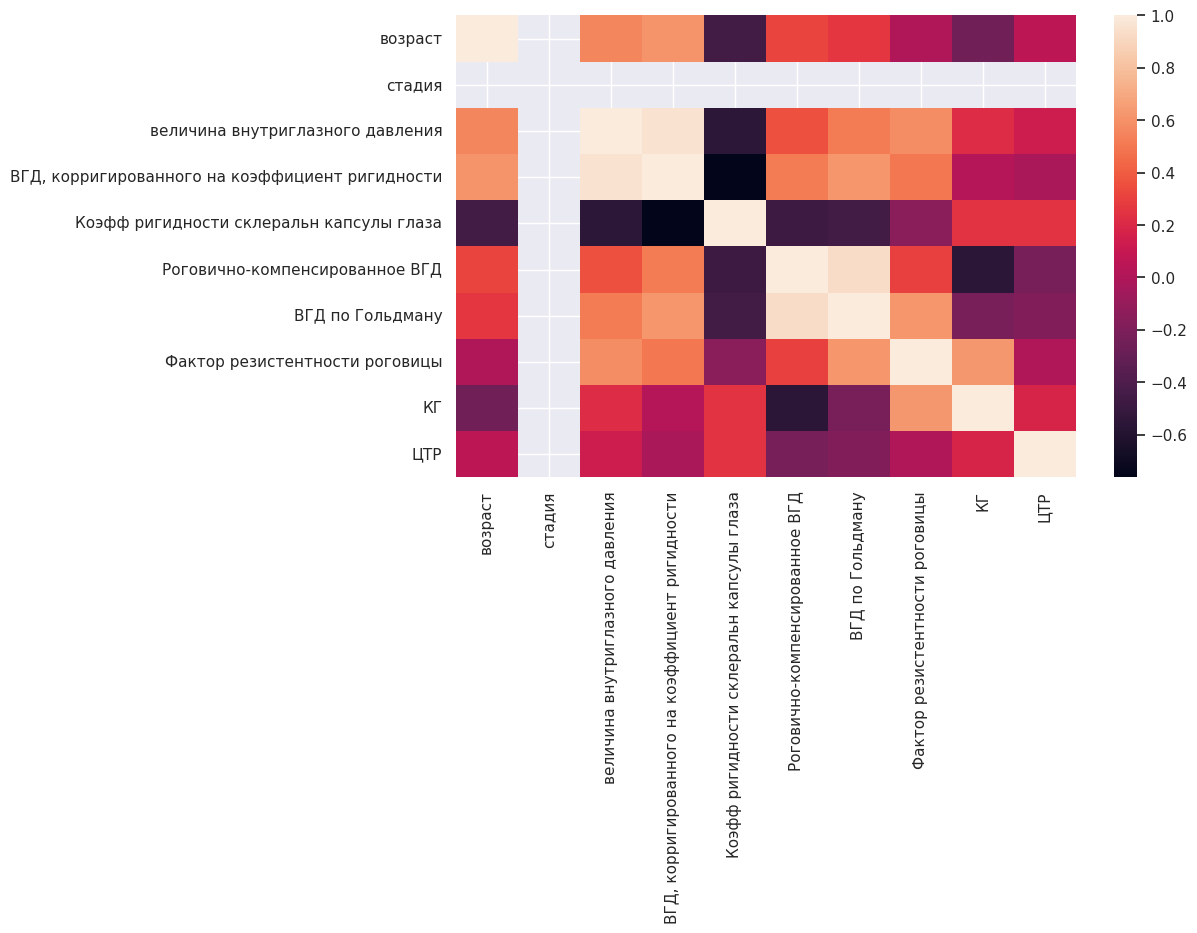

In [ ]:
sns.heatmap(corr_matrix_before)

In [ ]:
corr_matrix_after=median_imputer.iloc [:, 1:11].corr().round(3)

<Axes: >

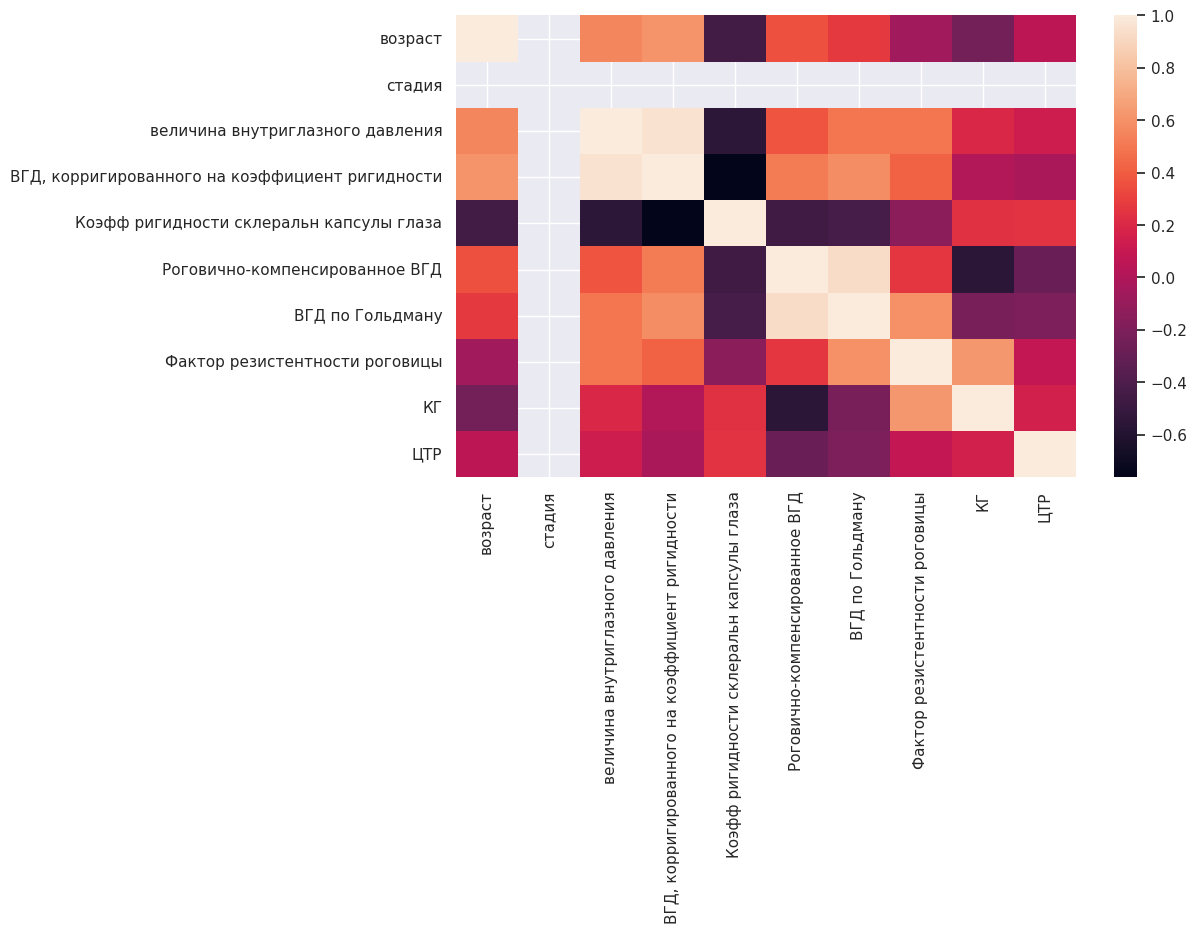

In [ ]:
sns.heatmap(corr_matrix_after)

Визуально взаимосвязь дополненных показателей с другими не изменилась.

In [ ]:
changes_in_corr=corr_matrix_before-corr_matrix_after

In [ ]:
changes_in_corr

,возраст,стадия,величина внутриглазного давления,"ВГД, корригированного на коэффициент ригидности",Коэфф ригидности склеральн капсулы глаза,Роговично-компенсированное ВГД,ВГД по Гольдману,Фактор резистентности роговицы,КГ,ЦТР
возраст,0.000,NaN,0.000,0.000,0.000,-0.041,-0.011,0.061,-0.019,0.000
стадия,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
величина внутриглазного давления,0.000,NaN,0.000,0.000,0.000,-0.016,0.017,0.088,0.024,0.000
"ВГД, корригированного на коэффициент ригидности",0.000,NaN,0.000,0.000,0.000,0.005,0.031,0.082,0.008,0.000
Коэфф ригидности склеральн капсулы глаза,0.000,NaN,0.000,0.000,0.000,-0.012,-0.011,-0.012,0.006,0.000
Роговично-компенсированное ВГД,-0.041,NaN,-0.016,0.005,-0.012,0.000,0.002,0.030,-0.005,0.055
ВГД по Гольдману,-0.011,NaN,0.017,0.031,-0.011,0.002,0.000,0.020,0.001,0.014
Фактор резистентности роговицы,0.061,NaN,0.088,0.082,-0.012,0.030,0.020,0.000,0.002,-0.082
КГ,-0.019,NaN,0.024,0.008,0.006,-0.005,0.001,0.002,0.000,0.026
ЦТР,0.000,NaN,0.000,0.000,0.000,0.055,0.014,-0.082,0.026,0.000


Изменения произошли, но они достаточно малы.

<Axes: >

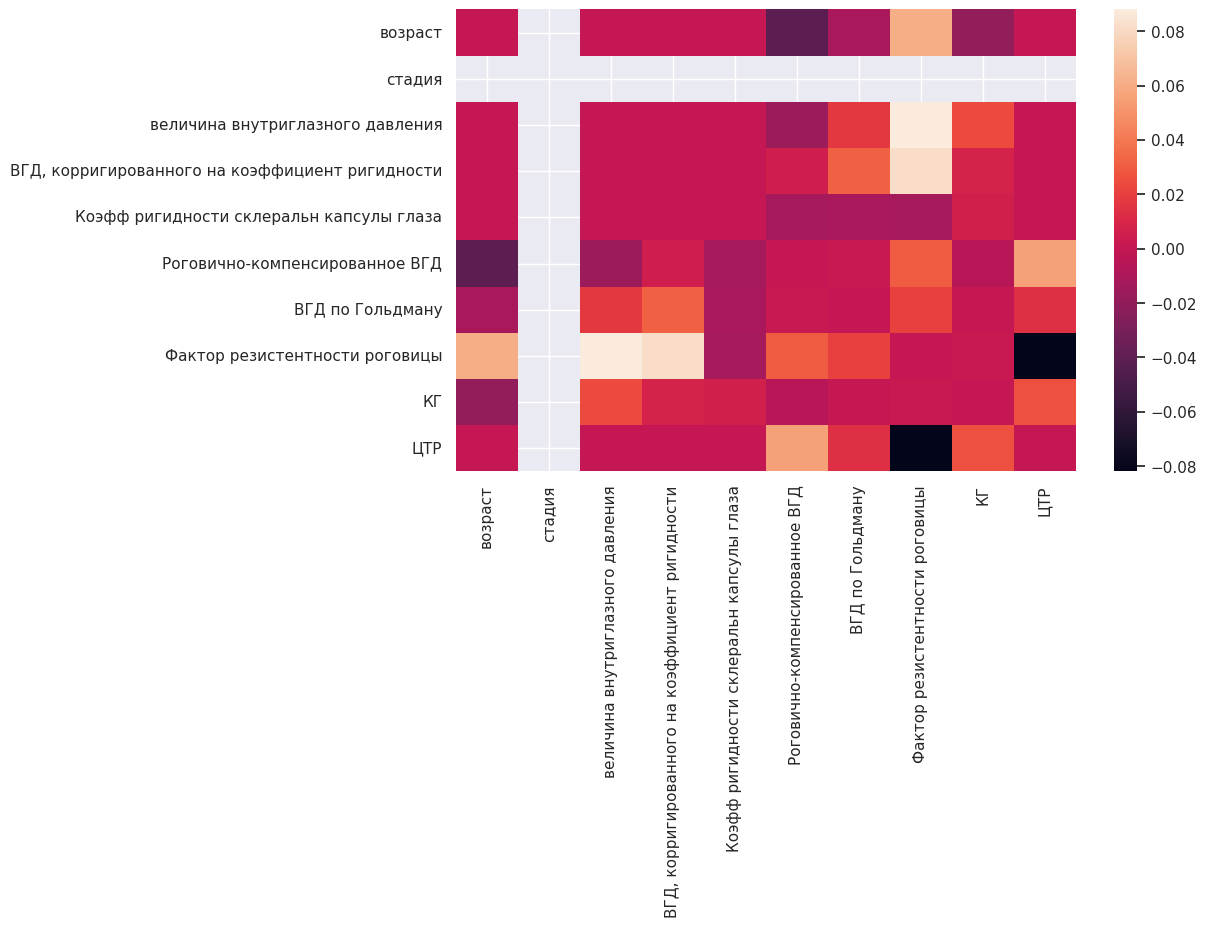

In [ ]:
sns.heatmap(changes_in_corr)

Обновили актуальную таблицу, пропуски заполнены медианой

In [ ]:
data_healthy=median_imputer

Аналогично будут обработаны таблицы для 1й, 2й и 3й стадий

## Работа с пропущенными значениями в таблице с пациентами **1 стадии заболевания**

In [ ]:
data_1_stage

,Фамилия,возраст,стадия,величина внутриглазного давления,"ВГД, корригированного на коэффициент ригидности",Коэфф ригидности склеральн капсулы глаза,Роговично-компенсированное ВГД,ВГД по Гольдману,Фактор резистентности роговицы,КГ,...,gamma Ш,Efrid,SVL,DVL,РИ (рео.индекс) мОм,ПМН (макс.нап),ПМУ (мод.упр.),Z баз.(отн.)),Z баз.(мОм),УОК (уд.объем) мкл
0,горнева,84,1,13,27,0.0007,16.1,14.7,9.5,9.6,...,0.45,0.0007,NaN,NaN,30.27,0.27,0.31,NaN,NaN,NaN
1,фокина,64,1,20,30,0.0053,20.0,20.0,11.0,10.0,...,0.55,0.0053,46.73000,34.530000,44.00,0.11,0.20,982.0,39.28,1.022709
2,петрова,56,1,18,21,0.0148,23.7,23.1,11.7,9.3,...,2.00,0.0148,54.63000,42.690000,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,56,1,21,18,0.0268,26.8,25.6,11.8,8.5,...,2.10,0.0268,53.75000,41.320000,NaN,NaN,NaN,NaN,NaN,NaN
4,ефременкова,65,1,7,9,0.0167,17.7,14.4,8.0,8.0,...,1.95,0.0167,50.50000,47.950000,76.00,0.05,0.09,1077.0,43.08,1.610678
5,NaN,65,1,13,24,0.0040,21.5,17.8,8.3,7.1,...,1.00,0.0040,45.15000,34.910000,71.00,0.04,0.07,972.0,38.88,1.667258
6,набатчикова,72,1,11,12,0.0032,21.0,20.0,11.7,9.3,...,NaN,NaN,51.60000,46.270000,44.47,0.44,0.38,1060.0,42.40,0.957573
7,огулева,65,1,8,19,0.0038,12.2,13.5,11.5,12.3,...,0.95,0.0038,50.21000,35.930000,66.77,0.23,0.26,1193.0,47.72,1.277473
8,калядова,73,1,14,17,0.0167,21.2,19.1,9.8,8.4,...,1.85,0.0167,43.23000,35.580000,66.97,0.34,0.32,900.0,36.00,1.698434
9,казакова,66,1,13,17,0.0147,12.4,12.3,10.1,11.2,...,1.90,0.0147,51.05000,48.600000,60.47,0.62,0.58,878.0,35.12,1.572013


In [ ]:
#посмотрим сколько пропущенных значений в данных
data_1_stage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 23 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Фамилия                                          12 non-null     object 
 1   возраст                                          15 non-null     int64  
 2   стадия                                           15 non-null     int64  
 3   величина внутриглазного давления                 15 non-null     int64  
 4   ВГД, корригированного на коэффициент ригидности  15 non-null     int64  
 5   Коэфф ригидности склеральн капсулы глаза         15 non-null     float64
 6   Роговично-компенсированное ВГД                   14 non-null     float64
 7   ВГД по Гольдману                                 14 non-null     float64
 8   Фактор резистентности роговицы                   14 non-null     float64
 9   КГ                                

In [ ]:
data_1_stage.isnull().sum()

,0
Фамилия,3
возраст,0
стадия,0
величина внутриглазного давления,0
"ВГД, корригированного на коэффициент ригидности",0
Коэфф ригидности склеральн капсулы глаза,0
Роговично-компенсированное ВГД,1
ВГД по Гольдману,1
Фактор резистентности роговицы,1
КГ,1


Рассчитаем процент пропусков

In [ ]:
(data_1_stage.isna().sum() / len(data_1_stage)).round(4) * 100

,0
Фамилия,20.00
возраст,0.00
стадия,0.00
величина внутриглазного давления,0.00
"ВГД, корригированного на коэффициент ригидности",0.00
Коэфф ригидности склеральн капсулы глаза,0.00
Роговично-компенсированное ВГД,6.67
ВГД по Гольдману,6.67
Фактор резистентности роговицы,6.67
КГ,6.67


Вывод: пропуски есть по 18 признакам из 23, процент пропущенных данных в основном около 13-20%. На основе этого становится понятно, что удалять данные с пропущенными значениями - неподходящий способ в данной ситуации.

<Axes: >

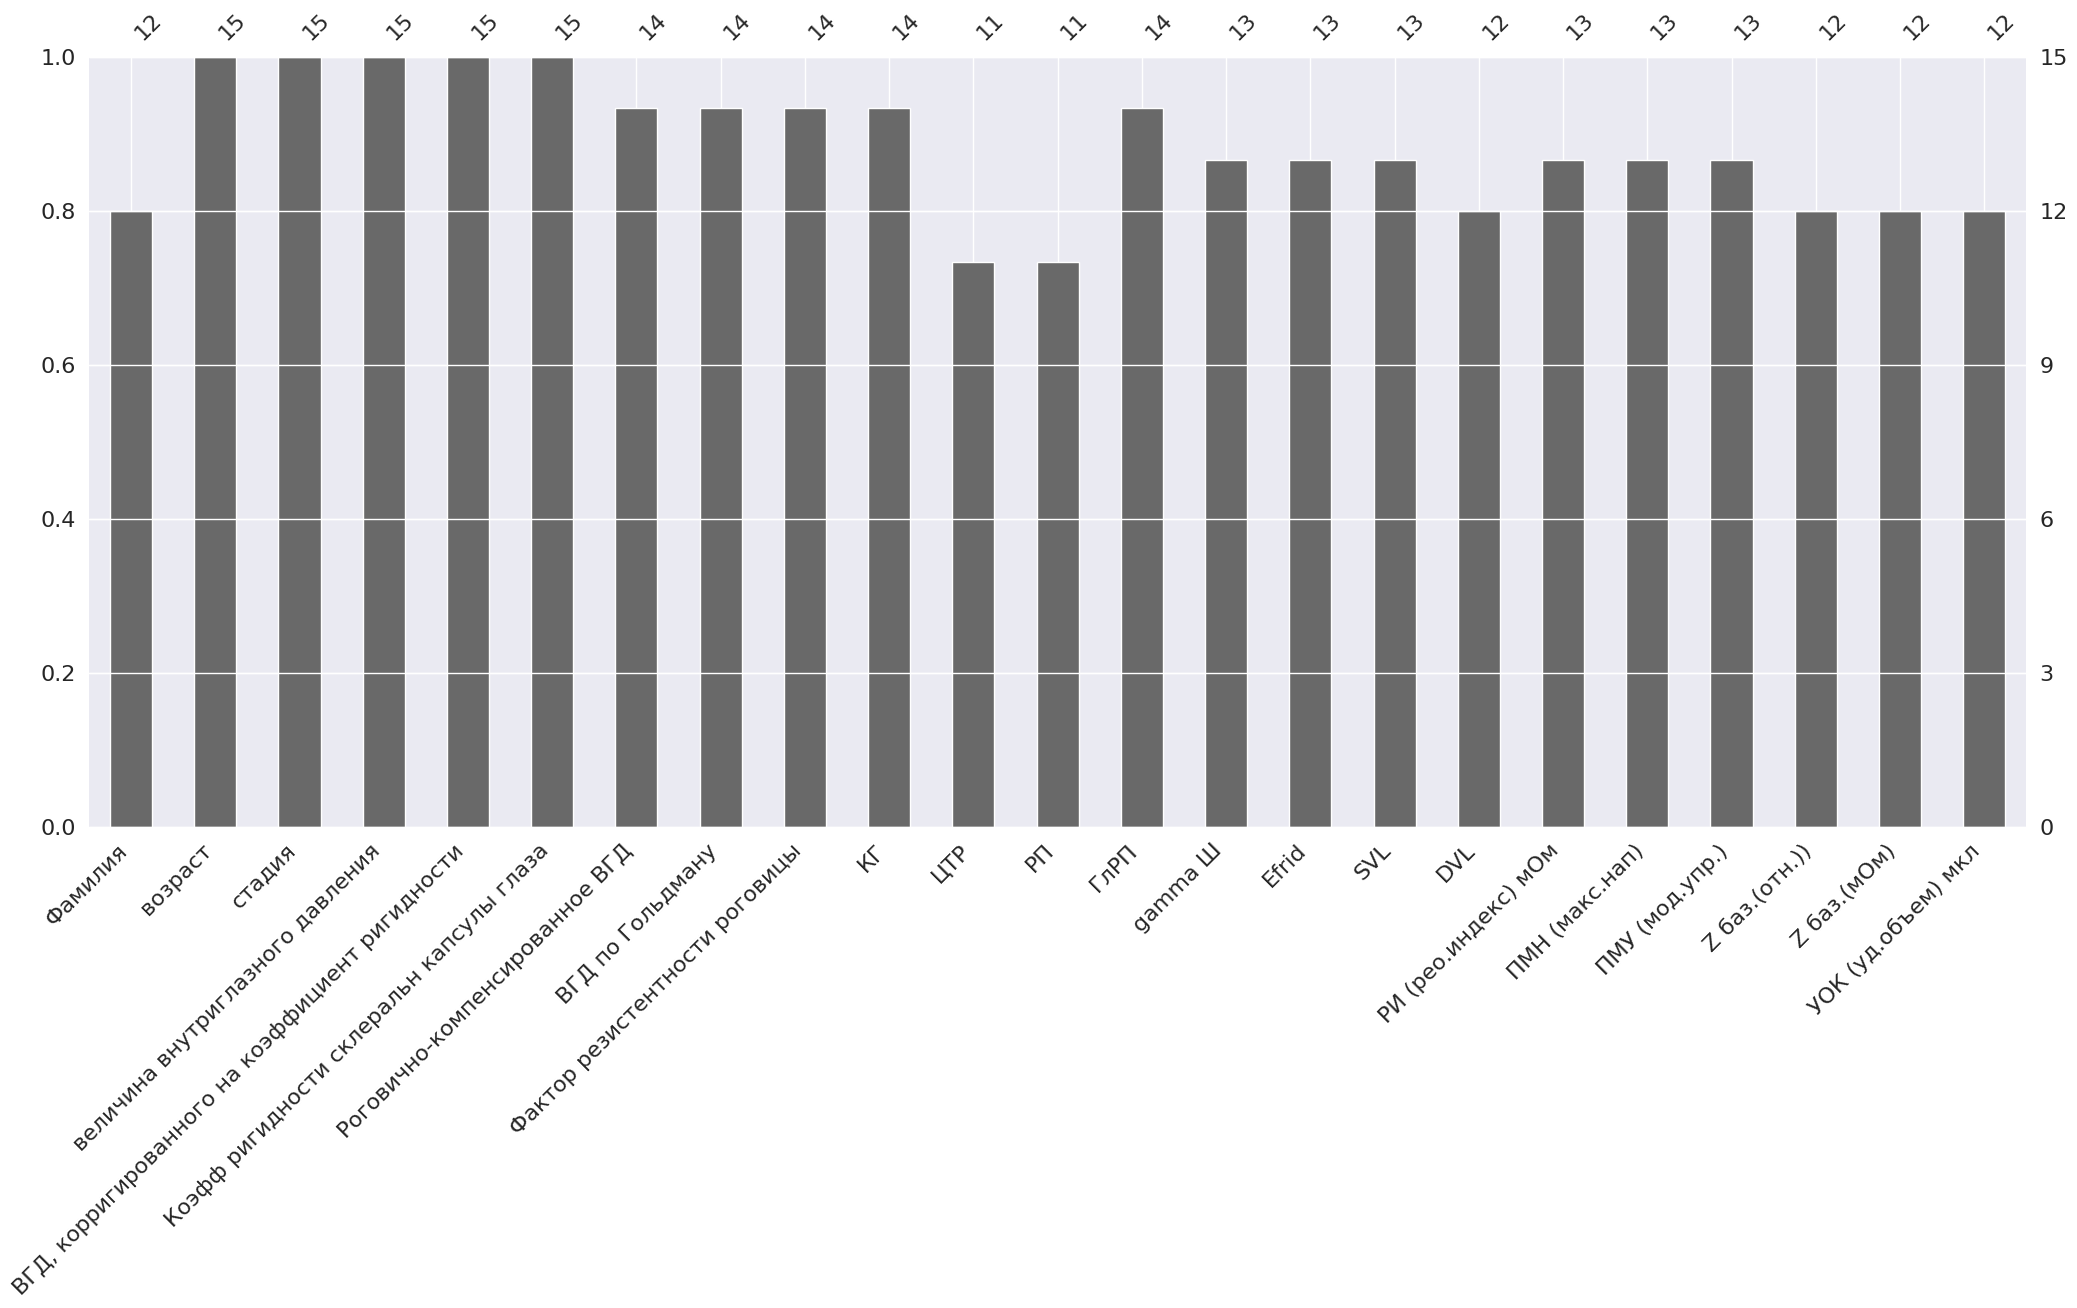

In [ ]:
msno.bar(data_1_stage)

<Axes: >

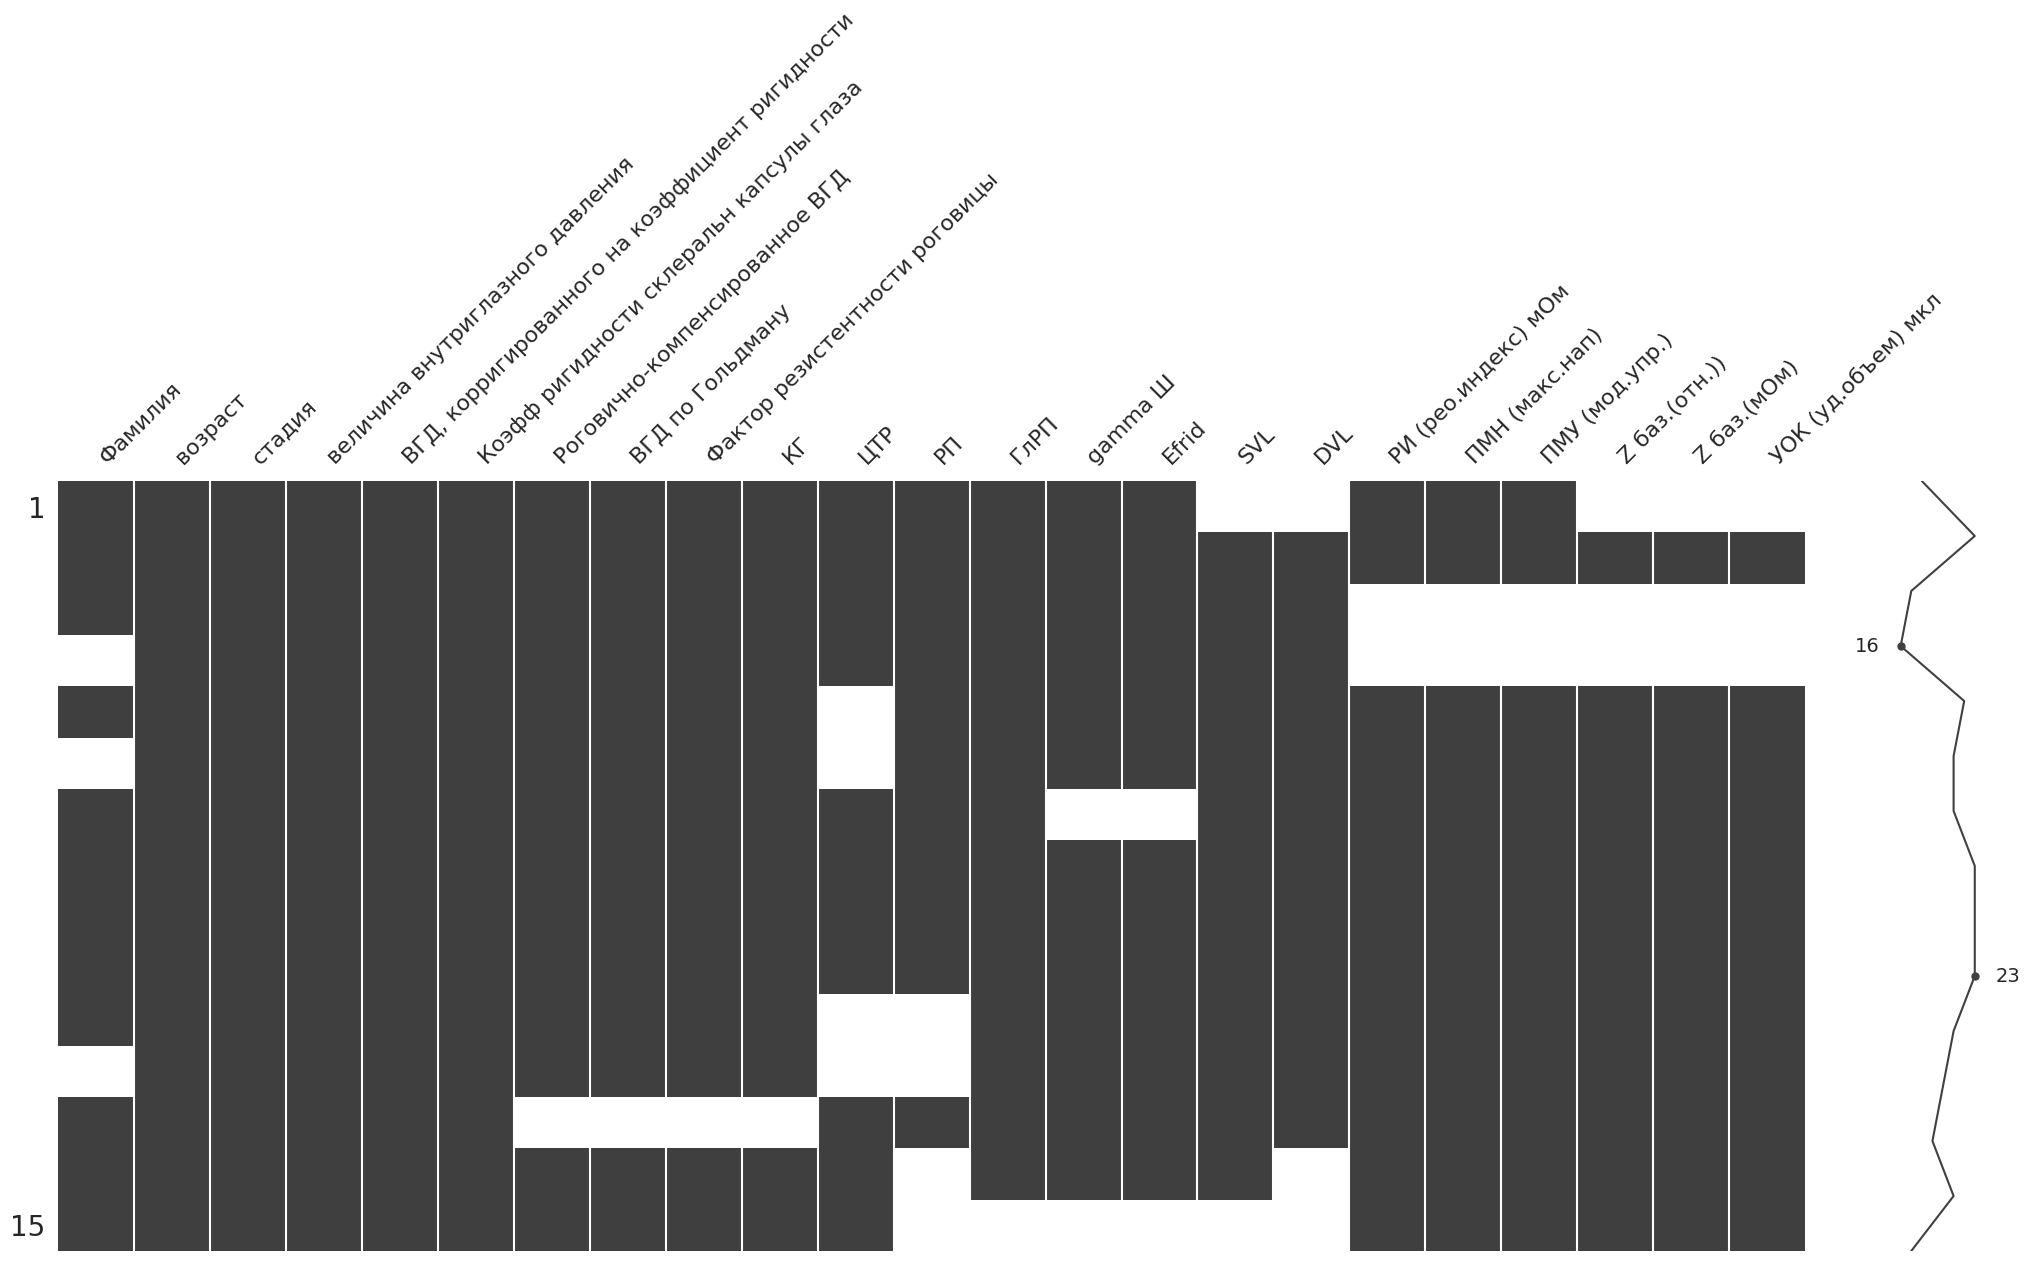

In [ ]:
#матрица пропущенных значений
msno.matrix(data_1_stage)

Выяснили, что пропуски носят случайный характер. Приступаем к их заполнению.

Построим **матрицу корреляции пропущенных значений** (nullity correlation matrix).

In [ ]:
tmp_df = data_1_stage.iloc[:, [i for i, n in enumerate(np.var(data_1_stage.isnull(), axis = 'rows')) if n > 0]]
tmp_df.isnull().corr()

,Фамилия,Роговично-компенсированное ВГД,ВГД по Гольдману,Фактор резистентности роговицы,КГ,ЦТР,РП,ГлРП,gamma Ш,Efrid,SVL,DVL,РИ (рео.индекс) мОм,ПМН (макс.нап),ПМУ (мод.упр.),Z баз.(отн.)),Z баз.(мОм),УОК (уд.объем) мкл
Фамилия,1.000000,-0.133631,-0.133631,-0.133631,-0.133631,0.452267,0.075378,-0.133631,-0.196116,-0.196116,-0.196116,-0.250000,0.294174,0.294174,0.294174,0.166667,0.166667,0.166667
Роговично-компенсированное ВГД,-0.133631,1.000000,1.000000,1.000000,1.000000,-0.161165,-0.161165,-0.071429,-0.104828,-0.104828,-0.104828,-0.133631,-0.104828,-0.104828,-0.104828,-0.133631,-0.133631,-0.133631
ВГД по Гольдману,-0.133631,1.000000,1.000000,1.000000,1.000000,-0.161165,-0.161165,-0.071429,-0.104828,-0.104828,-0.104828,-0.133631,-0.104828,-0.104828,-0.104828,-0.133631,-0.133631,-0.133631
Фактор резистентности роговицы,-0.133631,1.000000,1.000000,1.000000,1.000000,-0.161165,-0.161165,-0.071429,-0.104828,-0.104828,-0.104828,-0.133631,-0.104828,-0.104828,-0.104828,-0.133631,-0.133631,-0.133631
КГ,-0.133631,1.000000,1.000000,1.000000,1.000000,-0.161165,-0.161165,-0.071429,-0.104828,-0.104828,-0.104828,-0.133631,-0.104828,-0.104828,-0.104828,-0.133631,-0.133631,-0.133631
ЦТР,0.452267,-0.161165,-0.161165,-0.161165,-0.161165,1.000000,0.318182,-0.161165,-0.236525,-0.236525,-0.236525,-0.301511,-0.236525,-0.236525,-0.236525,-0.301511,-0.301511,-0.301511
РП,0.075378,-0.161165,-0.161165,-0.161165,-0.161165,0.318182,1.000000,0.443203,0.206959,0.206959,0.206959,0.452267,-0.236525,-0.236525,-0.236525,-0.301511,-0.301511,-0.301511
ГлРП,-0.133631,-0.071429,-0.071429,-0.071429,-0.071429,-0.161165,0.443203,1.000000,0.681385,0.681385,0.681385,0.534522,-0.104828,-0.104828,-0.104828,-0.133631,-0.133631,-0.133631
gamma Ш,-0.196116,-0.104828,-0.104828,-0.104828,-0.104828,-0.236525,0.206959,0.681385,1.000000,1.000000,0.423077,0.294174,-0.153846,-0.153846,-0.153846,-0.196116,-0.196116,-0.196116
Efrid,-0.196116,-0.104828,-0.104828,-0.104828,-0.104828,-0.236525,0.206959,0.681385,1.000000,1.000000,0.423077,0.294174,-0.153846,-0.153846,-0.153846,-0.196116,-0.196116,-0.196116


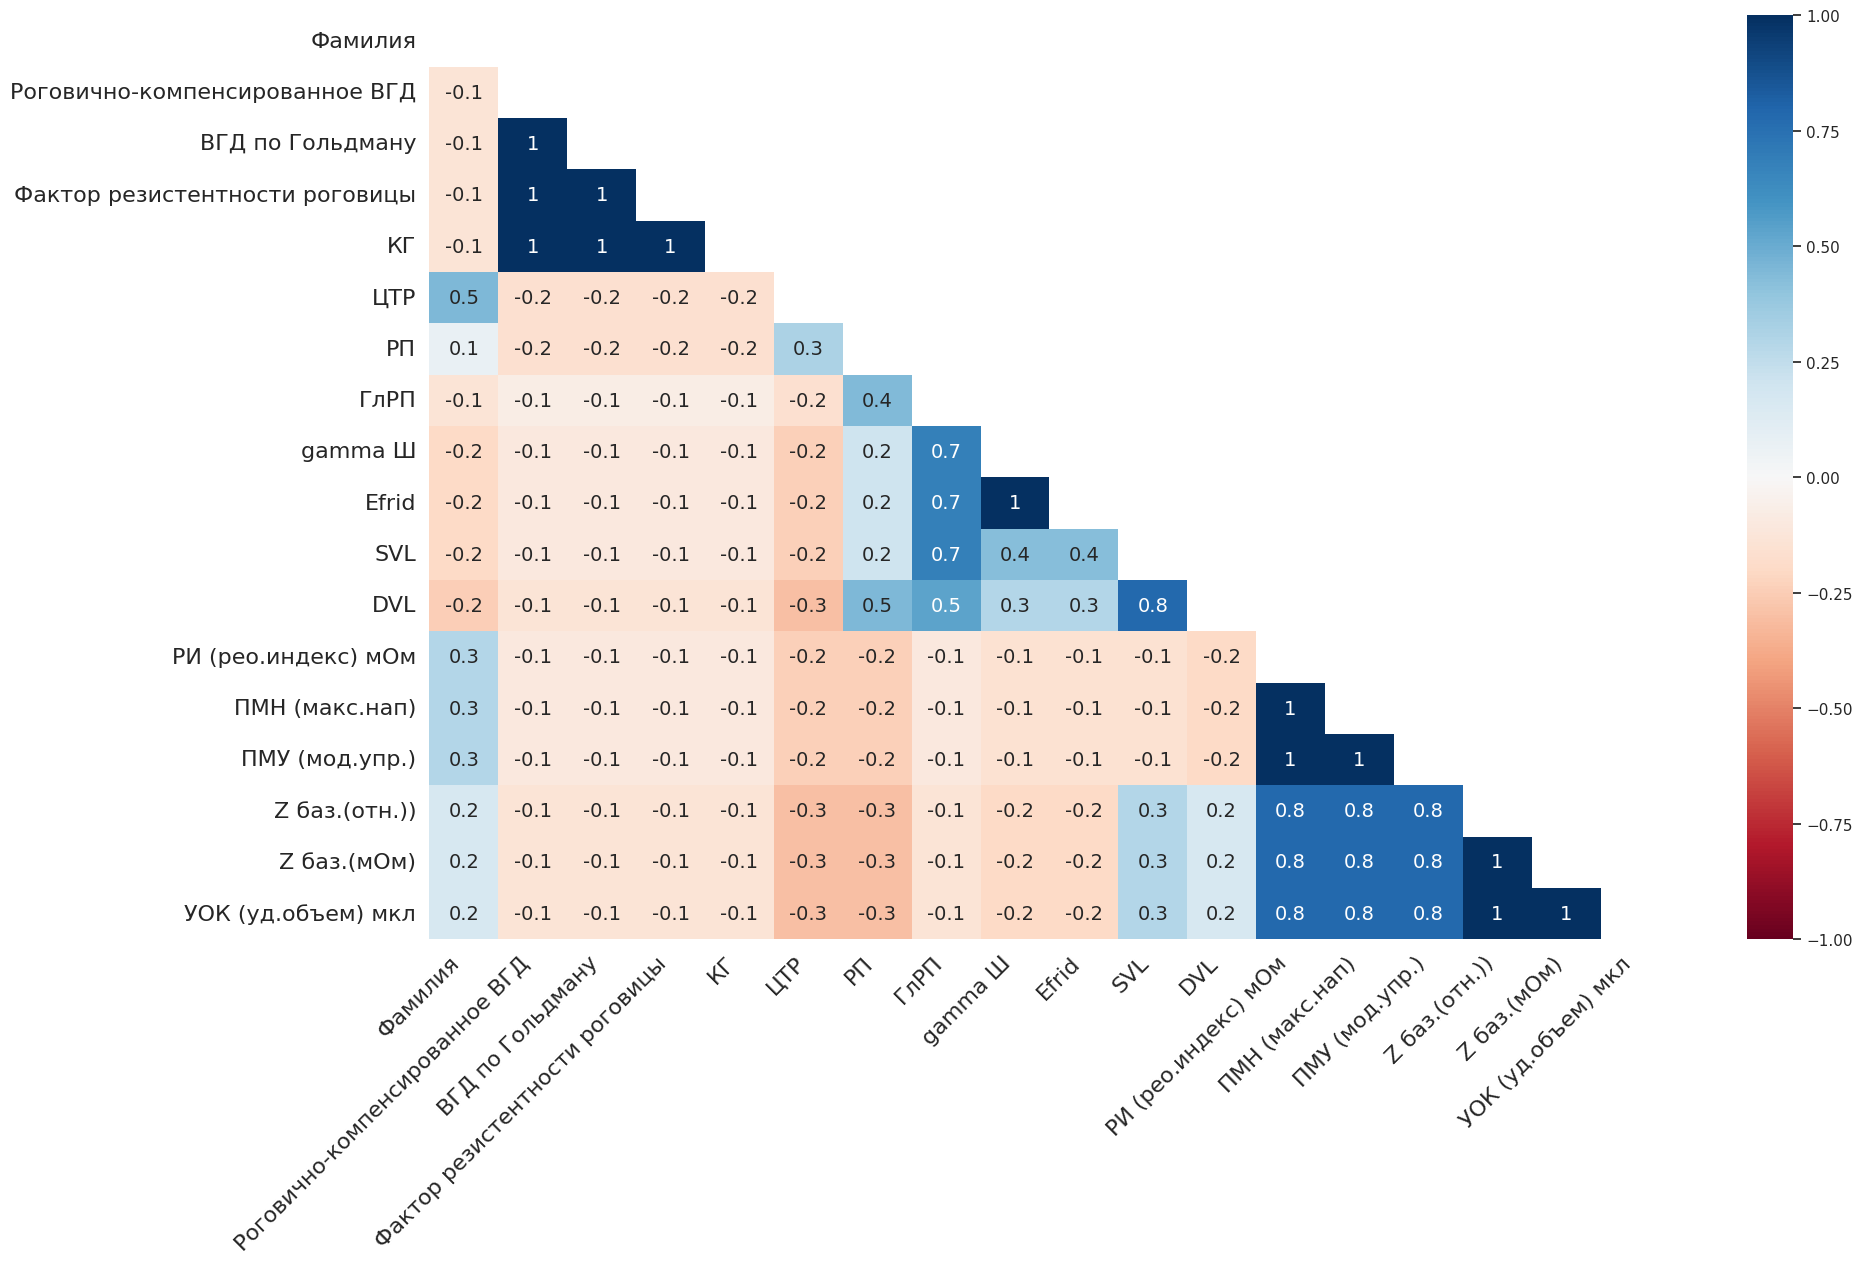

In [ ]:
msno.heatmap(data_1_stage);

### Заполняем пропуски в категориальных признаках



---


Фамилия - категориальный признак. Заполним значением по умолчанию, например, "Иванов"

In [ ]:
data_1_stage['Фамилия']=data_1_stage['Фамилия'].fillna('Иванов')
data_1_stage.isnull().sum()

,0
Фамилия,0
возраст,0
стадия,0
величина внутриглазного давления,0
"ВГД, корригированного на коэффициент ригидности",0
Коэфф ригидности склеральн капсулы глаза,0
Роговично-компенсированное ВГД,1
ВГД по Гольдману,1
Фактор резистентности роговицы,1
КГ,1


### Заполняем пропуски в количественных признаках



---

Остальные пропущенные значения принадлежат количественным признакам.

Можно заменить медианой.

In [ ]:
# скопируем датафрейм
median_imputer = data_1_stage.copy()

In [ ]:
#Посмотрим на среднее арифметическое и медиану.
print('Роговично-компенсированное ВГД - ', median_imputer['Роговично-компенсированное ВГД'].mean().round(1), '  ', median_imputer['Роговично-компенсированное ВГД'].median())
print('ВГД по Гольдману - ', median_imputer['ВГД по Гольдману'].mean().round(1), '  ', median_imputer['ВГД по Гольдману'].median())
print('Фактор резистентности роговицы - ', median_imputer['Фактор резистентности роговицы'].mean().round(1), '  ', median_imputer['Фактор резистентности роговицы'].median())
print('КГ - ', median_imputer['КГ'].mean().round(1), '  ', median_imputer['КГ'].median())
print('ЦТР - ', median_imputer['ЦТР'].mean().round(1), '  ', median_imputer['ЦТР'].median())
print('РП - ', median_imputer['РП'].mean().round(1), '  ', median_imputer['РП'].median())
print('ГлРП - ', median_imputer['ГлРП'].mean().round(1), '  ', median_imputer['ГлРП'].median())
print('gamma Ш - ', median_imputer['gamma Ш'].mean().round(1), '  ', median_imputer['gamma Ш'].median())
print('Efrid - ', median_imputer['Efrid'].mean().round(1), '  ', median_imputer['Efrid'].median())
print('SVL - ', median_imputer['SVL'].mean().round(1), '  ', median_imputer['SVL'].median())
print('DVL - ', median_imputer['DVL'].mean().round(1), '  ', median_imputer['DVL'].median())
print('РИ (рео.индекс) мОм - ', median_imputer['РИ (рео.индекс) мОм'].mean().round(1), '  ', median_imputer['РИ (рео.индекс) мОм'].median())
print('ПМН (макс.нап) - ', median_imputer['ПМН (макс.нап)'].mean().round(1), '  ', median_imputer['ПМН (макс.нап)'].median())
print('ПМУ (мод.упр.) - ', median_imputer['ПМУ (мод.упр.)'].mean().round(1), '  ', median_imputer['ПМУ (мод.упр.)'].median())
print('Z баз.(отн.)) - ', median_imputer['Z баз.(отн.))'].mean().round(1), '  ', median_imputer['Z баз.(отн.))'].median())
print('Z баз.(мОм) - ', median_imputer['Z баз.(мОм)'].mean().round(1), '  ', median_imputer['Z баз.(мОм)'].median())
print('УОК (уд.объем) мкл - ', median_imputer['УОК (уд.объем) мкл'].mean().round(1), '  ', median_imputer['УОК (уд.объем) мкл'].median())



Роговично-компенсированное ВГД -  19.0    19.35
ВГД по Гольдману -  17.7    17.15
Фактор резистентности роговицы -  10.2    9.95
КГ -  9.4    9.3
ЦТР -  550.8    562.0
РП -  205.5    205.0
ГлРП -  432.6    437.5
gamma Ш -  1.5    1.8
Efrid -  0.0    0.0147
SVL -  50.2    50.5
DVL -  41.6    42.04
РИ (рео.индекс) мОм -  53.1    58.89
ПМН (макс.нап) -  0.2    0.23
ПМУ (мод.упр.) -  0.3    0.26
Z баз.(отн.)) -  922.3    956.0
Z баз.(мОм) -  36.9    38.24
УОК (уд.объем) мкл -  1.5    1.3537174676972055


In [ ]:
# создадим объект класса SimpleImputer с параметром strategy = 'median'
imp_median = SimpleImputer(strategy = 'median')

# применим метод .fit_transform() для одновременного обучения модели и заполнения пропусков
median_imputer['Роговично-компенсированное ВГД'] = imp_median.fit_transform(median_imputer[['Роговично-компенсированное ВГД']])
median_imputer['ВГД по Гольдману'] = imp_median.fit_transform(median_imputer[['ВГД по Гольдману']])
median_imputer['Фактор резистентности роговицы'] = imp_median.fit_transform(median_imputer[['Фактор резистентности роговицы']])
median_imputer['КГ'] = imp_median.fit_transform(median_imputer[['КГ']])
median_imputer['ЦТР'] = imp_median.fit_transform(median_imputer[['ЦТР']])
median_imputer['РП'] = imp_median.fit_transform(median_imputer[['РП']])
median_imputer['ГлРП'] = imp_median.fit_transform(median_imputer[['ГлРП']])
median_imputer['gamma Ш'] = imp_median.fit_transform(median_imputer[['gamma Ш']])
median_imputer['Efrid'] = imp_median.fit_transform(median_imputer[['Efrid']])
median_imputer['SVL'] = imp_median.fit_transform(median_imputer[['SVL']])
median_imputer['DVL'] = imp_median.fit_transform(median_imputer[['DVL']])
median_imputer['РИ (рео.индекс) мОм'] = imp_median.fit_transform(median_imputer[['РИ (рео.индекс) мОм']])
median_imputer['ПМН (макс.нап)'] = imp_median.fit_transform(median_imputer[['ПМН (макс.нап)']])
median_imputer['ПМУ (мод.упр.)'] = imp_median.fit_transform(median_imputer[['ПМУ (мод.упр.)']])
median_imputer['Z баз.(отн.))'] = imp_median.fit_transform(median_imputer[['Z баз.(отн.))']])
median_imputer['Z баз.(мОм)'] = imp_median.fit_transform(median_imputer[['Z баз.(мОм)']])
median_imputer['УОК (уд.объем) мкл'] = imp_median.fit_transform(median_imputer[['УОК (уд.объем) мкл']])

# убедимся, что пропущенных значений не осталось
median_imputer['УОК (уд.объем) мкл'].isna().sum()

np.int64(0)

In [ ]:
# посмотрим на метрики после заполнения медианой
print('Роговично-компенсированное ВГД - ', median_imputer['Роговично-компенсированное ВГД'].mean().round(1), '  ', median_imputer['Роговично-компенсированное ВГД'].median())
print('ВГД по Гольдману - ', median_imputer['ВГД по Гольдману'].mean().round(1), '  ', median_imputer['ВГД по Гольдману'].median())
print('Фактор резистентности роговицы - ', median_imputer['Фактор резистентности роговицы'].mean().round(1), '  ', median_imputer['Фактор резистентности роговицы'].median())
print('КГ - ', median_imputer['КГ'].mean().round(1), '  ', median_imputer['КГ'].median())
print('ЦТР - ', median_imputer['ЦТР'].mean().round(1), '  ', median_imputer['ЦТР'].median())
print('РП - ', median_imputer['РП'].mean().round(1), '  ', median_imputer['РП'].median())
print('ГлРП - ', median_imputer['ГлРП'].mean().round(1), '  ', median_imputer['ГлРП'].median())
print('gamma Ш - ', median_imputer['gamma Ш'].mean().round(1), '  ', median_imputer['gamma Ш'].median())
print('Efrid - ', median_imputer['Efrid'].mean().round(1), '  ', median_imputer['Efrid'].median())
print('SVL - ', median_imputer['SVL'].mean().round(1), '  ', median_imputer['SVL'].median())
print('DVL - ', median_imputer['DVL'].mean().round(1), '  ', median_imputer['DVL'].median())
print('РИ (рео.индекс) мОм - ', median_imputer['РИ (рео.индекс) мОм'].mean().round(1), '  ', median_imputer['РИ (рео.индекс) мОм'].median())
print('ПМН (макс.нап) - ', median_imputer['ПМН (макс.нап)'].mean().round(1), '  ', median_imputer['ПМН (макс.нап)'].median())
print('ПМУ (мод.упр.) - ', median_imputer['ПМУ (мод.упр.)'].mean().round(1), '  ', median_imputer['ПМУ (мод.упр.)'].median())
print('Z баз.(отн.)) - ', median_imputer['Z баз.(отн.))'].mean().round(1), '  ', median_imputer['Z баз.(отн.))'].median())
print('Z баз.(мОм) - ', median_imputer['Z баз.(мОм)'].mean().round(1), '  ', median_imputer['Z баз.(мОм)'].median())
print('УОК (уд.объем) мкл - ', median_imputer['УОК (уд.объем) мкл'].mean().round(1), '  ', median_imputer['УОК (уд.объем) мкл'].median())



Роговично-компенсированное ВГД -  19.0    19.35
ВГД по Гольдману -  17.7    17.15
Фактор резистентности роговицы -  10.2    9.95
КГ -  9.4    9.3
ЦТР -  553.8    562.0
РП -  205.3    205.0
ГлРП -  432.9    437.5
gamma Ш -  1.6    1.8
Efrid -  0.0    0.0147
SVL -  50.3    50.5
DVL -  41.7    42.04
РИ (рео.индекс) мОм -  53.9    58.89
ПМН (макс.нап) -  0.2    0.23
ПМУ (мод.упр.) -  0.3    0.26
Z баз.(отн.)) -  929.1    956.0
Z баз.(мОм) -  37.2    38.24
УОК (уд.объем) мкл -  1.5    1.3537174676972055


Проверяем, что заполнили все пропуски.

In [ ]:
median_imputer.isnull().sum()

,0
Фамилия,0
возраст,0
стадия,0
величина внутриглазного давления,0
"ВГД, корригированного на коэффициент ригидности",0
Коэфф ригидности склеральн капсулы глаза,0
Роговично-компенсированное ВГД,0
ВГД по Гольдману,0
Фактор резистентности роговицы,0
КГ,0


### Сравниваем взаимосвязь признаков до и после заполнения пропусков

In [ ]:
corr_matrix_before=data_1_stage.iloc [:, 1:11].corr().round(3)

<Axes: >

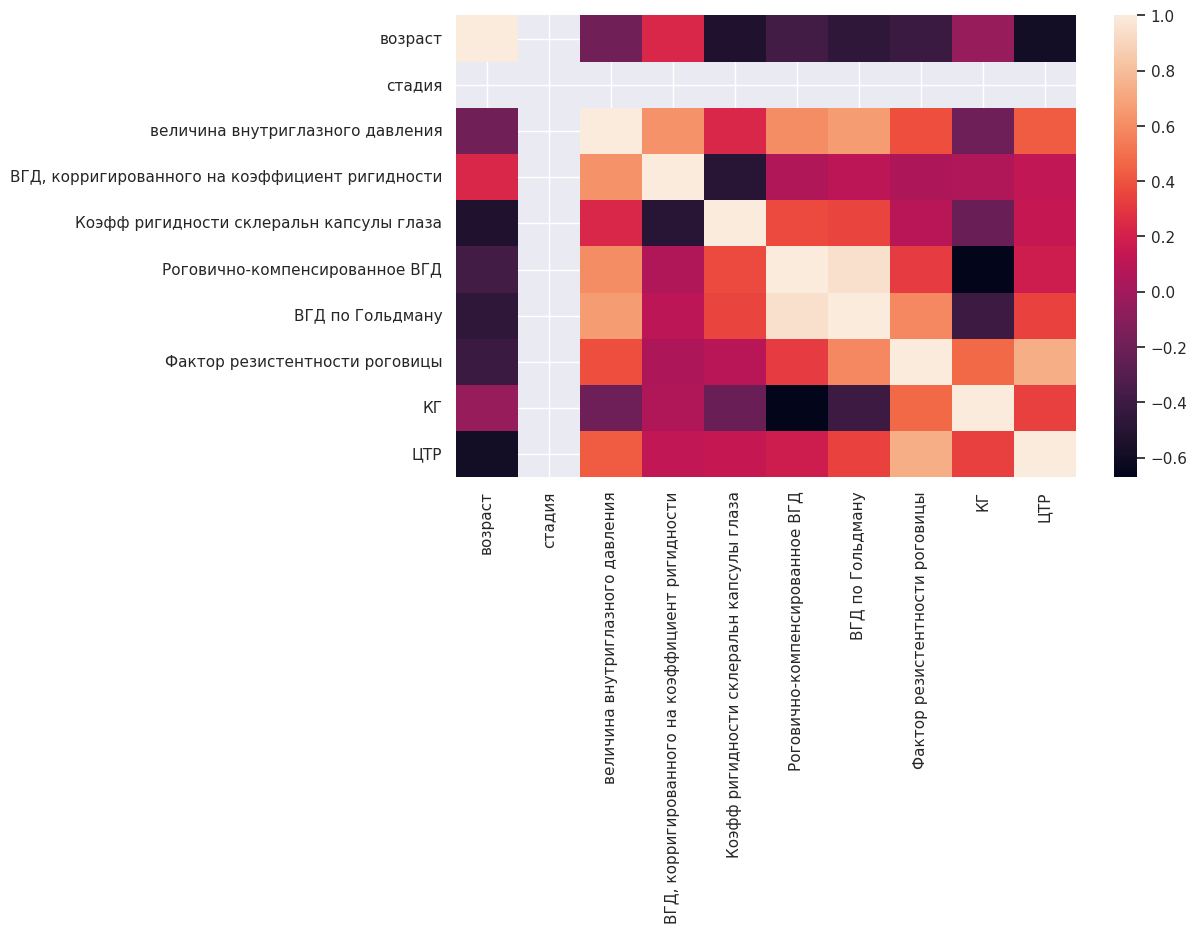

In [ ]:
sns.heatmap(corr_matrix_before)

In [ ]:
corr_matrix_after=median_imputer.iloc [:, 1:11].corr().round(3)

<Axes: >

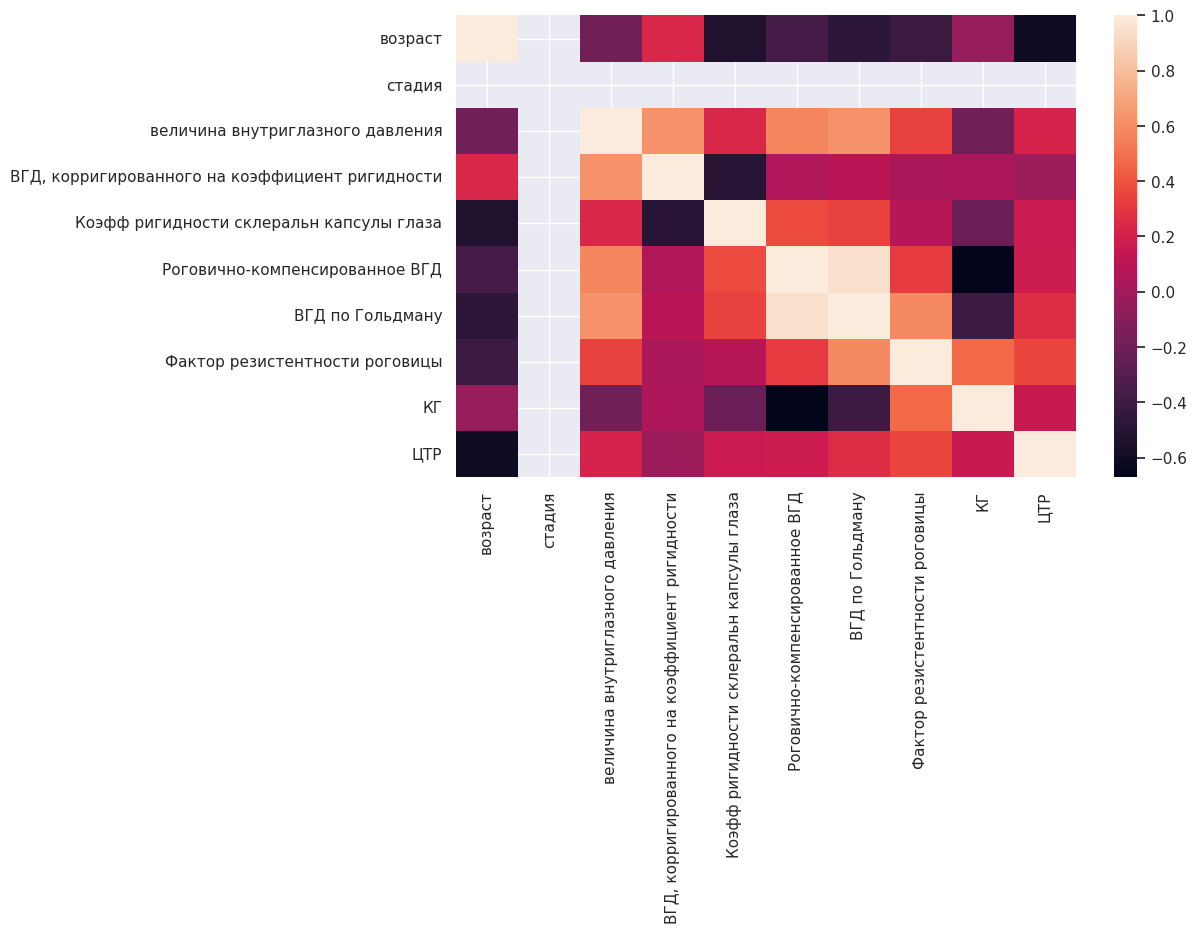

In [ ]:
sns.heatmap(corr_matrix_after)

In [ ]:
changes_in_corr=corr_matrix_before-corr_matrix_after

In [ ]:
changes_in_corr

,возраст,стадия,величина внутриглазного давления,"ВГД, корригированного на коэффициент ригидности",Коэфф ригидности склеральн капсулы глаза,Роговично-компенсированное ВГД,ВГД по Гольдману,Фактор резистентности роговицы,КГ,ЦТР
возраст,0.000,NaN,0.000,0.000,0.000,-0.001,0.001,0.002,0.001,0.020
стадия,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
величина внутриглазного давления,0.000,NaN,0.000,0.000,0.000,0.020,0.041,0.034,-0.005,0.217
"ВГД, корригированного на коэффициент ригидности",0.000,NaN,0.000,0.000,0.000,-0.003,0.007,0.009,0.003,0.146
Коэфф ригидности склеральн капсулы глаза,0.000,NaN,0.000,0.000,0.000,0.000,0.005,0.005,0.000,-0.019
Роговично-компенсированное ВГД,-0.001,NaN,0.020,-0.003,0.000,0.000,0.001,0.002,0.000,0.008
ВГД по Гольдману,0.001,NaN,0.041,0.007,0.005,0.001,0.000,-0.001,0.000,0.085
Фактор резистентности роговицы,0.002,NaN,0.034,0.009,0.005,0.002,-0.001,0.000,0.000,0.378
КГ,0.001,NaN,-0.005,0.003,0.000,0.000,0.000,0.000,0.000,0.181
ЦТР,0.020,NaN,0.217,0.146,-0.019,0.008,0.085,0.378,0.181,0.000


<Axes: >

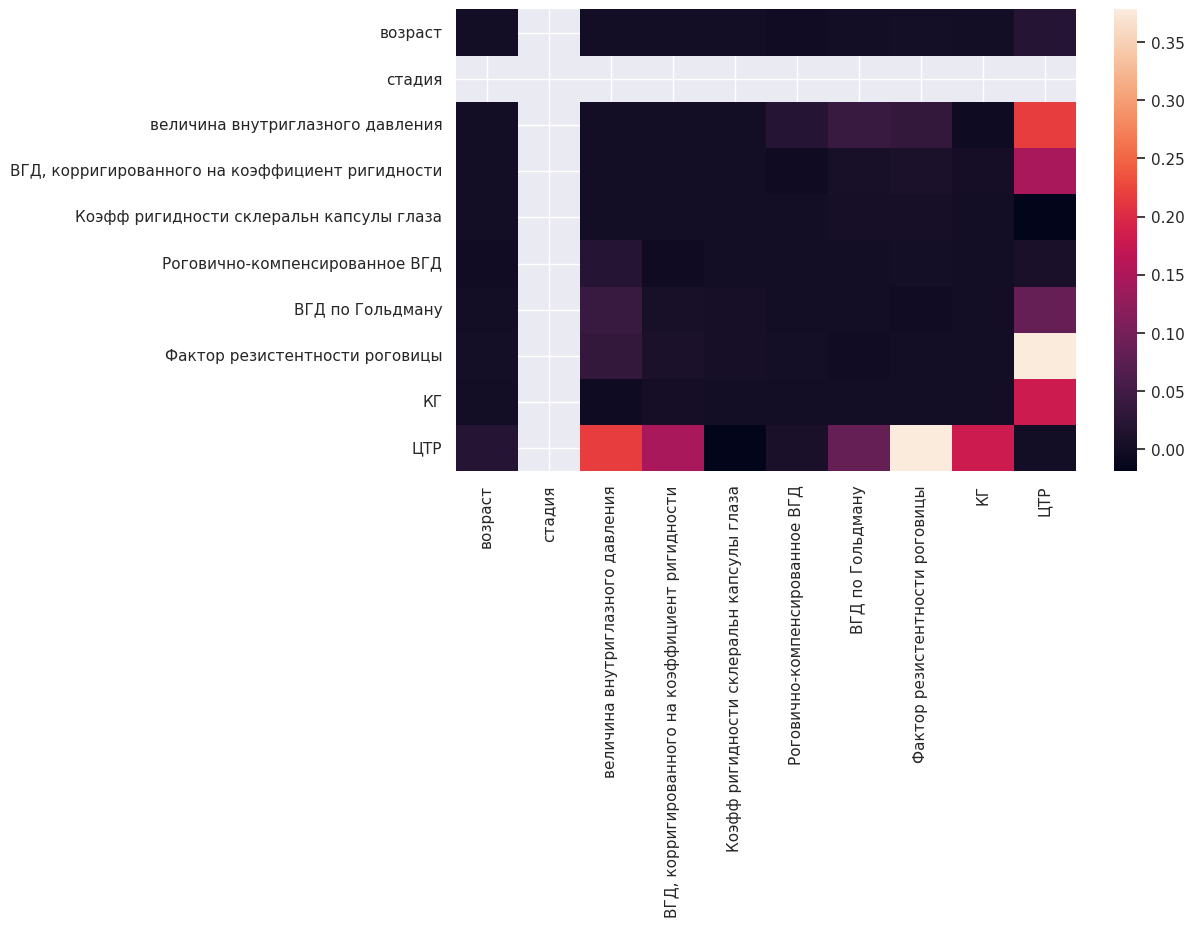

In [ ]:
sns.heatmap(changes_in_corr)

In [ ]:
data_1_stage=median_imputer

## Работа с пропущенными значениями в таблице с пациентами **2 стадии заболевания**

In [ ]:
data_2_stage

,Фамилия,возраст,стадия,величина внутриглазного давления,"ВГД, корригированного на коэффициент ригидности",Коэфф ригидности склеральн капсулы глаза,Роговично-компенсированное ВГД,ВГД по Гольдману,Фактор резистентности роговицы,КГ,...,gamma Ш,Efrid,SVL,DVL,РИ (рео.индекс) мОм,ПМН (макс.нап),ПМУ (мод.упр.),Z баз.(отн.)),Z баз.(мОм),УОК (уд.объем) мкл
0,горнева,84,2,13,17,0.0132,16.2,14.1,8.8,9.0,...,1.65,0.0132,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,64,2,19,24,0.0127,15.7,15.7,10.0,10.0,...,1.65,0.0127,44.11,32.11,NaN,NaN,NaN,NaN,NaN,NaN
2,близнюк,70,2,11,11,0.0214,19.8,18.0,9.9,8.9,...,2.40,0.0343,51.47,47.28,43.37,0.11,0.26,960.0,38.40,1.031167
3,NaN,68,2,11,12,0.0190,17.1,14.0,8.1,8.2,...,0.70,0.0190,50.96,41.77,33.20,0.71,0.75,925.0,37.00,0.819232
4,митина,80,2,17,21,0.0146,23.5,21.0,9.9,7.9,...,1.75,0.0146,44.14,29.78,27.39,0.16,0.19,1080.0,43.20,0.578867
5,якубова,71,2,15,20,0.0133,26.5,25.7,12.1,8.8,...,1.70,0.0133,47.36,36.07,NaN,NaN,NaN,NaN,NaN,NaN
6,емельянова,77,2,16,17,0.0199,20.2,18.0,9.6,8.6,...,2.00,0.0199,NaN,NaN,29.34,0.26,0.28,911.0,36.44,0.735110
7,Мациева,68,2,17,12,0.0325,22.6,19.4,9.0,7.4,...,2.30,0.0325,NaN,NaN,44.28,0.08,0.09,878.0,35.12,1.151129
8,Попова,80,2,14,14,0.0204,24.3,19.9,8.1,6.1,...,NaN,0.0204,49.31,NaN,11.36,0.12,0.27,766.0,30.64,0.338501
9,NaN,72,2,18,25,0.0092,20.7,19.6,10.7,9.3,...,1.45,0.0092,NaN,NaN,58.26,0.18,0.23,947.0,37.88,1.404207


In [ ]:
#посмотрим сколько пропущенных значений в данных
data_2_stage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 23 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Фамилия                                          10 non-null     object 
 1   возраст                                          15 non-null     int64  
 2   стадия                                           15 non-null     int64  
 3   величина внутриглазного давления                 15 non-null     int64  
 4   ВГД, корригированного на коэффициент ригидности  15 non-null     int64  
 5   Коэфф ригидности склеральн капсулы глаза         15 non-null     float64
 6   Роговично-компенсированное ВГД                   15 non-null     float64
 7   ВГД по Гольдману                                 15 non-null     float64
 8   Фактор резистентности роговицы                   15 non-null     float64
 9   КГ                                

In [ ]:
data_2_stage.isnull().sum()

,0
Фамилия,5
возраст,0
стадия,0
величина внутриглазного давления,0
"ВГД, корригированного на коэффициент ригидности",0
Коэфф ригидности склеральн капсулы глаза,0
Роговично-компенсированное ВГД,0
ВГД по Гольдману,0
Фактор резистентности роговицы,0
КГ,0


Рассчитаем процент пропусков

In [ ]:
(data_2_stage.isna().sum() / len(data_2_stage)).round(4) * 100

,0
Фамилия,33.33
возраст,0.00
стадия,0.00
величина внутриглазного давления,0.00
"ВГД, корригированного на коэффициент ригидности",0.00
Коэфф ригидности склеральн капсулы глаза,0.00
Роговично-компенсированное ВГД,0.00
ВГД по Гольдману,0.00
Фактор резистентности роговицы,0.00
КГ,0.00


Вывод: пропуски есть по 13 признакам из 23, процент пропущенных данных в основном около 20%. На основе этого становится понятно, что удалять данные с пропущенными значениями - неподходящий способ в данной ситуации.

<Axes: >

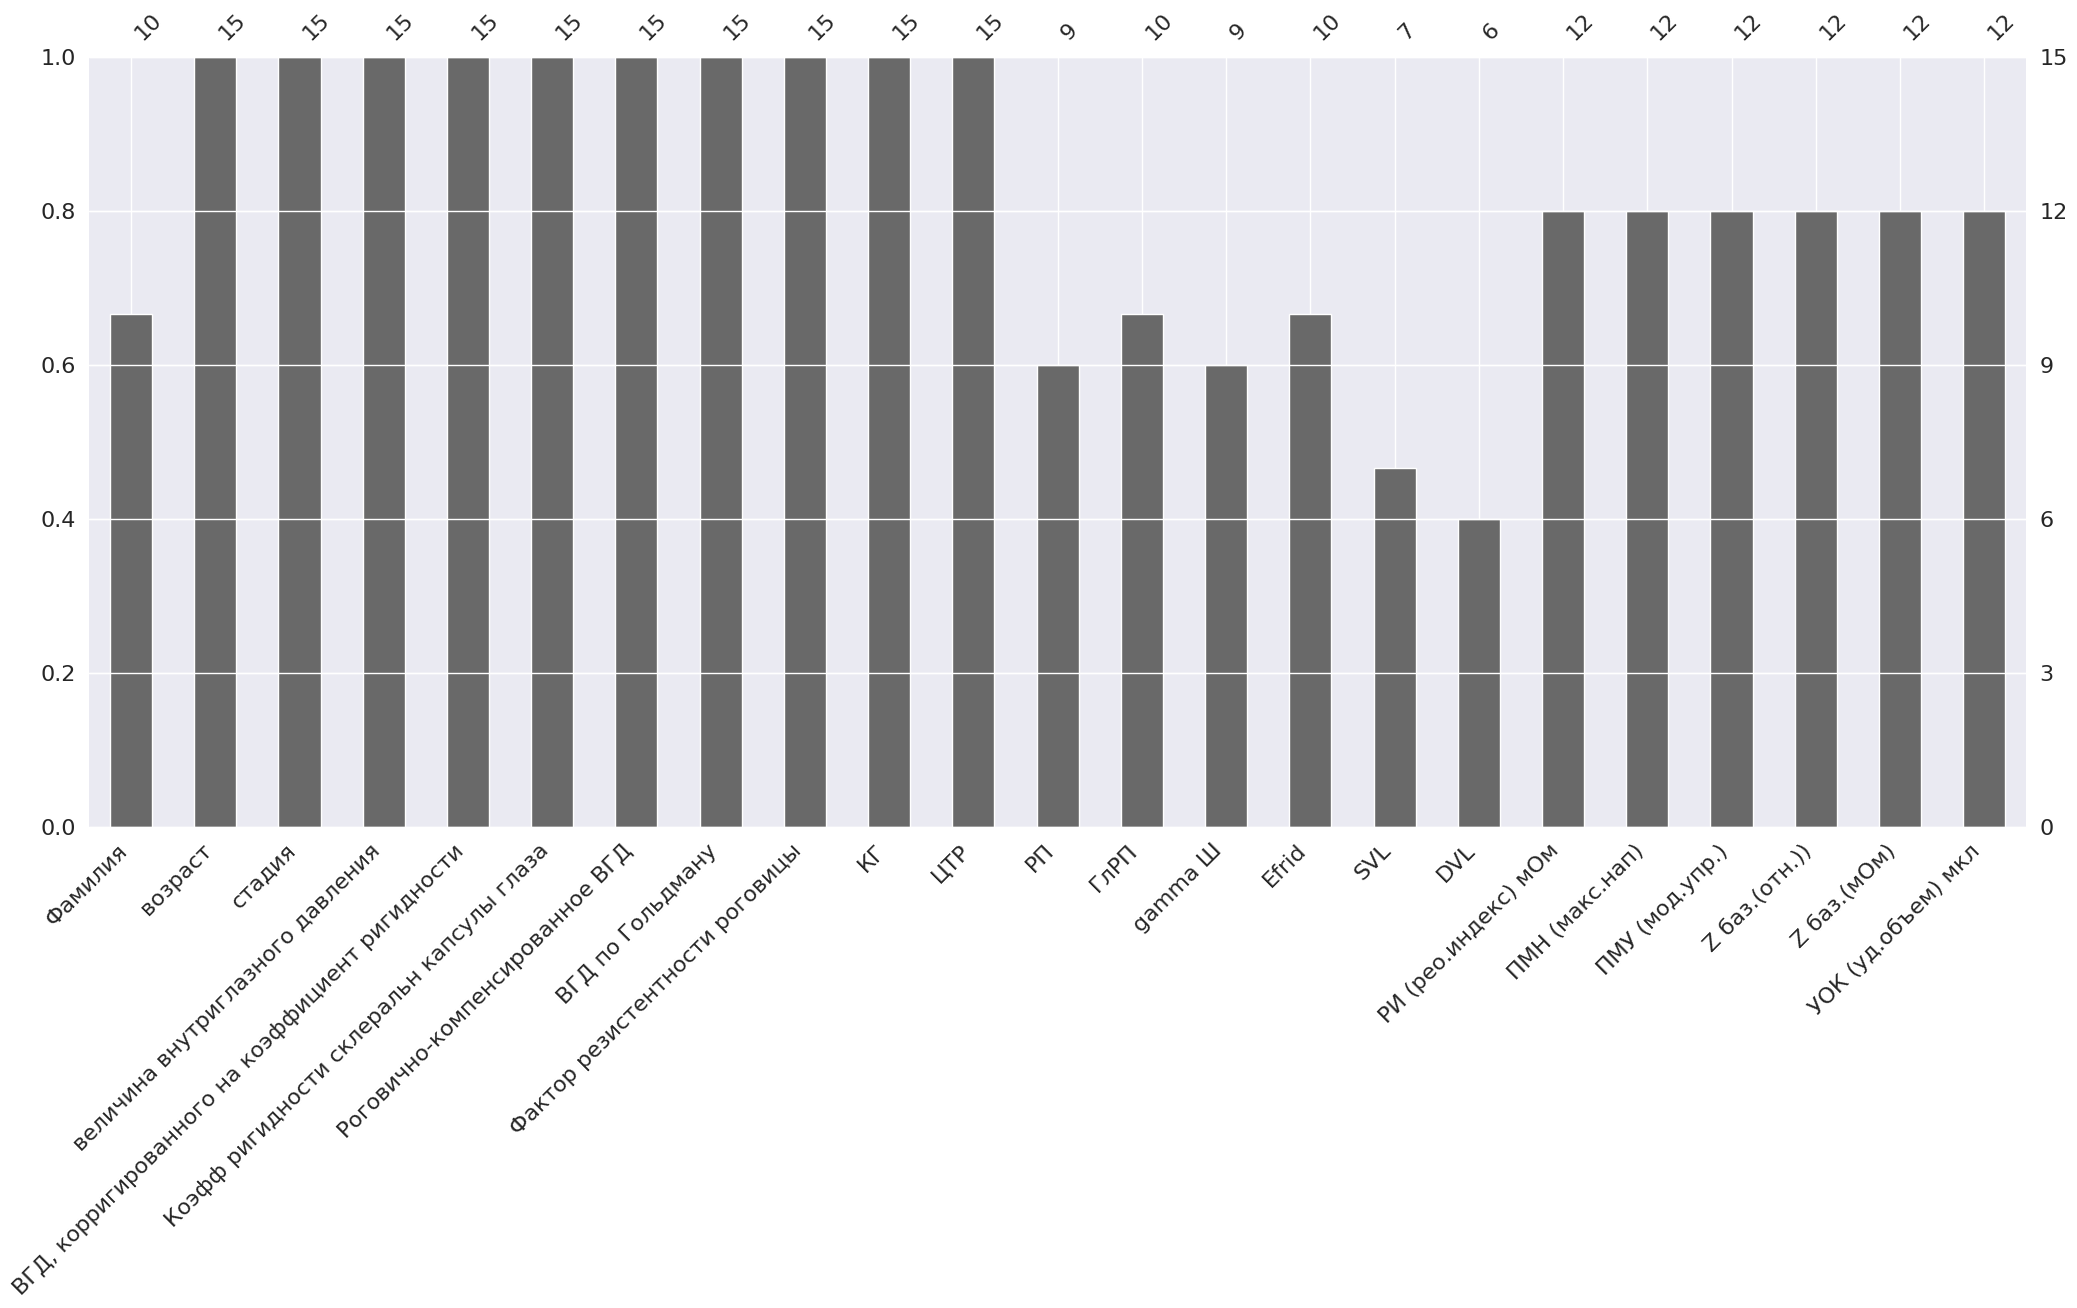

In [ ]:
msno.bar(data_2_stage)

<Axes: >

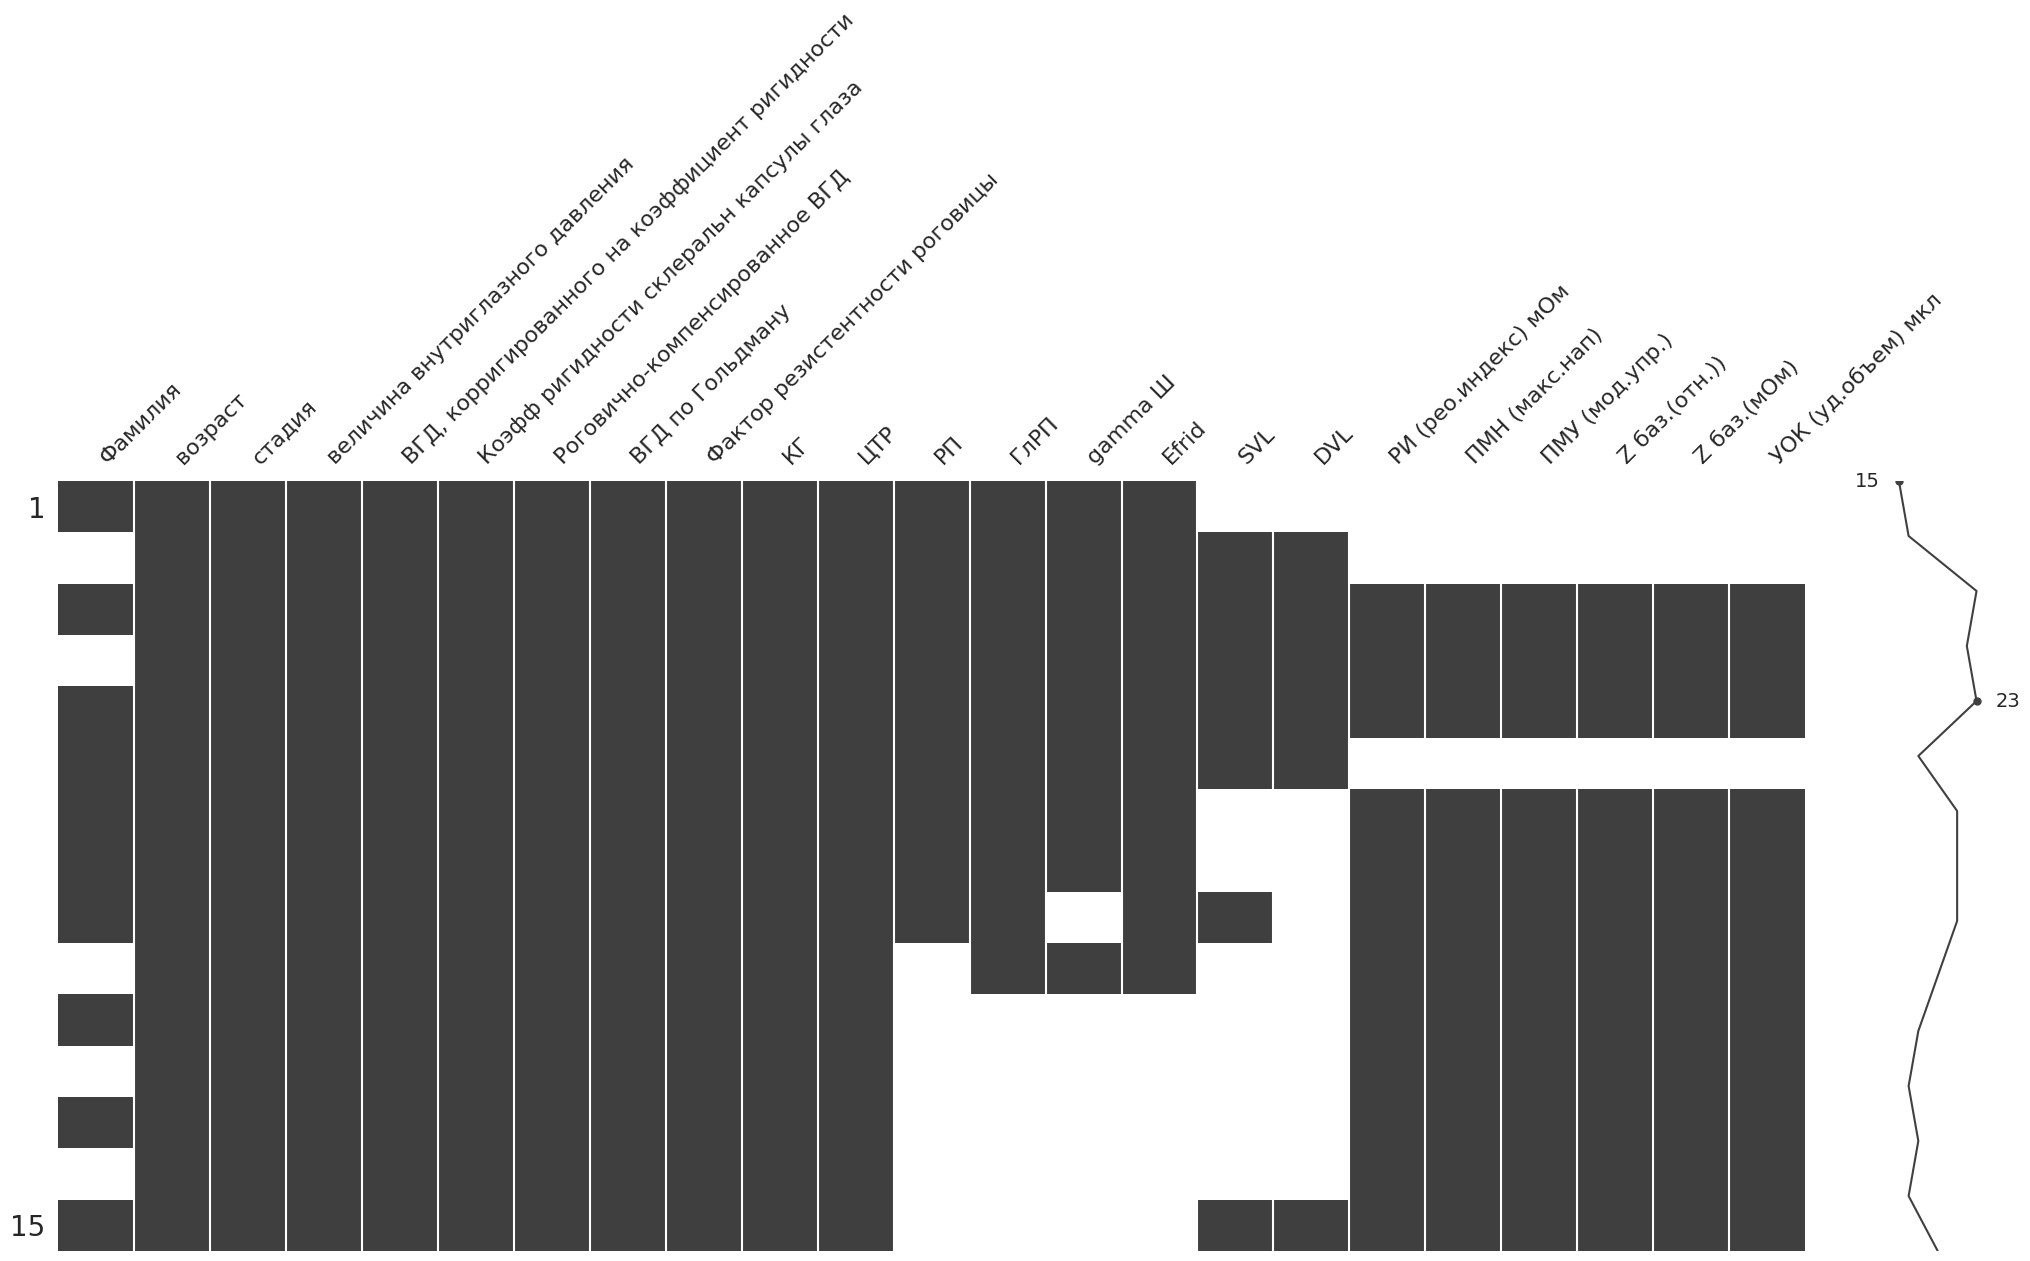

In [ ]:
#матрица пропущенных значений
msno.matrix(data_2_stage)

Выяснили, что пропуски носят случайный характер. Приступаем к их заполнению.

Построим **матрицу корреляции пропущенных значений** (nullity correlation matrix).

In [ ]:
tmp_df = data_2_stage.iloc[:, [i for i, n in enumerate(np.var(data_2_stage.isnull(), axis = 'rows')) if n > 0]]
tmp_df.isnull().corr()

,Фамилия,РП,ГлРП,gamma Ш,Efrid,SVL,DVL,РИ (рео.индекс) мОм,ПМН (макс.нап),ПМУ (мод.упр.),Z баз.(отн.)),Z баз.(мОм),УОК (уд.объем) мкл
Фамилия,1.000000e+00,0.288675,0.100000,-5.608641e-17,0.100000,0.094491,-8.012345e-17,7.850462e-17,7.850462e-17,7.850462e-17,7.850462e-17,7.850462e-17,7.850462e-17
РП,2.886751e-01,1.000000,0.866025,7.222222e-01,0.866025,0.490990,3.888889e-01,-4.082483e-01,-4.082483e-01,-4.082483e-01,-4.082483e-01,-4.082483e-01,-4.082483e-01
ГлРП,1.000000e-01,0.866025,1.000000,8.660254e-01,1.000000,0.377964,2.886751e-01,-3.535534e-01,-3.535534e-01,-3.535534e-01,-3.535534e-01,-3.535534e-01,-3.535534e-01
gamma Ш,-5.608641e-17,0.722222,0.866025,1.000000e+00,0.866025,0.218218,3.888889e-01,-4.082483e-01,-4.082483e-01,-4.082483e-01,-4.082483e-01,-4.082483e-01,-4.082483e-01
Efrid,1.000000e-01,0.866025,1.000000,8.660254e-01,1.000000,0.377964,2.886751e-01,-3.535534e-01,-3.535534e-01,-3.535534e-01,-3.535534e-01,-3.535534e-01,-3.535534e-01
SVL,9.449112e-02,0.490990,0.377964,2.182179e-01,0.377964,1.000000,8.728716e-01,-2.004459e-01,-2.004459e-01,-2.004459e-01,-2.004459e-01,-2.004459e-01,-2.004459e-01
DVL,-8.012345e-17,0.388889,0.288675,3.888889e-01,0.288675,0.872872,1.000000e+00,-2.721655e-01,-2.721655e-01,-2.721655e-01,-2.721655e-01,-2.721655e-01,-2.721655e-01
РИ (рео.индекс) мОм,7.850462e-17,-0.408248,-0.353553,-4.082483e-01,-0.353553,-0.200446,-2.721655e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
ПМН (макс.нап),7.850462e-17,-0.408248,-0.353553,-4.082483e-01,-0.353553,-0.200446,-2.721655e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
ПМУ (мод.упр.),7.850462e-17,-0.408248,-0.353553,-4.082483e-01,-0.353553,-0.200446,-2.721655e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


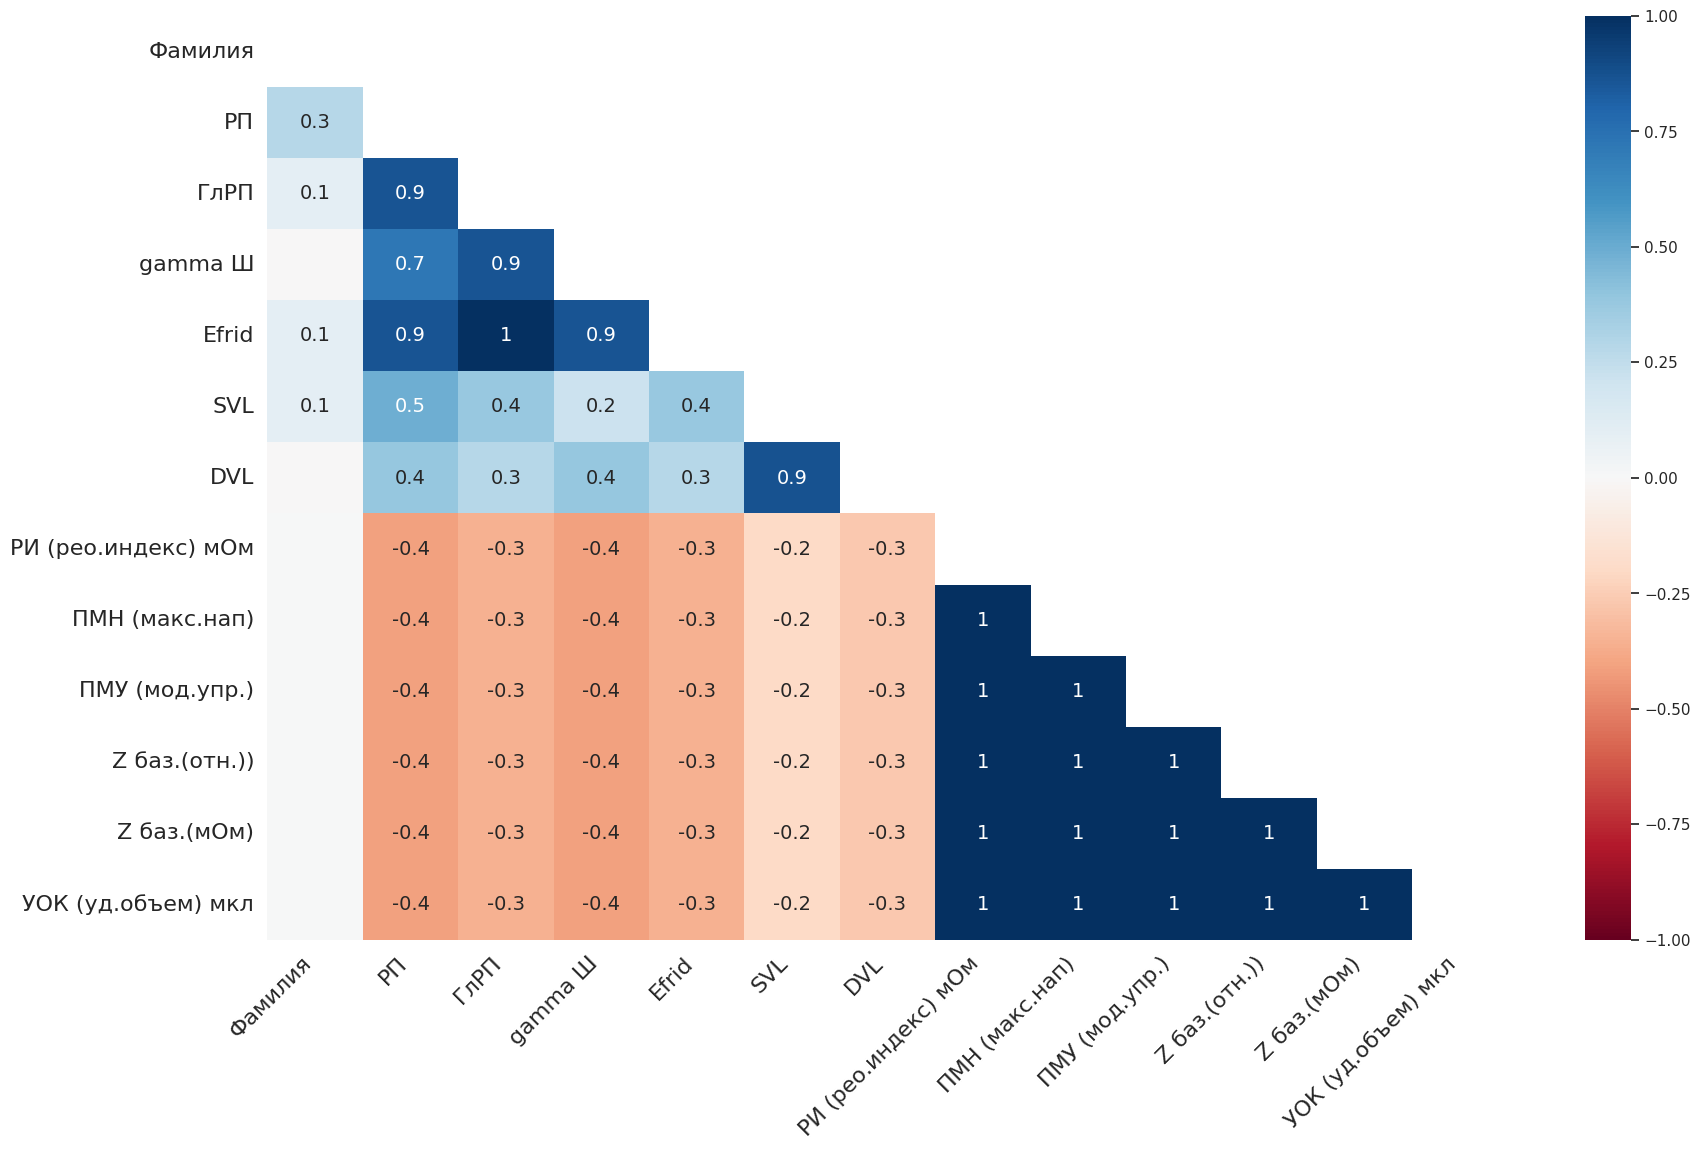

In [ ]:
msno.heatmap(data_2_stage);

### Заполняем пропуски в категориальных признаках



---


Фамилия - категориальный признак. Заполним значением по умолчанию, например, "Иванов"

In [ ]:
data_2_stage['Фамилия']=data_2_stage['Фамилия'].fillna('Иванов')
data_2_stage.isnull().sum()

,0
Фамилия,0
возраст,0
стадия,0
величина внутриглазного давления,0
"ВГД, корригированного на коэффициент ригидности",0
Коэфф ригидности склеральн капсулы глаза,0
Роговично-компенсированное ВГД,0
ВГД по Гольдману,0
Фактор резистентности роговицы,0
КГ,0


### Заполняем пропуски в количественных признаках



---

Остальные пропущенные значения принадлежат количественным признакам.

Можно заменить медианой.

In [ ]:
# скопируем датафрейм
median_imputer = data_2_stage.copy()

In [ ]:
#Посмотрим на среднее арифметическое и медиану.
print('РП - ', median_imputer['РП'].mean().round(1), '  ', median_imputer['РП'].median())
print('ГлРП - ', median_imputer['ГлРП'].mean().round(1), '  ', median_imputer['ГлРП'].median())
print('gamma Ш - ', median_imputer['gamma Ш'].mean().round(1), '  ', median_imputer['gamma Ш'].median())
print('Efrid - ', median_imputer['Efrid'].mean().round(1), '  ', median_imputer['Efrid'].median())
print('SVL - ', median_imputer['SVL'].mean().round(1), '  ', median_imputer['SVL'].median())
print('DVL - ', median_imputer['DVL'].mean().round(1), '  ', median_imputer['DVL'].median())
print('РИ (рео.индекс) мОм - ', median_imputer['РИ (рео.индекс) мОм'].mean().round(1), '  ', median_imputer['РИ (рео.индекс) мОм'].median())
print('ПМН (макс.нап) - ', median_imputer['ПМН (макс.нап)'].mean().round(1), '  ', median_imputer['ПМН (макс.нап)'].median())
print('ПМУ (мод.упр.) - ', median_imputer['ПМУ (мод.упр.)'].mean().round(1), '  ', median_imputer['ПМУ (мод.упр.)'].median())
print('Z баз.(отн.)) - ', median_imputer['Z баз.(отн.))'].mean().round(1), '  ', median_imputer['Z баз.(отн.))'].median())
print('Z баз.(мОм) - ', median_imputer['Z баз.(мОм)'].mean().round(1), '  ', median_imputer['Z баз.(мОм)'].median())
print('УОК (уд.объем) мкл - ', median_imputer['УОК (уд.объем) мкл'].mean().round(1), '  ', median_imputer['УОК (уд.объем) мкл'].median())



РП -  201.9    195.0
ГлРП -  449.2    443.0
gamma Ш -  1.7    1.7
Efrid -  0.0    0.0168
SVL -  45.4    47.36
DVL -  37.3    36.519999999999996
РИ (рео.индекс) мОм -  42.4    38.285
ПМН (макс.нап) -  0.3    0.26
ПМУ (мод.упр.) -  0.3    0.275
Z баз.(отн.)) -  820.4    894.0
Z баз.(мОм) -  32.8    35.76
УОК (уд.объем) мкл -  1.4    1.017857176278794


In [ ]:
# создадим объект класса SimpleImputer с параметром strategy = 'median'
imp_median = SimpleImputer(strategy = 'median')

# применим метод .fit_transform() для одновременного обучения модели и заполнения пропусков
median_imputer['РП'] = imp_median.fit_transform(median_imputer[['РП']])
median_imputer['ГлРП'] = imp_median.fit_transform(median_imputer[['ГлРП']])
median_imputer['gamma Ш'] = imp_median.fit_transform(median_imputer[['gamma Ш']])
median_imputer['Efrid'] = imp_median.fit_transform(median_imputer[['Efrid']])
median_imputer['SVL'] = imp_median.fit_transform(median_imputer[['SVL']])
median_imputer['DVL'] = imp_median.fit_transform(median_imputer[['DVL']])
median_imputer['РИ (рео.индекс) мОм'] = imp_median.fit_transform(median_imputer[['РИ (рео.индекс) мОм']])
median_imputer['ПМН (макс.нап)'] = imp_median.fit_transform(median_imputer[['ПМН (макс.нап)']])
median_imputer['ПМУ (мод.упр.)'] = imp_median.fit_transform(median_imputer[['ПМУ (мод.упр.)']])
median_imputer['Z баз.(отн.))'] = imp_median.fit_transform(median_imputer[['Z баз.(отн.))']])
median_imputer['Z баз.(мОм)'] = imp_median.fit_transform(median_imputer[['Z баз.(мОм)']])
median_imputer['УОК (уд.объем) мкл'] = imp_median.fit_transform(median_imputer[['УОК (уд.объем) мкл']])

# убедимся, что пропущенных значений не осталось
median_imputer['УОК (уд.объем) мкл'].isna().sum()

np.int64(0)

In [ ]:
# посмотрим на метрики после заполнения медианой
print('РП - ', median_imputer['РП'].mean().round(1), '  ', median_imputer['РП'].median())
print('ГлРП - ', median_imputer['ГлРП'].mean().round(1), '  ', median_imputer['ГлРП'].median())
print('gamma Ш - ', median_imputer['gamma Ш'].mean().round(1), '  ', median_imputer['gamma Ш'].median())
print('Efrid - ', median_imputer['Efrid'].mean().round(1), '  ', median_imputer['Efrid'].median())
print('SVL - ', median_imputer['SVL'].mean().round(1), '  ', median_imputer['SVL'].median())
print('DVL - ', median_imputer['DVL'].mean().round(1), '  ', median_imputer['DVL'].median())
print('РИ (рео.индекс) мОм - ', median_imputer['РИ (рео.индекс) мОм'].mean().round(1), '  ', median_imputer['РИ (рео.индекс) мОм'].median())
print('ПМН (макс.нап) - ', median_imputer['ПМН (макс.нап)'].mean().round(1), '  ', median_imputer['ПМН (макс.нап)'].median())
print('ПМУ (мод.упр.) - ', median_imputer['ПМУ (мод.упр.)'].mean().round(1), '  ', median_imputer['ПМУ (мод.упр.)'].median())
print('Z баз.(отн.)) - ', median_imputer['Z баз.(отн.))'].mean().round(1), '  ', median_imputer['Z баз.(отн.))'].median())
print('Z баз.(мОм) - ', median_imputer['Z баз.(мОм)'].mean().round(1), '  ', median_imputer['Z баз.(мОм)'].median())
print('УОК (уд.объем) мкл - ', median_imputer['УОК (уд.объем) мкл'].mean().round(1), '  ', median_imputer['УОК (уд.объем) мкл'].median())



РП -  199.1    195.0
ГлРП -  447.1    443.0
gamma Ш -  1.7    1.7
Efrid -  0.0    0.0168
SVL -  46.4    47.36
DVL -  36.8    36.519999999999996
РИ (рео.индекс) мОм -  41.6    38.285
ПМН (макс.нап) -  0.3    0.26
ПМУ (мод.упр.) -  0.3    0.275
Z баз.(отн.)) -  835.1    894.0
Z баз.(мОм) -  33.4    35.76
УОК (уд.объем) мкл -  1.3    1.017857176278794


Проверяем, что заполнили все пропуски.

In [ ]:
median_imputer.isnull().sum()

,0
Фамилия,0
возраст,0
стадия,0
величина внутриглазного давления,0
"ВГД, корригированного на коэффициент ригидности",0
Коэфф ригидности склеральн капсулы глаза,0
Роговично-компенсированное ВГД,0
ВГД по Гольдману,0
Фактор резистентности роговицы,0
КГ,0


### Сравниваем взаимосвязь признаков до и после заполнения пропусков

In [ ]:
corr_matrix_before=data_2_stage.iloc [:, 1:11].corr().round(3)

<Axes: >

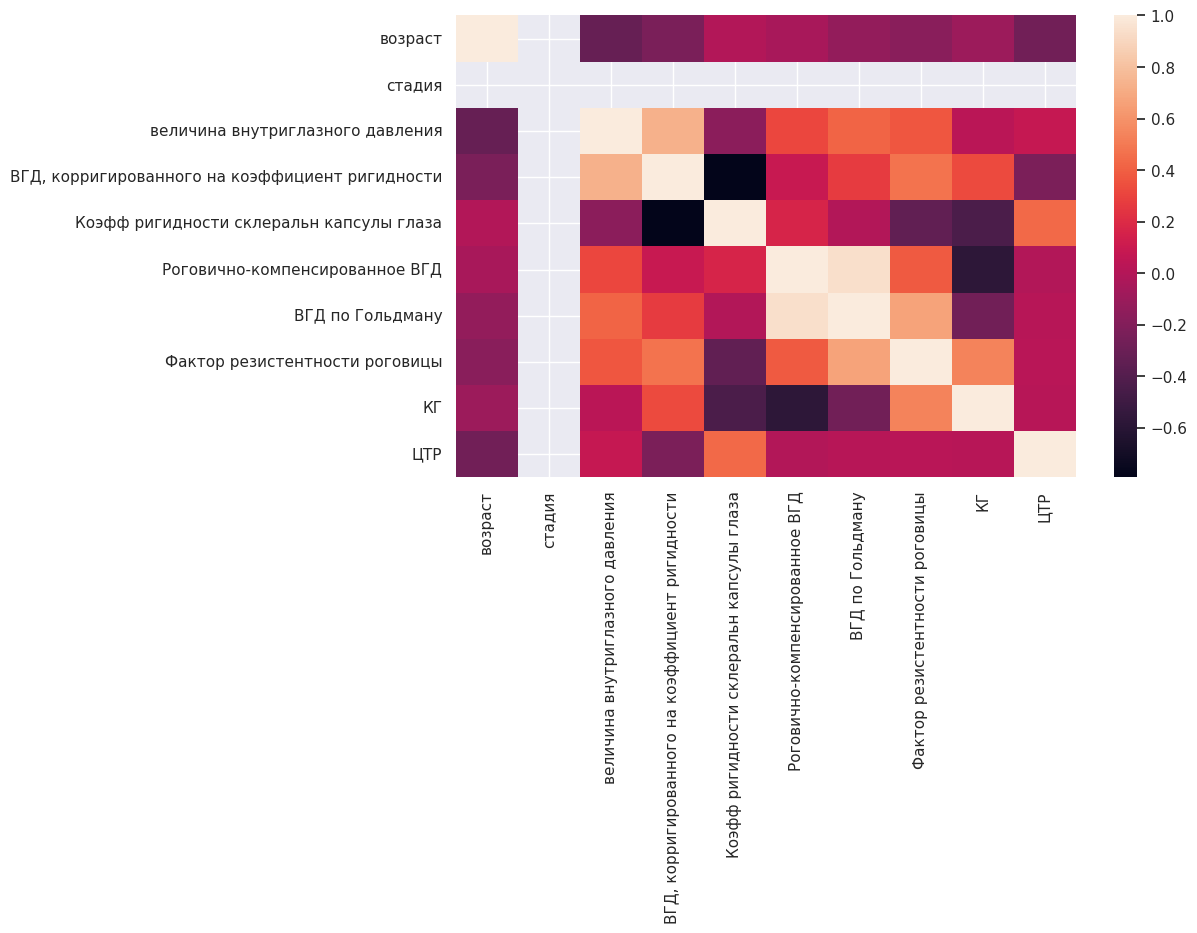

In [ ]:
sns.heatmap(corr_matrix_before)

In [ ]:
corr_matrix_after=median_imputer.iloc [:, 1:11].corr().round(3)

<Axes: >

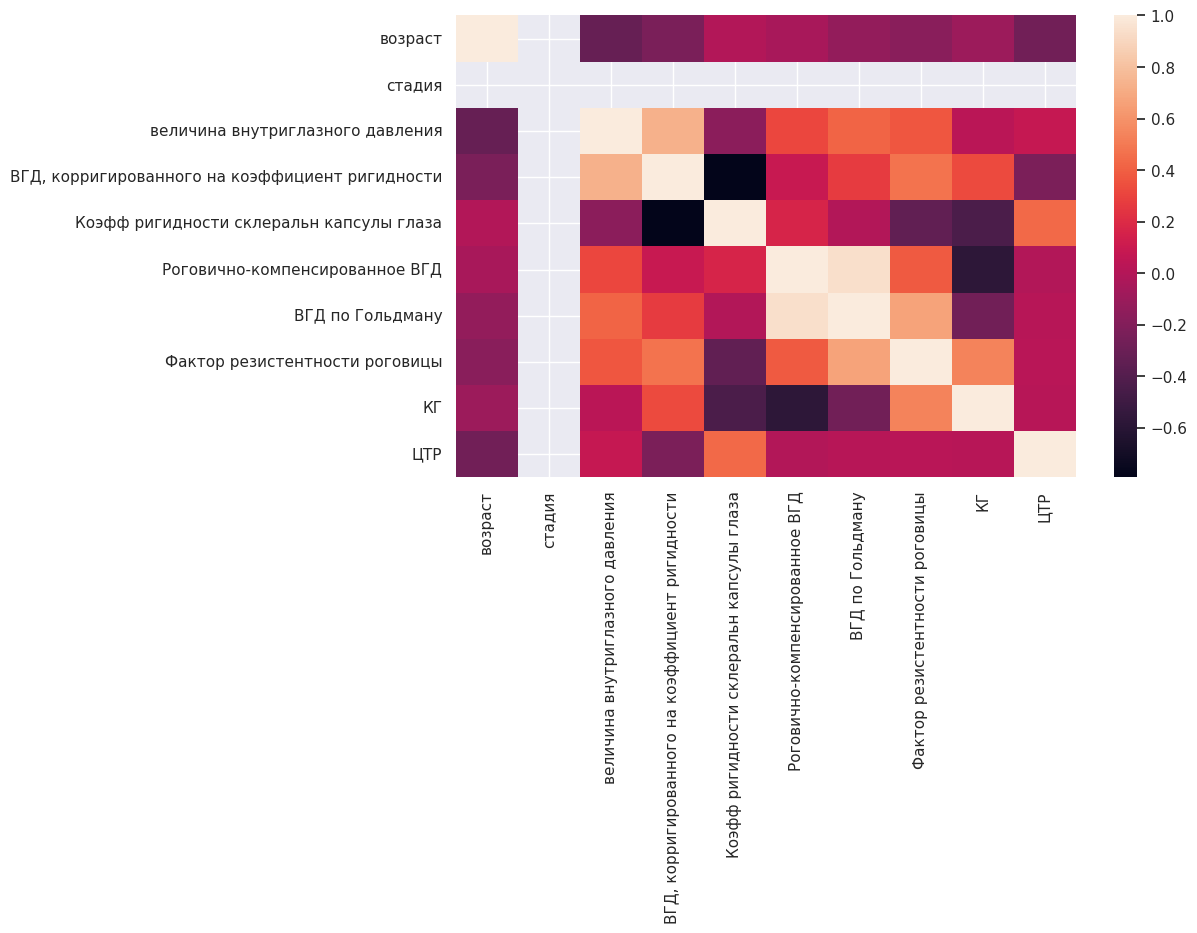

In [ ]:
sns.heatmap(corr_matrix_after)

In [ ]:
changes_in_corr=corr_matrix_before-corr_matrix_after

In [ ]:
changes_in_corr

,возраст,стадия,величина внутриглазного давления,"ВГД, корригированного на коэффициент ригидности",Коэфф ригидности склеральн капсулы глаза,Роговично-компенсированное ВГД,ВГД по Гольдману,Фактор резистентности роговицы,КГ,ЦТР
возраст,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
стадия,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
величина внутриглазного давления,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"ВГД, корригированного на коэффициент ригидности",0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Коэфф ригидности склеральн капсулы глаза,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Роговично-компенсированное ВГД,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ВГД по Гольдману,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Фактор резистентности роговицы,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
КГ,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ЦТР,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<Axes: >

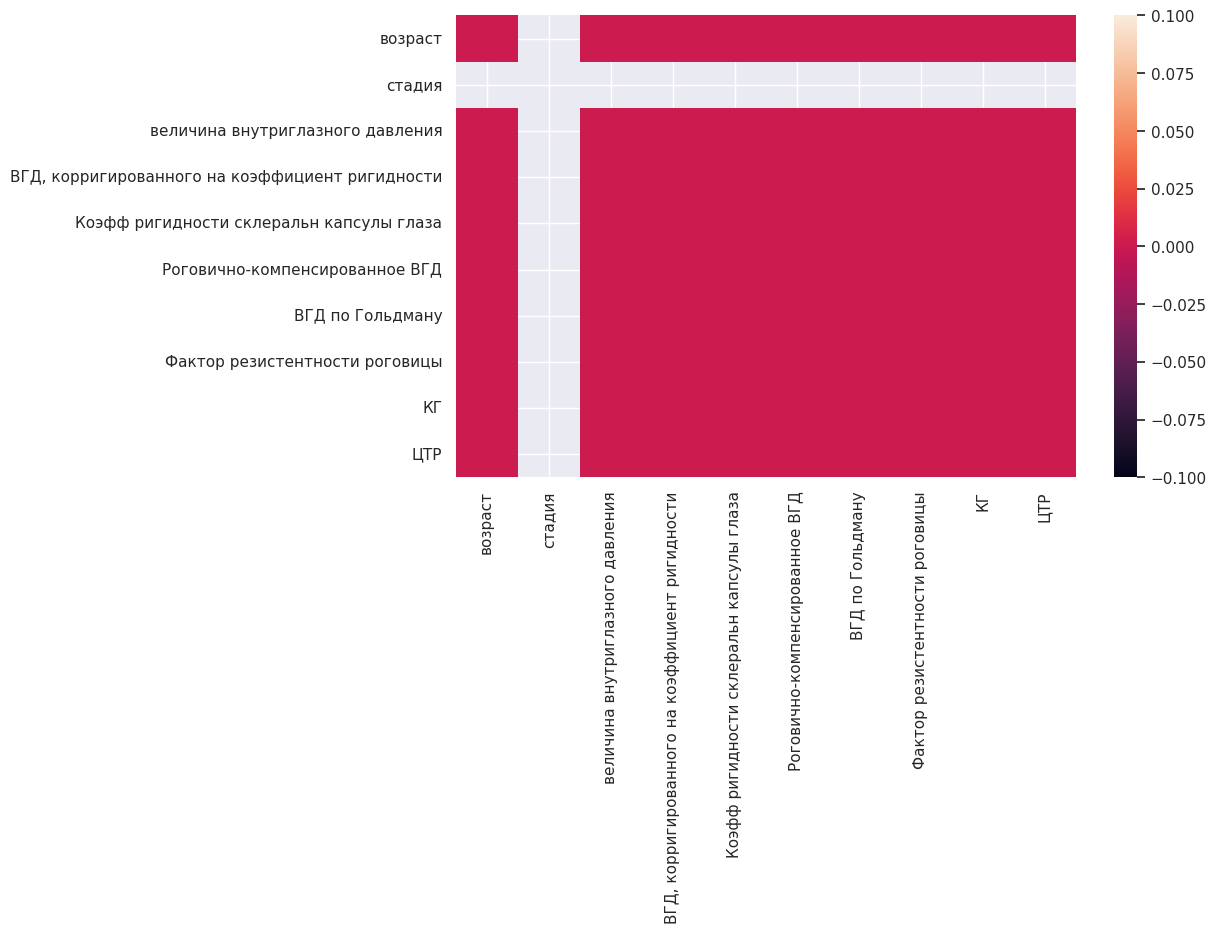

In [ ]:
sns.heatmap(changes_in_corr)

In [ ]:
data_2_stage=median_imputer

In [ ]:
data_2_stage

,Фамилия,возраст,стадия,величина внутриглазного давления,"ВГД, корригированного на коэффициент ригидности",Коэфф ригидности склеральн капсулы глаза,Роговично-компенсированное ВГД,ВГД по Гольдману,Фактор резистентности роговицы,КГ,...,gamma Ш,Efrid,SVL,DVL,РИ (рео.индекс) мОм,ПМН (макс.нап),ПМУ (мод.упр.),Z баз.(отн.)),Z баз.(мОм),УОК (уд.объем) мкл
0,горнева,84,2,13,17,0.0132,16.2,14.1,8.8,9.0,...,1.65,0.0132,47.36,36.52,38.285,0.26,0.275,894.0,35.76,1.017857
1,Иванов,64,2,19,24,0.0127,15.7,15.7,10.0,10.0,...,1.65,0.0127,44.11,32.11,38.285,0.26,0.275,894.0,35.76,1.017857
2,близнюк,70,2,11,11,0.0214,19.8,18.0,9.9,8.9,...,2.40,0.0343,51.47,47.28,43.370,0.11,0.260,960.0,38.40,1.031167
3,Иванов,68,2,11,12,0.0190,17.1,14.0,8.1,8.2,...,0.70,0.0190,50.96,41.77,33.200,0.71,0.750,925.0,37.00,0.819232
4,митина,80,2,17,21,0.0146,23.5,21.0,9.9,7.9,...,1.75,0.0146,44.14,29.78,27.390,0.16,0.190,1080.0,43.20,0.578867
5,якубова,71,2,15,20,0.0133,26.5,25.7,12.1,8.8,...,1.70,0.0133,47.36,36.07,38.285,0.26,0.275,894.0,35.76,1.017857
6,емельянова,77,2,16,17,0.0199,20.2,18.0,9.6,8.6,...,2.00,0.0199,47.36,36.52,29.340,0.26,0.280,911.0,36.44,0.735110
7,Мациева,68,2,17,12,0.0325,22.6,19.4,9.0,7.4,...,2.30,0.0325,47.36,36.52,44.280,0.08,0.090,878.0,35.12,1.151129
8,Попова,80,2,14,14,0.0204,24.3,19.9,8.1,6.1,...,1.70,0.0204,49.31,36.52,11.360,0.12,0.270,766.0,30.64,0.338501
9,Иванов,72,2,18,25,0.0092,20.7,19.6,10.7,9.3,...,1.45,0.0092,47.36,36.52,58.260,0.18,0.230,947.0,37.88,1.404207


## Работа с пропущенными значениями в таблице с пациентами **3 стадии заболевания**

In [ ]:
data_3_stage

,Фамилия,возраст,стадия,величина внутриглазного давления,"ВГД, корригированного на коэффициент ригидности",Коэфф ригидности склеральн капсулы глаза,Роговично-компенсированное ВГД,ВГД по Гольдману,Фактор резистентности роговицы,КГ,...,gamma Ш,Efrid,SVL,DVL,РИ (рео.индекс) мОм,ПМН (макс.нап),ПМУ (мод.упр.),Z баз.(отн.)),Z баз.(мОм),УОК (уд.объем) мкл
0,клычникова,68,3,13,7,0.0365,24.9,19.5,7.3,5.3,...,2.40,0.0365,49.90,43.40,NaN,NaN,NaN,NaN,NaN,NaN
1,кадушкин,68,3,15,11,0.0306,20.7,16.5,8.0,7.1,...,3.55,0.0306,49.31,39.83,15.10,0.04,0.08,917.0,36.68,0.375853
2,якубова,71,3,22,21,0.0227,26.0,23.8,10.6,7.7,...,2.20,0.0227,45.52,43.11,25.43,0.27,0.26,811.0,32.44,0.715709
3,певзнер,74,3,22,23,0.0205,20.9,18.9,9.9,8.6,...,1.95,0.0205,42.12,26.86,15.48,0.11,0.13,822.0,32.88,0.429843
4,Хохлова,64,3,14,14,0.0201,19.3,18.3,10.5,9.6,...,NaN,NaN,NaN,NaN,16.72,0.07,0.09,888.0,35.52,0.429768
5,NaN,64,3,13,10,0.0315,19.6,18.6,10.6,9.5,...,NaN,NaN,NaN,NaN,38.82,0.08,0.09,872.0,34.88,1.016131
6,Соловьева Е.,72,3,16,12,0.0306,20.0,18.0,8.7,7.6,...,NaN,NaN,NaN,NaN,49.61,0.09,0.14,877.0,35.08,1.291161
7,Зайченко,76,3,17,16,0.0246,23.1,17.1,6.5,5.1,...,NaN,NaN,NaN,NaN,57.32,0.75,0.66,410.0,16.40,3.191046
8,Вакалова,80,3,16,11,0.0347,21.0,17.8,8.7,7.6,...,NaN,NaN,28.82,38.87,26.61,0.15,0.16,483.0,19.32,1.257502
9,Колесова,67,3,18,17,0.0227,19.0,20.5,8.5,7.7,...,2.20,0.0227,42.70,40.10,25.43,0.27,0.26,811.0,32.44,0.715709


In [ ]:
#посмотрим сколько пропущенных значений в данных
data_3_stage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 23 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Фамилия                                          9 non-null      object 
 1   возраст                                          10 non-null     int64  
 2   стадия                                           10 non-null     int64  
 3   величина внутриглазного давления                 10 non-null     int64  
 4   ВГД, корригированного на коэффициент ригидности  10 non-null     int64  
 5   Коэфф ригидности склеральн капсулы глаза         10 non-null     float64
 6   Роговично-компенсированное ВГД                   10 non-null     float64
 7   ВГД по Гольдману                                 10 non-null     float64
 8   Фактор резистентности роговицы                   10 non-null     float64
 9   КГ                                 

In [ ]:
data_3_stage.isnull().sum()

,0
Фамилия,1
возраст,0
стадия,0
величина внутриглазного давления,0
"ВГД, корригированного на коэффициент ригидности",0
Коэфф ригидности склеральн капсулы глаза,0
Роговично-компенсированное ВГД,0
ВГД по Гольдману,0
Фактор резистентности роговицы,0
КГ,0


Рассчитаем процент пропусков

In [ ]:
(data_3_stage.isna().sum() / len(data_3_stage)).round(4) * 100

,0
Фамилия,10.0
возраст,0.0
стадия,0.0
величина внутриглазного давления,0.0
"ВГД, корригированного на коэффициент ригидности",0.0
Коэфф ригидности склеральн капсулы глаза,0.0
Роговично-компенсированное ВГД,0.0
ВГД по Гольдману,0.0
Фактор резистентности роговицы,0.0
КГ,0.0


Вывод: пропуски есть по 14 признакам из 23, процент пропущенных данных в основном от 10% до 50%. На основе этого становится понятно, что удалять данные с пропущенными значениями - неподходящий способ в данной ситуации.

<Axes: >

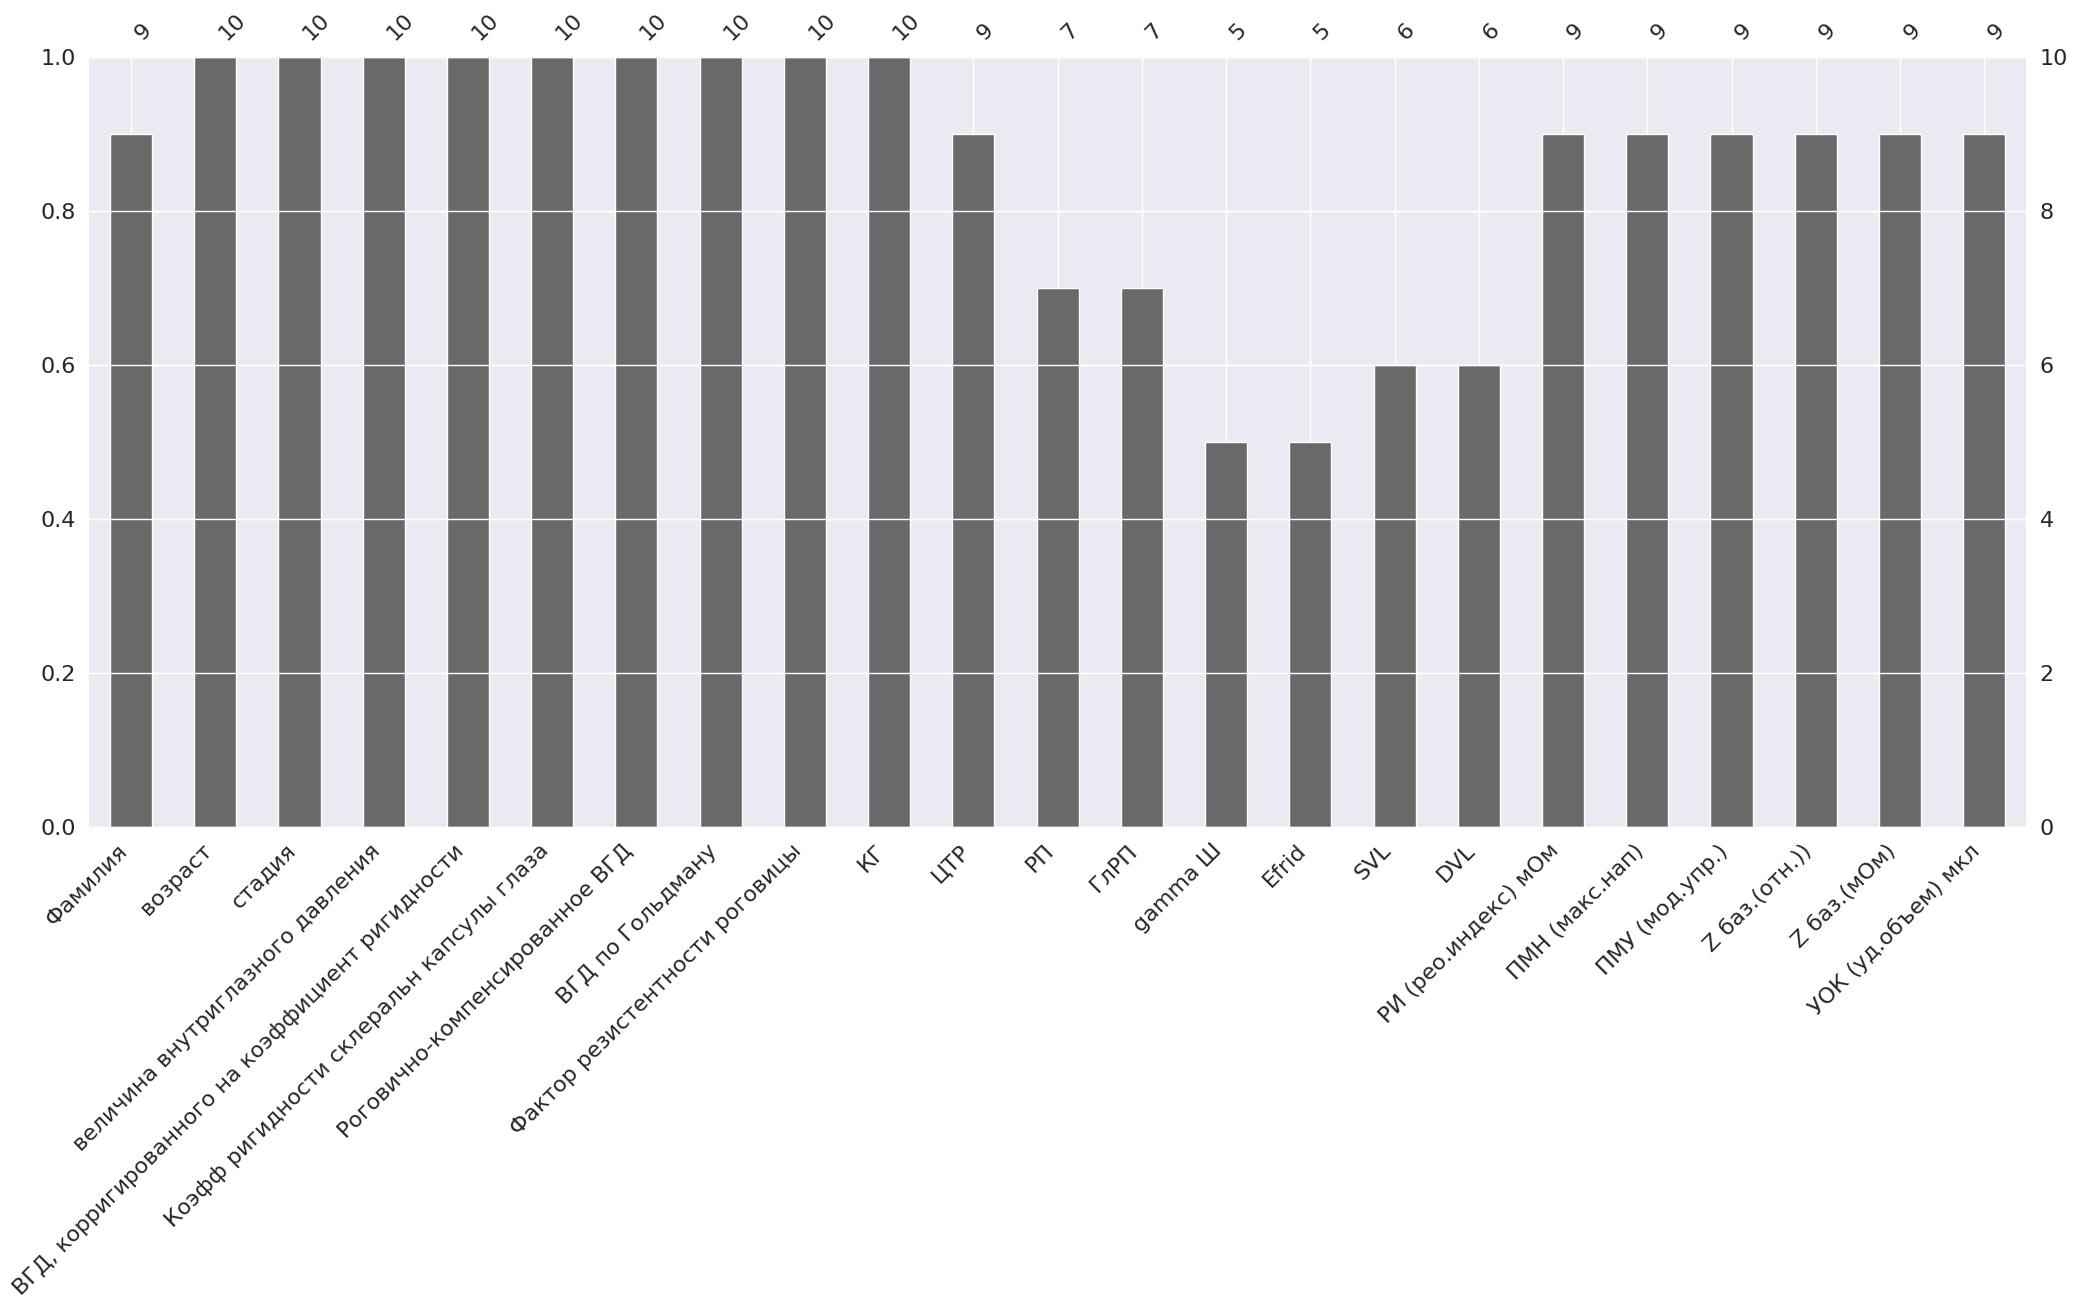

In [ ]:
msno.bar(data_3_stage)

<Axes: >

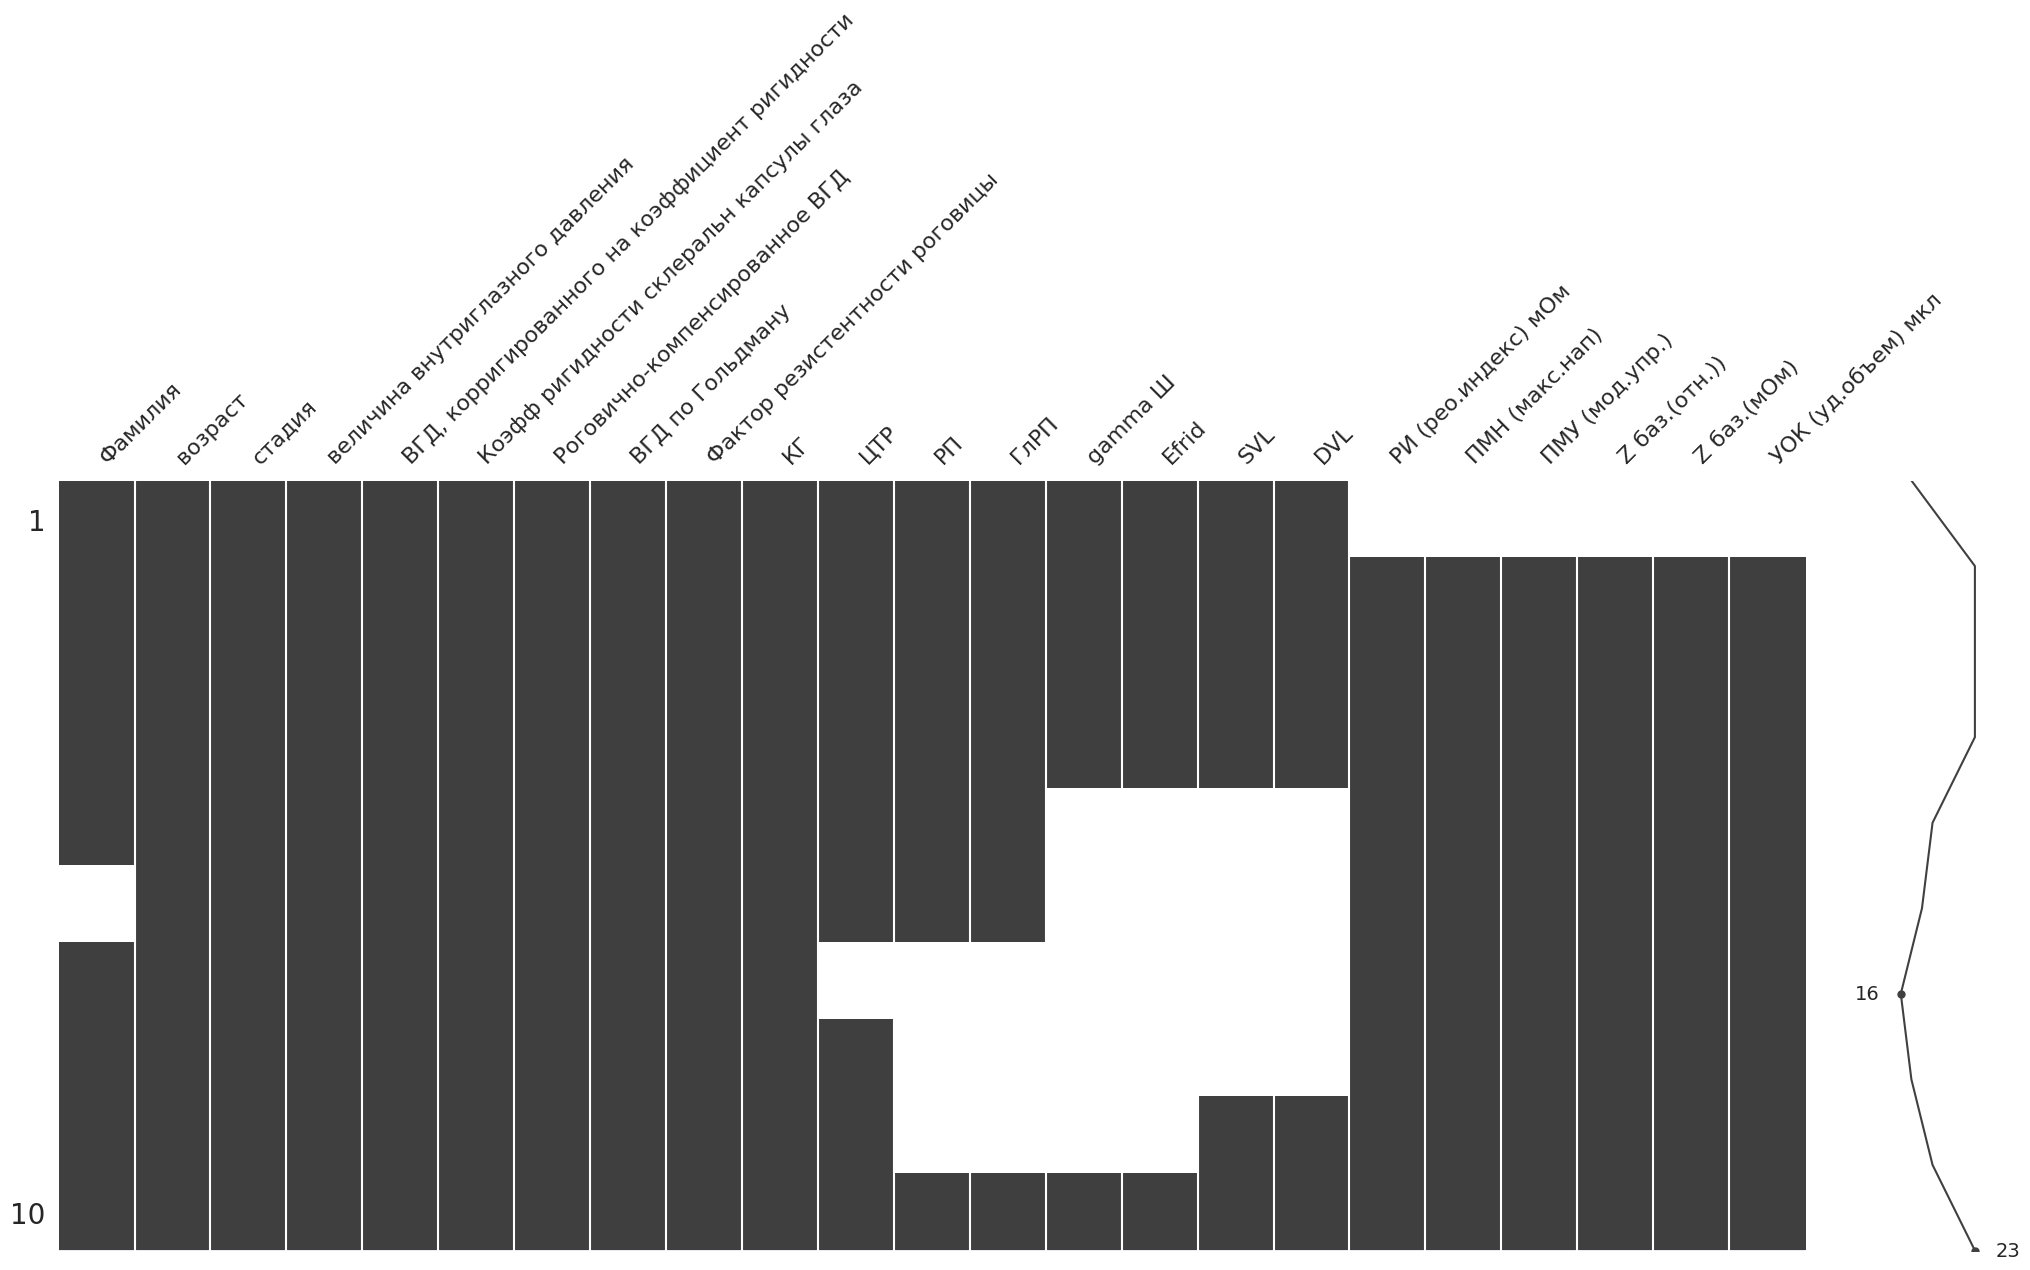

In [ ]:
#матрица пропущенных значений
msno.matrix(data_3_stage)

Выяснили, что пропуски носят случайный характер. Приступаем к их заполнению.

Построим **матрицу корреляции пропущенных значений** (nullity correlation matrix).

In [ ]:
tmp_df = data_3_stage.iloc[:, [i for i, n in enumerate(np.var(data_3_stage.isnull(), axis = 'rows')) if n > 0]]
tmp_df.isnull().corr()

,Фамилия,ЦТР,РП,ГлРП,gamma Ш,Efrid,SVL,DVL,РИ (рео.индекс) мОм,ПМН (макс.нап),ПМУ (мод.упр.),Z баз.(отн.)),Z баз.(мОм),УОК (уд.объем) мкл
Фамилия,1.000000,-0.111111,-0.218218,-0.218218,0.333333,0.333333,0.408248,0.408248,-0.111111,-0.111111,-0.111111,-0.111111,-0.111111,-0.111111
ЦТР,-0.111111,1.000000,0.509175,0.509175,0.333333,0.333333,0.408248,0.408248,-0.111111,-0.111111,-0.111111,-0.111111,-0.111111,-0.111111
РП,-0.218218,0.509175,1.000000,1.000000,0.654654,0.654654,0.356348,0.356348,-0.218218,-0.218218,-0.218218,-0.218218,-0.218218,-0.218218
ГлРП,-0.218218,0.509175,1.000000,1.000000,0.654654,0.654654,0.356348,0.356348,-0.218218,-0.218218,-0.218218,-0.218218,-0.218218,-0.218218
gamma Ш,0.333333,0.333333,0.654654,0.654654,1.000000,1.000000,0.816497,0.816497,-0.333333,-0.333333,-0.333333,-0.333333,-0.333333,-0.333333
Efrid,0.333333,0.333333,0.654654,0.654654,1.000000,1.000000,0.816497,0.816497,-0.333333,-0.333333,-0.333333,-0.333333,-0.333333,-0.333333
SVL,0.408248,0.408248,0.356348,0.356348,0.816497,0.816497,1.000000,1.000000,-0.272166,-0.272166,-0.272166,-0.272166,-0.272166,-0.272166
DVL,0.408248,0.408248,0.356348,0.356348,0.816497,0.816497,1.000000,1.000000,-0.272166,-0.272166,-0.272166,-0.272166,-0.272166,-0.272166
РИ (рео.индекс) мОм,-0.111111,-0.111111,-0.218218,-0.218218,-0.333333,-0.333333,-0.272166,-0.272166,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
ПМН (макс.нап),-0.111111,-0.111111,-0.218218,-0.218218,-0.333333,-0.333333,-0.272166,-0.272166,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


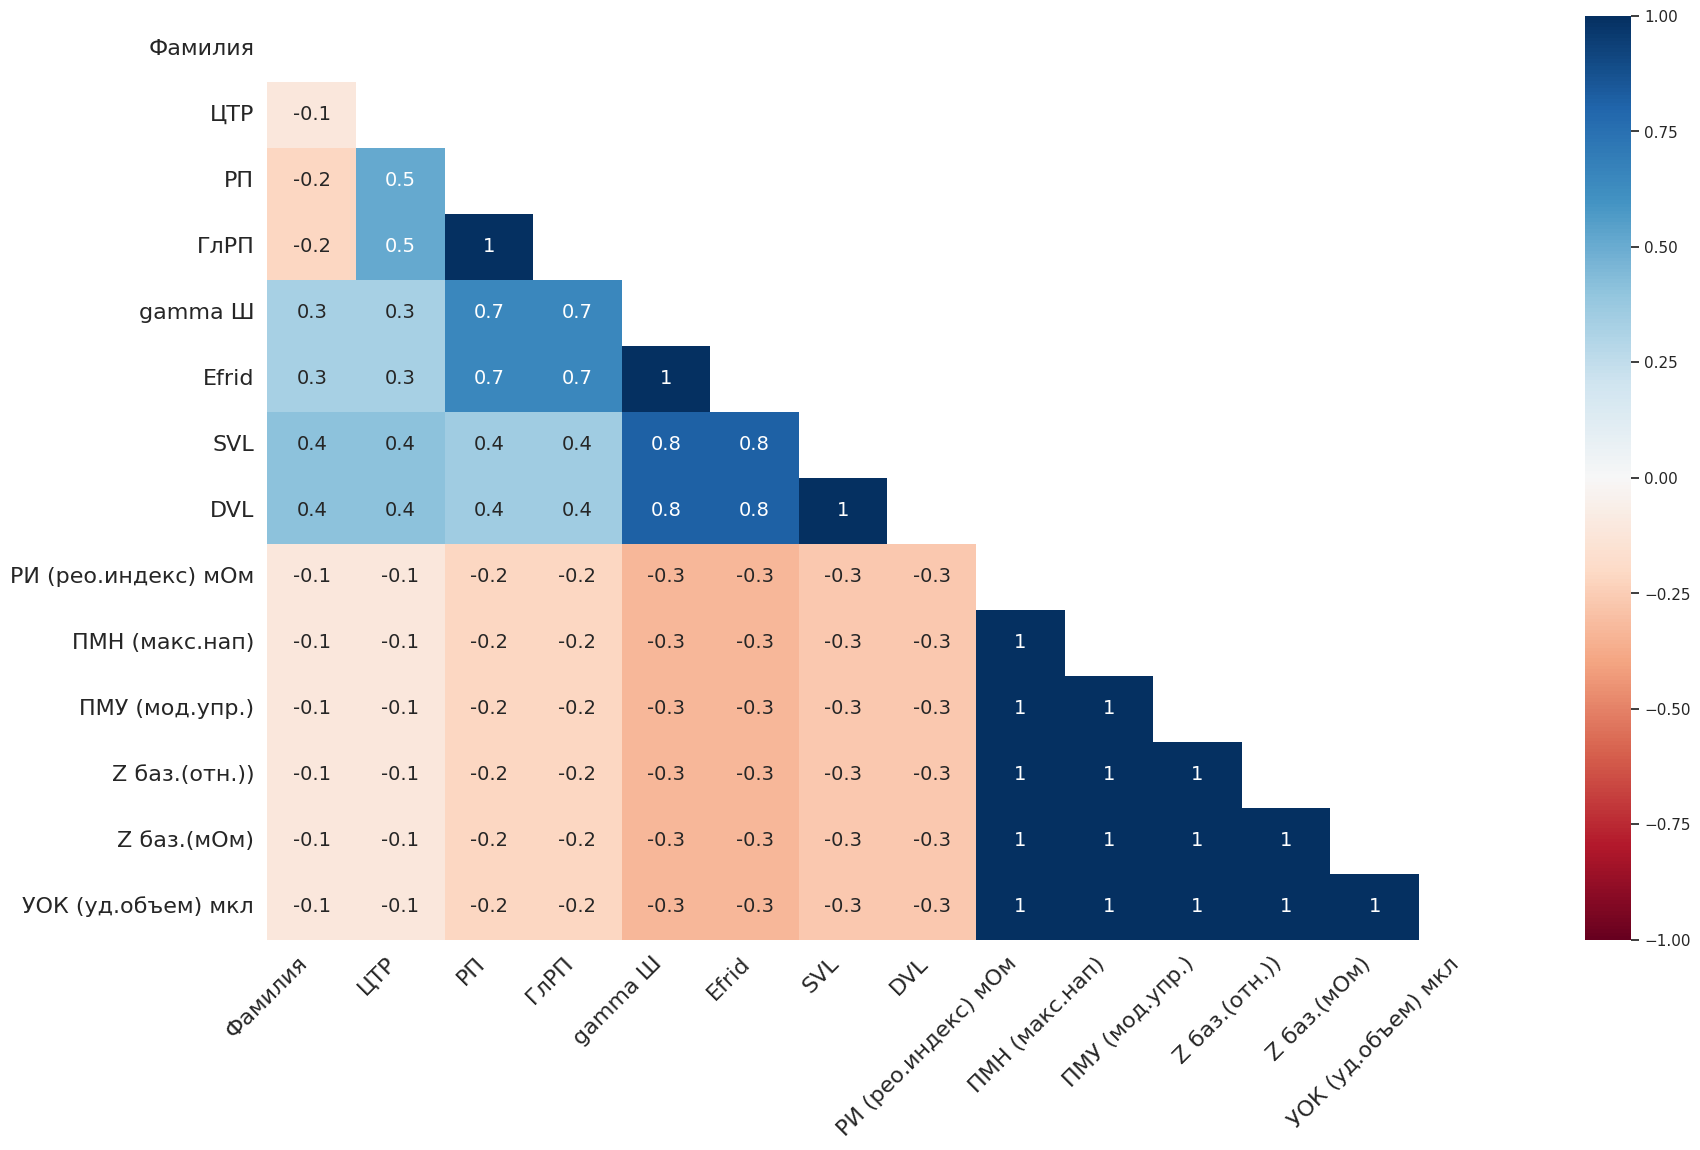

In [ ]:
msno.heatmap(data_3_stage);

### Заполняем пропуски в категориальных признаках



---


Фамилия - категориальный признак. Заполним значением по умолчанию, например, "Иванов"

In [ ]:
data_3_stage['Фамилия']=data_3_stage['Фамилия'].fillna('Иванов')
data_3_stage.isnull().sum()

,0
Фамилия,0
возраст,0
стадия,0
величина внутриглазного давления,0
"ВГД, корригированного на коэффициент ригидности",0
Коэфф ригидности склеральн капсулы глаза,0
Роговично-компенсированное ВГД,0
ВГД по Гольдману,0
Фактор резистентности роговицы,0
КГ,0


### Заполняем пропуски в количественных признаках



---

Остальные пропущенные значения принадлежат количественным признакам.

Можно заменить медианой.

In [ ]:
# скопируем датафрейм
median_imputer = data_3_stage.copy()

In [ ]:
#Посмотрим на среднее арифметическое и медиану.
print('ЦТР - ', median_imputer['ЦТР'].mean().round(1), '  ', median_imputer['ЦТР'].median())
print('РП - ', median_imputer['РП'].mean().round(1), '  ', median_imputer['РП'].median())
print('ГлРП - ', median_imputer['ГлРП'].mean().round(1), '  ', median_imputer['ГлРП'].median())
print('gamma Ш - ', median_imputer['gamma Ш'].mean().round(1), '  ', median_imputer['gamma Ш'].median())
print('Efrid - ', median_imputer['Efrid'].mean().round(1), '  ', median_imputer['Efrid'].median())
print('SVL - ', median_imputer['SVL'].mean().round(1), '  ', median_imputer['SVL'].median())
print('DVL - ', median_imputer['DVL'].mean().round(1), '  ', median_imputer['DVL'].median())
print('РИ (рео.индекс) мОм - ', median_imputer['РИ (рео.индекс) мОм'].mean().round(1), '  ', median_imputer['РИ (рео.индекс) мОм'].median())
print('ПМН (макс.нап) - ', median_imputer['ПМН (макс.нап)'].mean().round(1), '  ', median_imputer['ПМН (макс.нап)'].median())
print('ПМУ (мод.упр.) - ', median_imputer['ПМУ (мод.упр.)'].mean().round(1), '  ', median_imputer['ПМУ (мод.упр.)'].median())
print('Z баз.(отн.)) - ', median_imputer['Z баз.(отн.))'].mean().round(1), '  ', median_imputer['Z баз.(отн.))'].median())
print('Z баз.(мОм) - ', median_imputer['Z баз.(мОм)'].mean().round(1), '  ', median_imputer['Z баз.(мОм)'].median())
print('УОК (уд.объем) мкл - ', median_imputer['УОК (уд.объем) мкл'].mean().round(1), '  ', median_imputer['УОК (уд.объем) мкл'].median())



ЦТР -  532.4    527.0
РП -  176.7    180.0
ГлРП -  534.0    520.0
gamma Ш -  2.5    2.2
Efrid -  0.0    0.0227
SVL -  43.1    44.11
DVL -  38.7    39.965
РИ (рео.индекс) мОм -  30.1    25.43
ПМН (макс.нап) -  0.2    0.11
ПМУ (мод.упр.) -  0.2    0.14
Z баз.(отн.)) -  765.7    822.0
Z баз.(мОм) -  30.6    32.88
УОК (уд.объем) мкл -  1.0    0.7157086929716401


In [ ]:
# создадим объект класса SimpleImputer с параметром strategy = 'median'
imp_median = SimpleImputer(strategy = 'median')

# применим метод .fit_transform() для одновременного обучения модели и заполнения пропусков
median_imputer['ЦТР'] = imp_median.fit_transform(median_imputer[['ЦТР']])
median_imputer['РП'] = imp_median.fit_transform(median_imputer[['РП']])
median_imputer['ГлРП'] = imp_median.fit_transform(median_imputer[['ГлРП']])
median_imputer['gamma Ш'] = imp_median.fit_transform(median_imputer[['gamma Ш']])
median_imputer['Efrid'] = imp_median.fit_transform(median_imputer[['Efrid']])
median_imputer['SVL'] = imp_median.fit_transform(median_imputer[['SVL']])
median_imputer['DVL'] = imp_median.fit_transform(median_imputer[['DVL']])
median_imputer['РИ (рео.индекс) мОм'] = imp_median.fit_transform(median_imputer[['РИ (рео.индекс) мОм']])
median_imputer['ПМН (макс.нап)'] = imp_median.fit_transform(median_imputer[['ПМН (макс.нап)']])
median_imputer['ПМУ (мод.упр.)'] = imp_median.fit_transform(median_imputer[['ПМУ (мод.упр.)']])
median_imputer['Z баз.(отн.))'] = imp_median.fit_transform(median_imputer[['Z баз.(отн.))']])
median_imputer['Z баз.(мОм)'] = imp_median.fit_transform(median_imputer[['Z баз.(мОм)']])
median_imputer['УОК (уд.объем) мкл'] = imp_median.fit_transform(median_imputer[['УОК (уд.объем) мкл']])

# убедимся, что пропущенных значений не осталось
median_imputer['УОК (уд.объем) мкл'].isna().sum()

np.int64(0)

In [ ]:
# посмотрим на метрики после заполнения медианой
print('ЦТР - ', median_imputer['ЦТР'].mean().round(1), '  ', median_imputer['ЦТР'].median())
print('РП - ', median_imputer['РП'].mean().round(1), '  ', median_imputer['РП'].median())
print('ГлРП - ', median_imputer['ГлРП'].mean().round(1), '  ', median_imputer['ГлРП'].median())
print('gamma Ш - ', median_imputer['gamma Ш'].mean().round(1), '  ', median_imputer['gamma Ш'].median())
print('Efrid - ', median_imputer['Efrid'].mean().round(1), '  ', median_imputer['Efrid'].median())
print('SVL - ', median_imputer['SVL'].mean().round(1), '  ', median_imputer['SVL'].median())
print('DVL - ', median_imputer['DVL'].mean().round(1), '  ', median_imputer['DVL'].median())
print('РИ (рео.индекс) мОм - ', median_imputer['РИ (рео.индекс) мОм'].mean().round(1), '  ', median_imputer['РИ (рео.индекс) мОм'].median())
print('ПМН (макс.нап) - ', median_imputer['ПМН (макс.нап)'].mean().round(1), '  ', median_imputer['ПМН (макс.нап)'].median())
print('ПМУ (мод.упр.) - ', median_imputer['ПМУ (мод.упр.)'].mean().round(1), '  ', median_imputer['ПМУ (мод.упр.)'].median())
print('Z баз.(отн.)) - ', median_imputer['Z баз.(отн.))'].mean().round(1), '  ', median_imputer['Z баз.(отн.))'].median())
print('Z баз.(мОм) - ', median_imputer['Z баз.(мОм)'].mean().round(1), '  ', median_imputer['Z баз.(мОм)'].median())
print('УОК (уд.объем) мкл - ', median_imputer['УОК (уд.объем) мкл'].mean().round(1), '  ', median_imputer['УОК (уд.объем) мкл'].median())



ЦТР -  531.9    527.0
РП -  177.7    180.0
ГлРП -  529.8    520.0
gamma Ш -  2.3    2.2
Efrid -  0.0    0.0227
SVL -  43.5    44.11
DVL -  39.2    39.965
РИ (рео.индекс) мОм -  29.6    25.43
ПМН (макс.нап) -  0.2    0.11
ПМУ (мод.упр.) -  0.2    0.14
Z баз.(отн.)) -  771.3    822.0
Z баз.(мОм) -  30.9    32.88
УОК (уд.объем) мкл -  1.0    0.7157086929716401


Проверяем, что заполнили все пропуски.

In [ ]:
median_imputer.isnull().sum()

,0
Фамилия,0
возраст,0
стадия,0
величина внутриглазного давления,0
"ВГД, корригированного на коэффициент ригидности",0
Коэфф ригидности склеральн капсулы глаза,0
Роговично-компенсированное ВГД,0
ВГД по Гольдману,0
Фактор резистентности роговицы,0
КГ,0


### Сравниваем взаимосвязь признаков до и после заполнения пропусков

In [ ]:
corr_matrix_before=data_3_stage.iloc [:, 1:11].corr().round(3)

<Axes: >

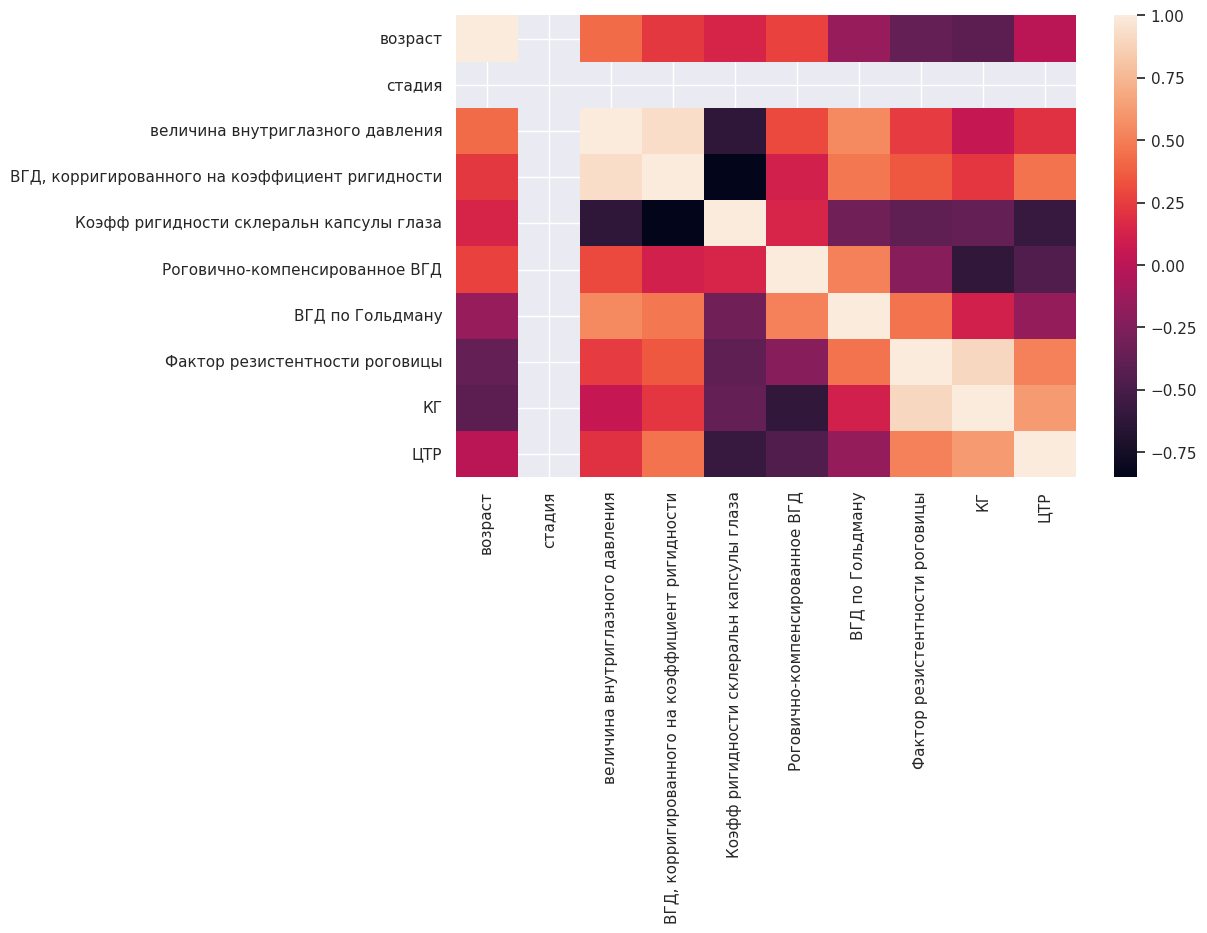

In [ ]:
sns.heatmap(corr_matrix_before)

In [ ]:
corr_matrix_after=median_imputer.iloc [:, 1:11].corr().round(3)

<Axes: >

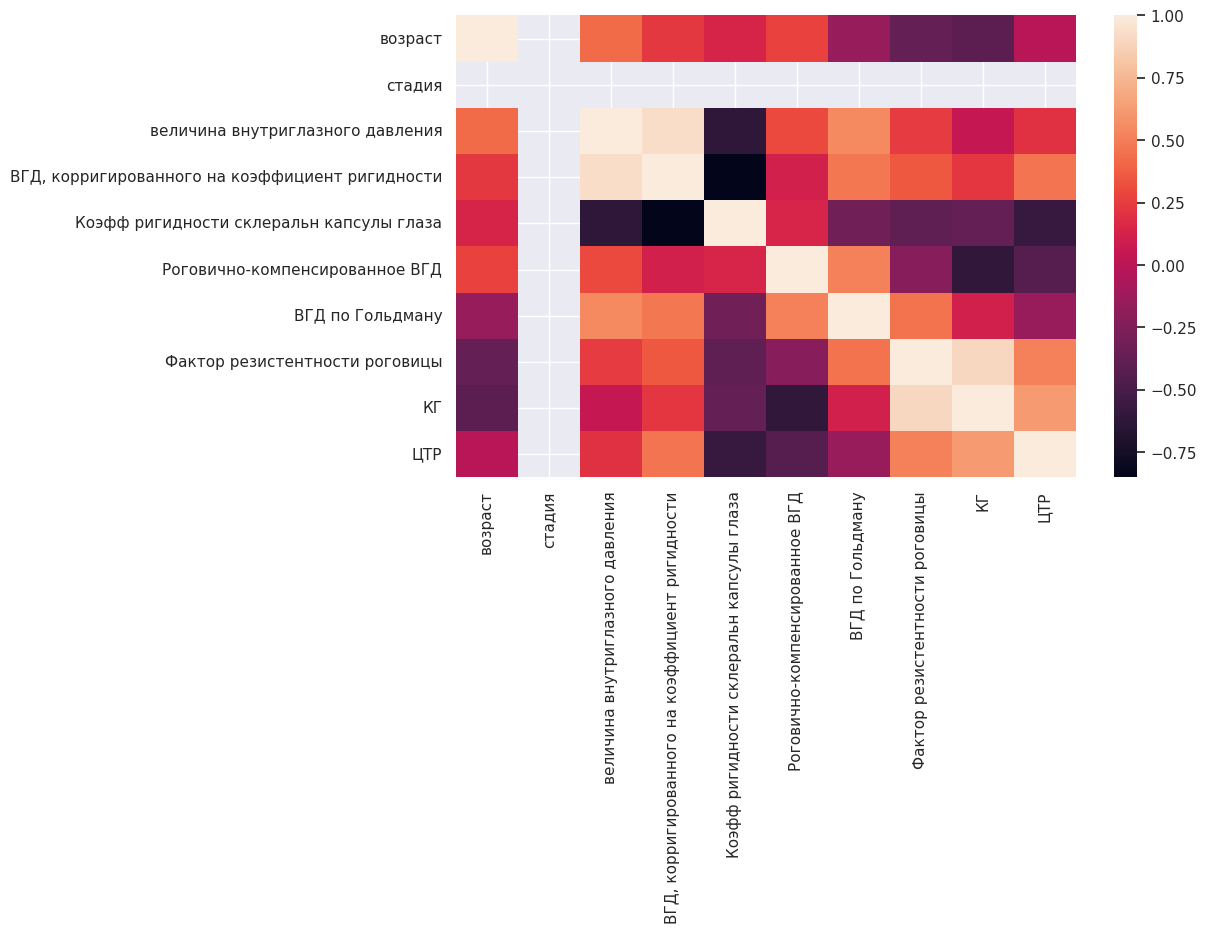

In [ ]:
sns.heatmap(corr_matrix_after)

In [ ]:
changes_in_corr=corr_matrix_before-corr_matrix_after

In [ ]:
changes_in_corr

,возраст,стадия,величина внутриглазного давления,"ВГД, корригированного на коэффициент ригидности",Коэфф ригидности склеральн капсулы глаза,Роговично-компенсированное ВГД,ВГД по Гольдману,Фактор резистентности роговицы,КГ,ЦТР
возраст,0.000,NaN,0.000,0.000,0.000,0.00,0.000,0.000,0.000,0.009
стадия,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
величина внутриглазного давления,0.000,NaN,0.000,0.000,0.000,0.00,0.000,0.000,0.000,-0.004
"ВГД, корригированного на коэффициент ригидности",0.000,NaN,0.000,0.000,0.000,0.00,0.000,0.000,0.000,-0.006
Коэфф ригидности склеральн капсулы глаза,0.000,NaN,0.000,0.000,0.000,0.00,0.000,0.000,0.000,0.004
Роговично-компенсированное ВГД,0.000,NaN,0.000,0.000,0.000,0.00,0.000,0.000,0.000,-0.030
ВГД по Гольдману,0.000,NaN,0.000,0.000,0.000,0.00,0.000,0.000,0.000,-0.016
Фактор резистентности роговицы,0.000,NaN,0.000,0.000,0.000,0.00,0.000,0.000,0.000,-0.002
КГ,0.000,NaN,0.000,0.000,0.000,0.00,0.000,0.000,0.000,0.003
ЦТР,0.009,NaN,-0.004,-0.006,0.004,-0.03,-0.016,-0.002,0.003,0.000


<Axes: >

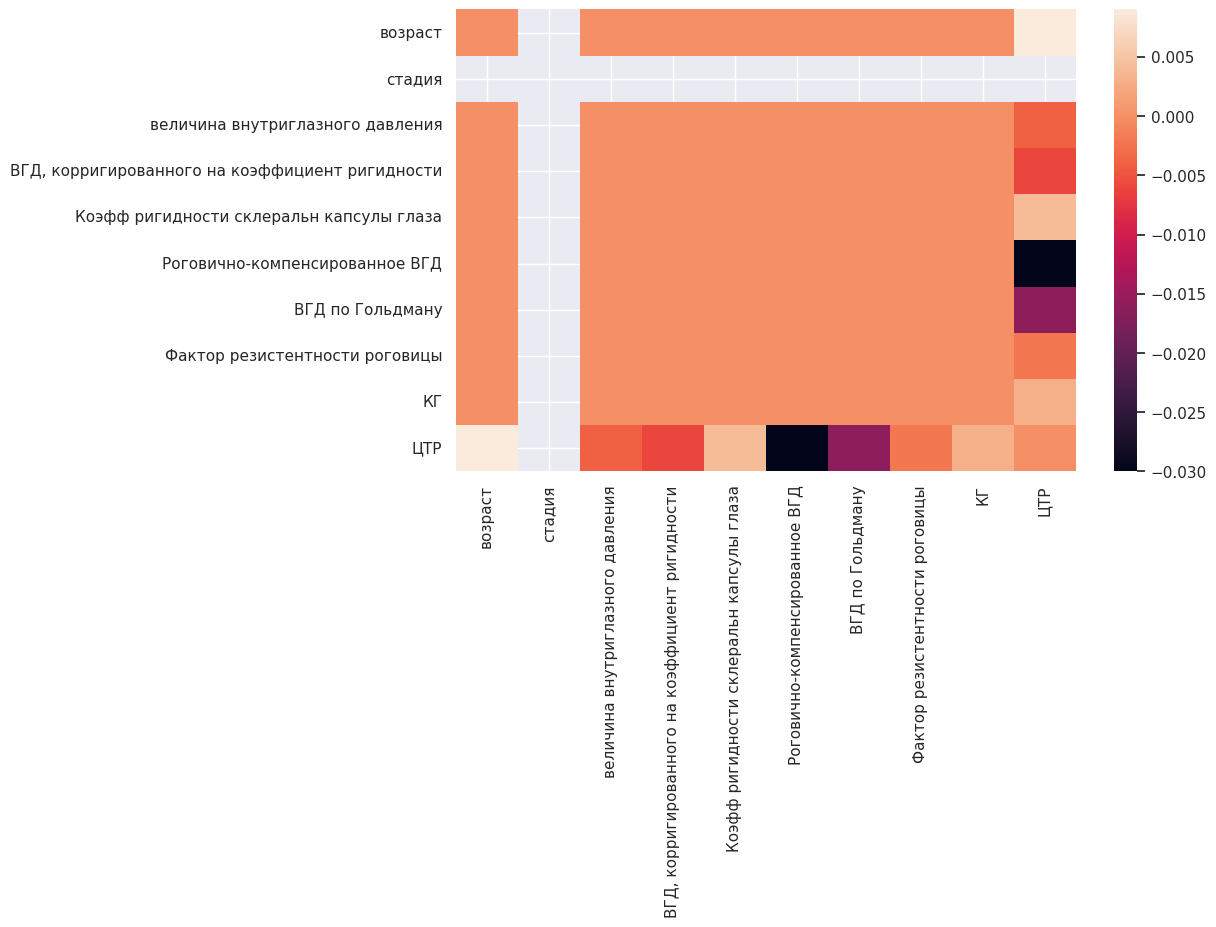

In [ ]:
sns.heatmap(changes_in_corr)

In [ ]:
data_3_stage=median_imputer

In [ ]:
#объединим все таблицы
data_glaucoma_after_input=pd.concat([data_healthy, data_1_stage, data_2_stage, data_3_stage], axis=0)


In [ ]:
table_agg_after_input=data_glaucoma_after_input.drop(['Фамилия'], axis=1).groupby(['стадия']).agg('mean')

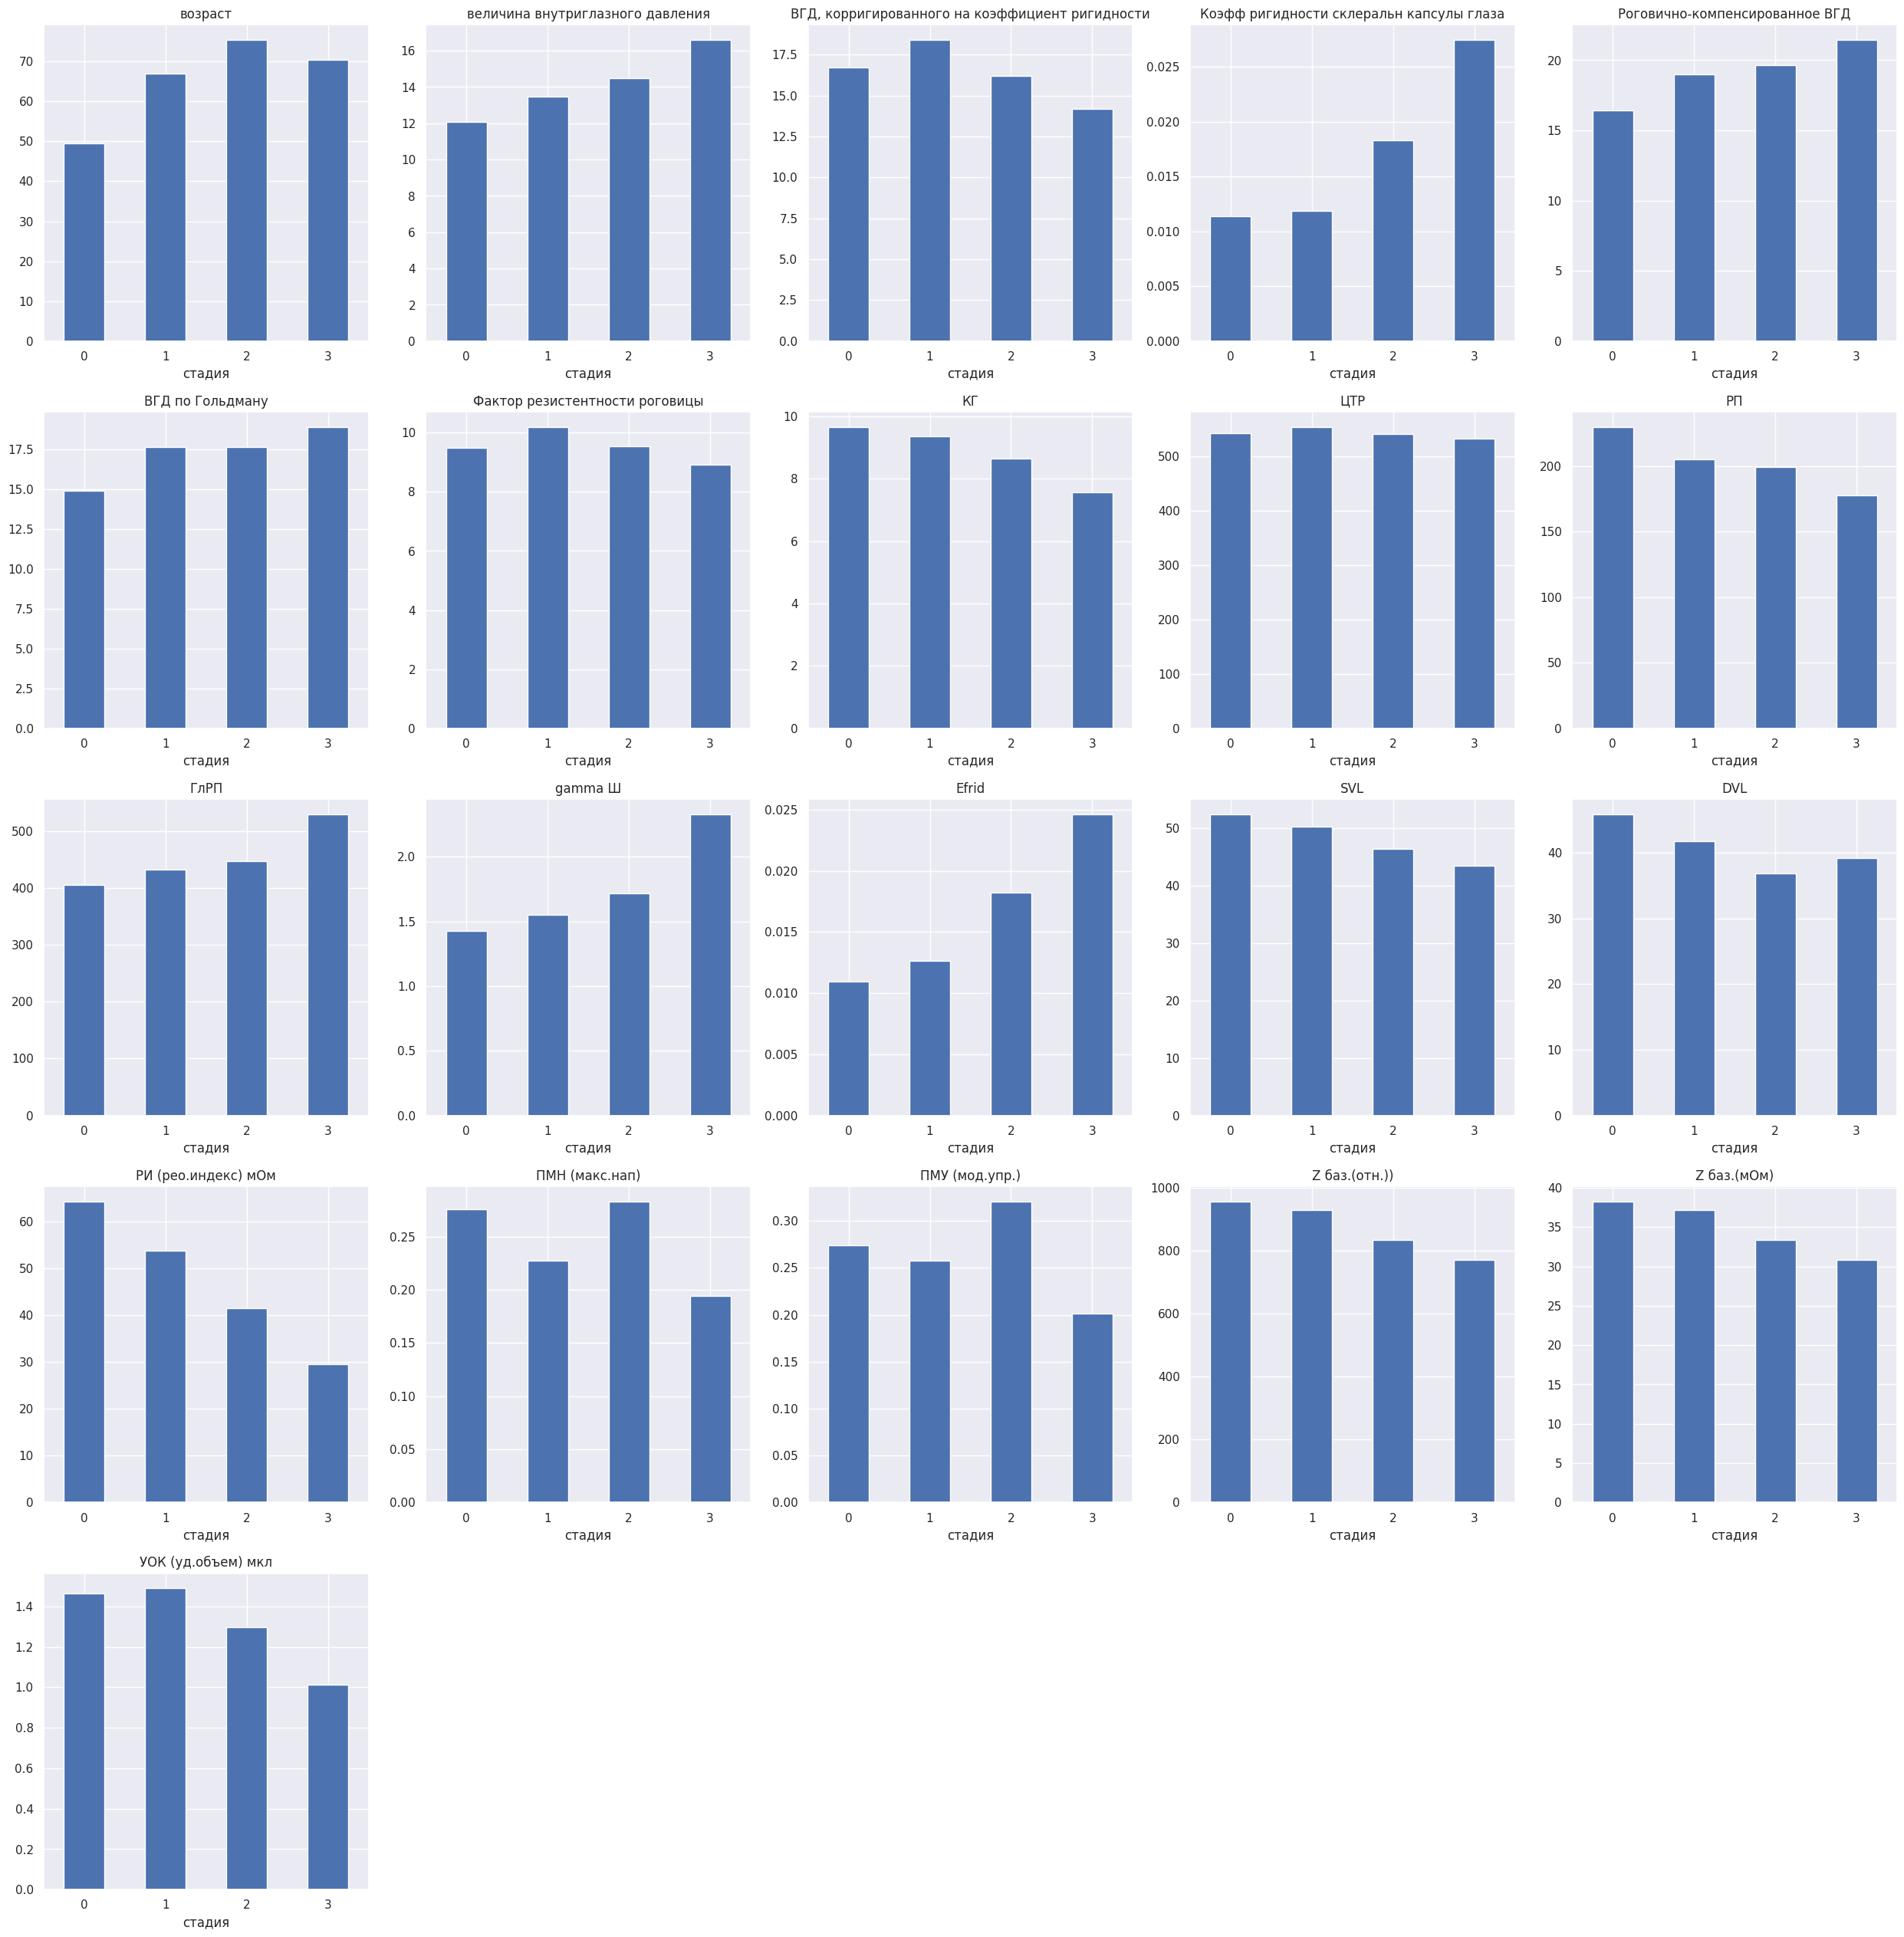

In [ ]:
columns = table_agg.columns.tolist()

n=len(columns)
rows=(n//3)+int(n%3!=0)
# Настроим сетку графиков, например 7 строк и 3 столбца
fig, axes = plt.subplots(nrows=rows, ncols=5, figsize=(25, 5*rows))  # размер можно настроить под себя
axes = axes.flatten()  # Преобразуем в 1D для удобства обращения

for i, col in enumerate(columns):
    table_agg_after_input[col].plot.bar(ax=axes[i], title=col)
    axes[i].tick_params(axis='x', rotation=0)  # при необходимости повернуть подписи по оси X

# Удалим лишние оси, если графиков меньше, чем ячеек
for j in range(len(columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



-------



# Выгрузка подготовленной таблицы

In [ ]:
pip install XlsxWriter

In [ ]:
file_name = 'prepare_data.xlsx'

with pd.ExcelWriter(file_name, engine='xlsxwriter') as writer:
    data_healthy.to_excel(writer, sheet_name='healthy', index=False)
    data_1_stage.to_excel(writer, sheet_name='1_stage', index=False)
    data_2_stage.to_excel(writer, sheet_name='2_stage', index=False)
    data_3_stage.to_excel(writer, sheet_name='3_stage', index=False)

print(f"Файл '{file_name}' успешно сохранен.")

Файл 'prepare_data.xlsx' успешно сохранен.
